# All-Chile Glacier Runoff Contribution to Streamflow

## Overview
This notebook quantifies glacier melt contributions to streamflow across all of Chile,
comparing results across three OGGM climate forcing datasets.

## Methods summary

### Glacier-to-basin assignment
RGI glacier centroids are spatially joined to all 516 CAMELS-CL gauge catchment polygons
(`camels_cl_boundaries.shp`). Because CAMELS-CL uses a nested catchment hierarchy,
a single glacier may fall within multiple overlapping polygons (e.g. Allipen sub-basin
AND the larger Tolten catchment). This is **intentional**: glacier melt physically
passes through all downstream gauges, so the same glacier contributes to the streamflow
fraction at every gauge in its drainage network.

### Total Chile melt (de-duplicated)
For national-scale totals, each glacier is assigned to its **smallest containing
catchment only** (minimum `area_km2` among all matched polygons). This prevents
double-counting when summing melt across the country.

### Q completeness filter
Only gauges with >= `MIN_COMPLETE_YEARS` complete years (all 12 months non-NaN, Q > 0)
within 2000-2019 are included in the streamflow fraction analysis. Gauges below this
threshold are retained for national melt totals only. Fractions are computed only
for months where Q is non-NaN and > 0 — missing Q months are excluded from all averages.

### Climate forcings
- **CR2MET** (~5 km): `run_output_2000_2019_hydro_TC_{cluster}.nc`
- **ERA5** (~30 km): `run_output_2000_2019_hydro_ERA5_{cluster}.nc`
- **CRU** (~55 km): `run_output_2000_2019_hydro_CRU_{cluster}.nc`

All three are calibrated against Hugonnet et al. (2021) geodetic mass balance.
Melt volumes diverge despite identical 20-year mean SMB (accumulation-melt compensation).

### Glacier runoff definition
Glacier runoff = melt on glacier + liquid precipitation on glacier.
NetCDF values are in **kg** — divide by `WATER_DENSITY` (1000 kg/m3) to get m3.

### Analysis period
2000-2019. NetCDF time axis starts at 1999 (spinup, `YEAR_OFFSET=1`).

In [ ]:
# ── Cell 1: Imports & constants ───────────────────────────────────────────
import os
import json
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import calendar
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Wedge
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, to_hex
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Physical constants
ICE_DENSITY   = 900
WATER_DENSITY = 1000

# Analysis window
YEARS       = list(range(2000, 2020))
MONTHS      = list(range(1, 13))
YEAR_OFFSET = 1   # NetCDF index 0 = 1999 spinup; index 1 = 2000

# OGGM clusters (north to south)
CLUSTERS = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']

# Climate datasets: name -> filename tag
DATASETS = {
    'CR2MET': 'TC',
    'ERA5':   'ERA5',
    'CRU':    'CRU',
}

REGION_LABELS = {
    'OT3': 'Altiplano (OT3)',
    'DA1': 'Dry Andes N (DA1)',
    'DA2': 'Dry Andes C (DA2)',
    'DA3': 'Dry Andes S (DA3)',
    'WA1': 'Wet Andes N (WA1)',
    'WA2': 'Wet Andes C (WA2)',
    'WA3': 'N Patagonia (WA3)',
    'WA4': 'S Patagonia (WA4)',
    'WA5': 'Patagonia (WA5)',
    'WA6': 'Tierra del Fuego (WA6)',
}

DS_COLORS    = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
MEGADROUGHT_YEARS = list(range(2010, 2020))

# lista_temp/prec.csv start year (62 years × 12 = 744 rows, 1960-2021)
LISTA_START_YEAR       = 1960
LISTA_ROW_START        = (2000 - LISTA_START_YEAR) * 12   # 480
LISTA_ROW_END          = (2020 - LISTA_START_YEAR) * 12   # 720

print('Cell 1 complete')

Cell 1 complete


In [9]:
# ── Cell 2: Paths & nc_path helper ────────────────────────────────────────
OUTPUT_ROOT = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output'
CAMELS_FULL = ('/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
               'Full_CAMELS_all_basins/CAMELS_CL_v202201')
RGI_PATH    = ('/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
               'files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv')
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
OUT_DIR     = f'{OUTPUT_ROOT}/all_chile_results_v2'
BASE_PATH   = OUTPUT_ROOT
os.makedirs(OUT_DIR, exist_ok=True)

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

print('NetCDF availability:')
all_ok = True
for ds_name in DATASETS:
    missing = [cl for cl in CLUSTERS
               if not os.path.exists(nc_path(ds_name, cl))]
    status  = 'all present' if not missing else f'MISSING: {missing}'
    print(f'  {ds_name:8s}: {status}')
    if missing: all_ok = False
print('All 30 NetCDFs found' if all_ok else 'WARNING: some files missing')

NetCDF availability:
  CR2MET  : all present
  ERA5    : all present
  CRU     : all present
All 30 NetCDFs found


CR2MET: melt=74.1  snowfall=50.3  liq_prcp=50.9 km³/yr
ERA5: melt=102.8  snowfall=82.4  liq_prcp=40.1 km³/yr
CRU: melt=35.2  snowfall=15.5  liq_prcp=27.4 km³/yr


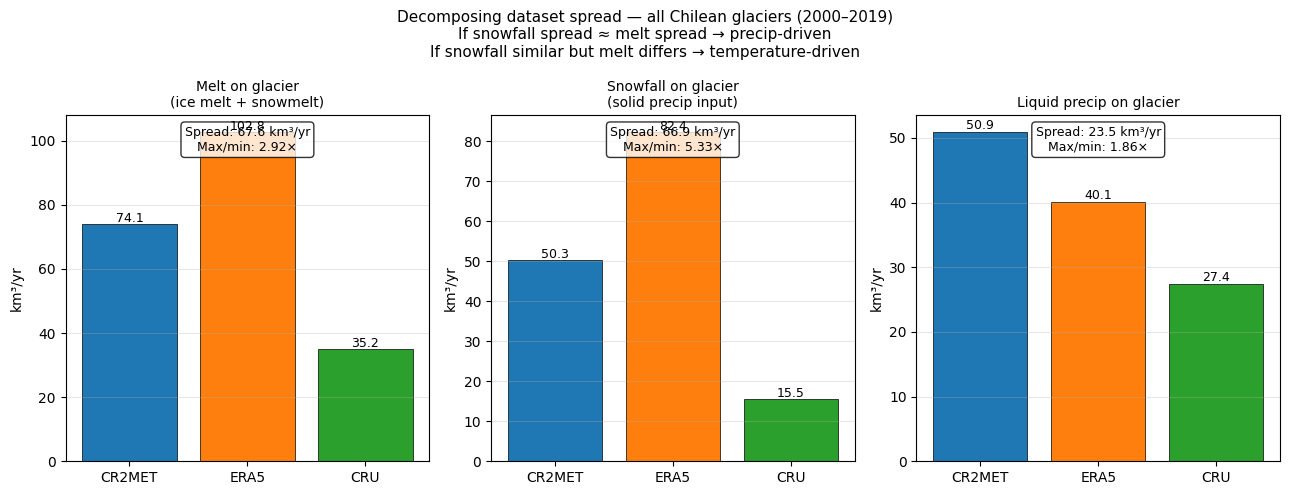

In [14]:
# ── Cell 3: Decompose national runoff spread: melt vs snowfall across datasets
results = []
for ds_name, tag in DATASETS.items():
    total_melt = total_snowfall = total_liq_prcp = 0.0
    for cl in CLUSTERS:
        ds       = xr.open_dataset(nc_path(ds_name, cl))
        melt     = ds['melt_on_glacier_monthly'].values[YEAR_OFFSET:, :, :]
        snowfall = ds['snowfall_on_glacier_monthly'].values[YEAR_OFFSET:, :, :]
        liq_prcp = ds['liq_prcp_on_glacier_monthly'].values[YEAR_OFFSET:, :, :]
        ds.close()
        total_melt     += np.nansum(melt)
        total_snowfall += np.nansum(snowfall)
        total_liq_prcp += np.nansum(liq_prcp)

    n = len(YEARS)
    results.append({
        'dataset':        ds_name,
        'melt_km3yr':     total_melt     / 1e12 / n,
        'snowfall_km3yr': total_snowfall / 1e12 / n,
        'liq_prcp_km3yr': total_liq_prcp / 1e12 / n,
    })
    print(f'{ds_name}: melt={total_melt/1e12/n:.1f}  '
          f'snowfall={total_snowfall/1e12/n:.1f}  '
          f'liq_prcp={total_liq_prcp/1e12/n:.1f} km³/yr')

df_decomp = pd.DataFrame(results).set_index('dataset')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, col, title in zip(axes,
    ['melt_km3yr', 'snowfall_km3yr', 'liq_prcp_km3yr'],
    ['Melt on glacier\n(ice melt + snowmelt)',
     'Snowfall on glacier\n(solid precip input)',
     'Liquid precip on glacier']):
    vals  = df_decomp[col]
    bars  = ax.bar(vals.index, vals.values,
                   color=[DS_COLORS[d] for d in vals.index],
                   edgecolor='k', lw=0.5)
    spread = vals.max() - vals.min()
    ratio  = vals.max() / vals.min()
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('km³/yr')
    ax.grid(True, alpha=0.3, axis='y')
    ax.text(0.5, 0.97,
            f'Spread: {spread:.1f} km³/yr\nMax/min: {ratio:.2f}×',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=9)

fig.suptitle('Decomposing dataset spread — all Chilean glaciers (2000–2019)\n'
             'If snowfall spread ≈ melt spread → precip-driven\n'
             'If snowfall similar but melt differs → temperature-driven',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/dataset_spread_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

CR2MET   OT3  : T=-2.44°C  P=522 mm/yr
CR2MET   DA1  : T=-2.59°C  P=186 mm/yr
CR2MET   DA2  : T=-0.95°C  P=710 mm/yr
CR2MET   DA3  : T=2.62°C  P=1448 mm/yr
CR2MET   WA1  : T=5.78°C  P=2753 mm/yr
CR2MET   WA2  : T=5.10°C  P=3416 mm/yr
CR2MET   WA3  : T=3.30°C  P=3193 mm/yr
CR2MET   WA4  : T=2.36°C  P=1720 mm/yr
CR2MET   WA5  : T=4.14°C  P=3854 mm/yr
CR2MET   WA6  : T=3.30°C  P=2640 mm/yr
ERA5     OT3  : T=5.40°C  P=822 mm/yr
ERA5     DA1  : T=-2.28°C  P=240 mm/yr
ERA5     DA2  : T=-0.74°C  P=506 mm/yr
ERA5     DA3  : T=1.26°C  P=779 mm/yr
ERA5     WA1  : T=6.68°C  P=1772 mm/yr
ERA5     WA2  : T=5.68°C  P=3287 mm/yr
ERA5     WA3  : T=1.96°C  P=4777 mm/yr
ERA5     WA4  : T=2.97°C  P=2587 mm/yr
ERA5     WA5  : T=3.41°C  P=5740 mm/yr
ERA5     WA6  : T=4.61°C  P=3772 mm/yr
CRU      OT3  : T=1.73°C  P=216 mm/yr
CRU      DA1  : T=0.94°C  P=248 mm/yr
CRU      DA2  : T=-0.62°C  P=591 mm/yr
CRU      DA3  : T=3.88°C  P=754 mm/yr
CRU      WA1  : T=8.31°C  P=1620 mm/yr
CRU      WA2  : T=6.14°C  P=15

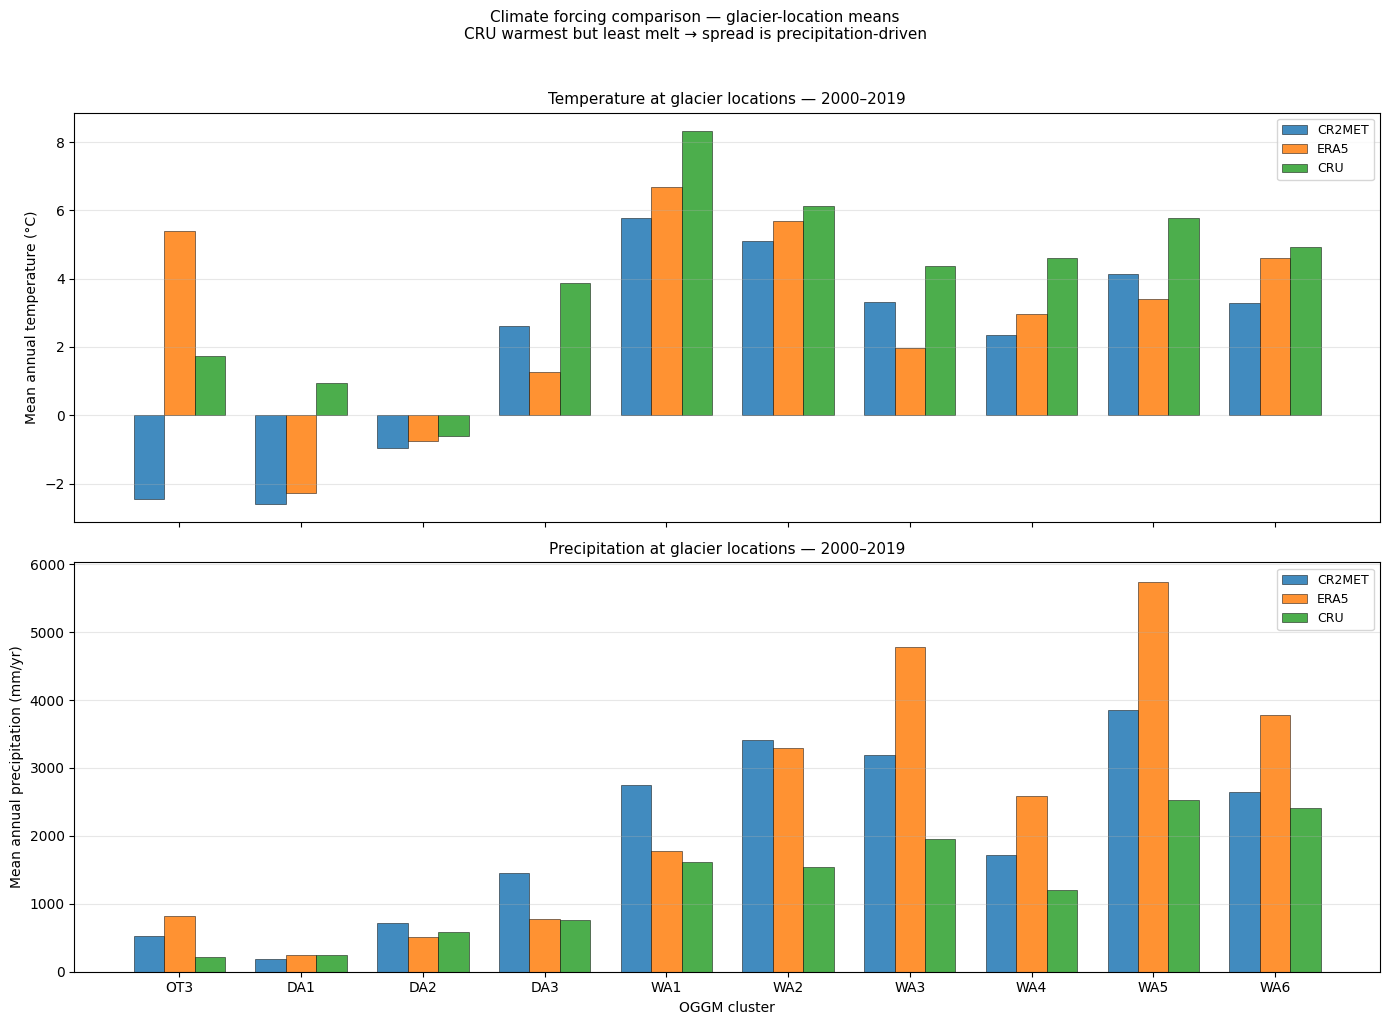


Summary — mean across all clusters:
         mean_temp_C  mean_prec_mmyr
dataset                             
CR2MET          2.06         2044.18
CRU             4.00         1304.96
ERA5            2.89         2428.14


In [15]:
# ── Cell 4: Climate forcing comparison: temp and precip at glacier locations ───────
records = []
for ds_name in DATASETS:
    for cl in CLUSTERS:
        temp_path = f'{OUTPUT_ROOT}/{ds_name}/{cl}/lista_temp.csv'
        prec_path = f'{OUTPUT_ROOT}/{ds_name}/{cl}/lista_prec.csv'
        try:
            temp_df = pd.read_csv(temp_path, header=0).iloc[
                LISTA_ROW_START:LISTA_ROW_END]
            prec_df = pd.read_csv(prec_path, header=0).iloc[
                LISTA_ROW_START:LISTA_ROW_END]
        except FileNotFoundError:
            print(f'Missing: {ds_name}/{cl}')
            continue

        mean_temp     = temp_df.values.mean()
        n_complete    = (len(prec_df) // 12) * 12
        prec_arr      = prec_df.values[:n_complete].reshape(
            n_complete // 12, 12, -1)
        mean_ann_prec = prec_arr.sum(axis=1).mean(axis=0).mean()

        records.append({
            'dataset': ds_name, 'cluster': cl,
            'mean_temp_C': mean_temp, 'mean_prec_mmyr': mean_ann_prec,
        })
        print(f'{ds_name:8s} {cl:5s}: T={mean_temp:.2f}°C  '
              f'P={mean_ann_prec:.0f} mm/yr')

df_climate = pd.DataFrame(records)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
x, width  = np.arange(len(CLUSTERS)), 0.25
offsets   = [-width, 0, width]

for ax, var, ylabel, title in zip(axes,
    ['mean_temp_C', 'mean_prec_mmyr'],
    ['Mean annual temperature (°C)', 'Mean annual precipitation (mm/yr)'],
    ['Temperature at glacier locations — 2000–2019',
     'Precipitation at glacier locations — 2000–2019']):
    for i, ds_name in enumerate(DATASETS):
        sub  = df_climate[df_climate['dataset'] == ds_name].set_index('cluster')
        vals = [sub.loc[cl, var] if cl in sub.index else np.nan
                for cl in CLUSTERS]
        ax.bar(x + offsets[i], vals, width, label=ds_name,
               color=DS_COLORS[ds_name], edgecolor='k', lw=0.4, alpha=0.85)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(x)
    ax.set_xticklabels(CLUSTERS, fontsize=10)

axes[1].set_xlabel('OGGM cluster', fontsize=10)
fig.suptitle('Climate forcing comparison — glacier-location means\n'
             'CRU warmest but least melt → spread is precipitation-driven',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/climate_forcing_comparison_temp_prec.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary — mean across all clusters:')
print(df_climate.groupby('dataset')[['mean_temp_C','mean_prec_mmyr']]
      .mean().round(2).to_string())

it looks like glacier melt is more precipitation driven than temperature driven. CRU is warmer than ERA or CR2, but doesn't generate more melt. Instead, ERA5 generates the most melt and has the most precipitation, CR2met has the second highest precip and melt, and CRU has the last of both. This suggests that more precip in ERA5 drives more accumulation and subsequent snowmelt, producing higher total melt

mu_star summary across all WA1 glaciers:
dataset  CR2MET    CRU   ERA5
count     672.0  672.0  672.0
mean       42.6   20.6   62.4
std        39.0   23.8   45.0
min         5.0    5.0    8.8
25%        21.1   11.1   41.5
50%        33.7   16.3   49.7
75%        52.7   24.6   66.7
max       543.4  535.6  558.6

Mean mu_star per dataset:
dataset
CR2MET    42.6
CRU       20.6
ERA5      62.4
dtype: float64

Ratio ERA5/CR2MET: 2.05
Ratio CRU/CR2MET:  0.64


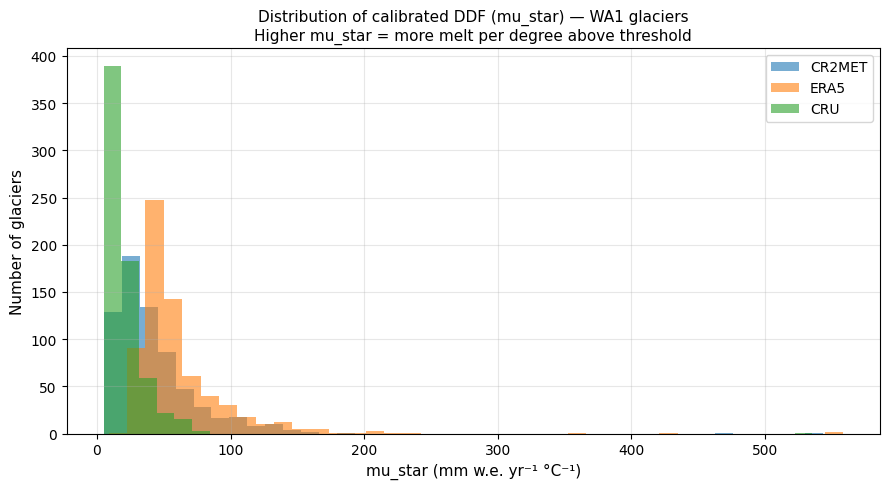

In [16]:
# ── Cell 5: Distribution of DDF (mu_star) ───────

mustar_records = []

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    files = glob.glob(
        f'{BASE_PATH}/{ds_name}/WA1/per_glacier/**/local_mustar.json',
        recursive=True)
    for fpath in files:
        try:
            with open(fpath) as f:
                d = json.load(f)
            mu = d.get('mu_star_glacierwide')
            if mu is None or np.isnan(float(mu)):
                continue
            mustar_records.append({
                'dataset': ds_name,
                'rgi_id':  d['rgi_id'],
                'mu_star': float(mu),
            })
        except Exception:
            continue

df_mu  = pd.DataFrame(mustar_records)
pivot  = df_mu.pivot(index='rgi_id', columns='dataset',
                     values='mu_star').dropna()

print('mu_star summary across all WA1 glaciers:')
print(pivot.describe().round(1))
print()
print('Mean mu_star per dataset:')
print(pivot.mean().round(1))
print()
print('Ratio ERA5/CR2MET:', (pivot['ERA5']/pivot['CR2MET']).mean().round(2))
print('Ratio CRU/CR2MET: ', (pivot['CRU']/pivot['CR2MET']).mean().round(2))

fig, ax = plt.subplots(figsize=(9, 5))
DS_COLORS = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    ax.hist(pivot[ds_name], bins=40, alpha=0.6,
            color=DS_COLORS[ds_name], label=ds_name, edgecolor='none')
ax.set_xlabel('mu_star (mm w.e. yr⁻¹ °C⁻¹)', fontsize=11)
ax.set_ylabel('Number of glaciers', fontsize=11)
ax.set_title('Distribution of calibrated DDF (mu_star) — WA1 glaciers\n'
             'Higher mu_star = more melt per degree above threshold',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/all_chile_results_v2/mustar_distribution_WA1.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Cell 6: Rainfall fraction of total precip on glacier per cluster ───────
print(f'{"Dataset":8s} {"Cluster":6s} {"Snowfall":10s} {"Liq precip":10s} '
      f'{"Total precip":12s} {"Rain %":8s}')
print('-' * 60)

for ds_name in DATASETS:
    for cl in CLUSTERS:
        try:
            ds   = xr.open_dataset(nc_path(ds_name, cl))
            snow = ds['snowfall_on_glacier_monthly'].values[YEAR_OFFSET:,:,:]
            liq  = ds['liq_prcp_on_glacier_monthly'].values[YEAR_OFFSET:,:,:]
            ds.close()

            total_snow = np.nansum(snow)
            total_liq  = np.nansum(liq)
            total_prcp = total_snow + total_liq
            rain_pct   = total_liq / total_prcp * 100 if total_prcp > 0 else np.nan

            print(f'{ds_name:8s} {cl:6s} '
                  f'{total_snow/1e12/20:10.2f} '
                  f'{total_liq/1e12/20:10.2f} '
                  f'{total_prcp/1e12/20:12.2f} '
                  f'{rain_pct:8.1f}%')
        except FileNotFoundError:
            print(f'{ds_name:8s} {cl:6s} MISSING')

Dataset  Cluster Snowfall   Liq precip Total precip Rain %  
------------------------------------------------------------
CR2MET   OT3          0.01       0.00         0.01     10.2%
CR2MET   DA1          0.06       0.01         0.06     10.2%
CR2MET   DA2          0.18       0.01         0.19      6.9%
CR2MET   DA3          0.48       0.11         0.59     18.6%
CR2MET   WA1          0.66       0.35         1.01     34.9%
CR2MET   WA2          3.67       3.29         6.96     47.3%
CR2MET   WA3         21.83      26.02        47.85     54.4%
CR2MET   WA4          9.52       7.04        16.56     42.5%
CR2MET   WA5          6.08       6.57        12.64     51.9%
CR2MET   WA6          7.83       7.55        15.38     49.1%
ERA5     OT3          0.01       0.00         0.01      6.8%
ERA5     DA1          0.09       0.01         0.09      5.8%
ERA5     DA2          0.23       0.01         0.25      5.0%
ERA5     DA3          0.51       0.03         0.54      5.2%
ERA5     WA1          0.

In [18]:
# ── Cell 7: Spatial join — assign RGI glaciers to CAMELS gauge polygons ───
#
# METHOD: Point-in-polygon join using glacier centroids.
# Glaciers assigned to ALL containing polygons (nested basins intentional).
# De-duplicated version assigns each glacier to smallest basin only
# — used for national melt totals to avoid double-counting.

rgi_bna = pd.read_csv(RGI_PATH)
rgi_bna['COD_CUEN'] = rgi_bna['COD_CUEN'].astype(str).str.strip()
rgi_gdf = gpd.GeoDataFrame(
    rgi_bna,
    geometry=gpd.points_from_xy(rgi_bna['CenLon'], rgi_bna['CenLat']),
    crs='EPSG:4326'
)
print(f'RGI glaciers: {len(rgi_gdf)}')

bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
print(f'CAMELS gauges: {len(bounds)}')

q_wide = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv', parse_dates=['date'])
q_wide = q_wide[(q_wide['year'] >= 2000) & (q_wide['year'] <= 2019)].reset_index(drop=True)
q_gauges = set(q_wide.columns[4:].astype(str))
print(f'Gauges with Q data: {len(q_gauges)}')

# Spatial join (all nested assignments)
joined = gpd.sjoin(
    rgi_gdf,
    bounds[['gauge_id','gauge_name','area_km2','geometry']],
    how='left', predicate='within'
)
joined_valid = joined[joined['gauge_id'].notna()].copy()
joined_valid = joined_valid[joined_valid['gauge_id'].isin(q_gauges)]

print(f'\nNESTED (all assignments):')
print(f'  Glacier-gauge pairs: {len(joined_valid)}')
print(f'  Unique glaciers:     {joined_valid["RGIId"].nunique()}')
print(f'  Unique gauges:       {joined_valid["gauge_id"].nunique()}')

# De-duplicated (smallest basin per glacier) for national totals
joined_dedup = (joined_valid
                .sort_values('area_km2')
                .groupby('RGIId', as_index=False)
                .first())

print(f'\nDE-DUPLICATED (smallest basin):')
print(f'  Unique glaciers: {len(joined_dedup)}')
print(f'  Unique gauges:   {joined_dedup["gauge_id"].nunique()}')

# Build GAUGE_INFO (nested)
GAUGE_INFO = {}
for gauge_id, grp in joined_valid.groupby('gauge_id'):
    GAUGE_INFO[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'cen_lon':          grp['CenLon'].mean(),
    }

# Build GAUGE_INFO_DEDUP (de-duplicated)
GAUGE_INFO_DEDUP = {}
for gauge_id, grp in joined_dedup.groupby('gauge_id'):
    GAUGE_INFO_DEDUP[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'primary_cluster':  grp['Cluster'].value_counts().index[0],
    }

print(f'\nGAUGE_INFO (nested):    {len(GAUGE_INFO)} gauges')
print(f'GAUGE_INFO_DEDUP:        {len(GAUGE_INFO_DEDUP)} gauges')

if '9402001' in GAUGE_INFO:
    info = GAUGE_INFO['9402001']
    print(f"\nAllipen (9402001): {info['n_glaciers']} glaciers, "
          f"{info['glacier_area_km2']:.1f} km2, clusters: {info['clusters']}")

joined_valid[['RGIId','CenLon','CenLat','Area','Cluster','COD_CUEN',
              'gauge_id','gauge_name','area_km2']].to_csv(
    f'{OUT_DIR}/spatial_join_nested.csv', index=False)
joined_dedup[['RGIId','CenLon','CenLat','Area','Cluster','COD_CUEN',
              'gauge_id','gauge_name','area_km2']].to_csv(
    f'{OUT_DIR}/spatial_join_dedup.csv', index=False)
print('Spatial join CSVs saved')

RGI glaciers: 13246
CAMELS gauges: 516
Gauges with Q data: 516

NESTED (all assignments):
  Glacier-gauge pairs: 21510
  Unique glaciers:     6883
  Unique gauges:       266

DE-DUPLICATED (smallest basin):
  Unique glaciers: 6883
  Unique gauges:   157

GAUGE_INFO (nested):    266 gauges
GAUGE_INFO_DEDUP:        157 gauges

Allipen (9402001): 92 glaciers, 35.6 km2, clusters: ['WA1']
Spatial join CSVs saved


In [20]:
# ── Cell 8: Q completeness filter — Alexis's criteria (daily data) ────────
#
# Uses q_m3s_day.csv for proper daily completeness assessment.
#
# TWO-ZONE RULE:
#   North/Central (lat > -38S): >= 5 complete years in 2000-2009
#                                AND >= 5 complete years in 2010-2019
#   South         (lat <= -38S): >= 10 complete years anywhere in 2000-2019
#
# A year is "complete" if:
#   Summer months (Dec-Apr): >= 70% of days non-NaN and Q >= 0
#     AND all 5 of Dec, Jan, Feb, Mar, Apr must meet this threshold
#   Winter months (May-Nov): >= 50% of days non-NaN and Q >= 0
#     AND at least 4 of 7 winter months must meet this threshold
#
# Note: Dec of a year is treated as belonging to the FOLLOWING year's
# summer (e.g. Dec 2004 counts toward the 2005 summer season).
# This matches Southern Hemisphere hydrological convention.
#
# GAUGE_INFO_FRAC → passes → streamflow fraction analysis
# GAUGE_INFO_MELT → fails  → national melt totals only

LAT_BOUNDARY     = -38.0
SUMMER_MONTHS    = [12, 1, 2, 3, 4]
WINTER_MONTHS    = [5, 6, 7, 8, 9, 10, 11]
SUMMER_THRESHOLD = 0.70
WINTER_THRESHOLD = 0.50

print('Loading daily Q data...')
q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
q_day = q_day[
    (q_day['year'] >= 1999) & (q_day['year'] <= 2019)
].copy()
print(f'Daily Q loaded: {len(q_day)} rows x {len(q_day.columns)-4} gauges')

def days_in_month(year, month):
    return calendar.monthrange(year, month)[1]

def month_completeness(q_day_col, year, month):
    """
    Fraction of days with valid Q in a given year-month.
    q_day_col: Series with date index, values = Q
    """
    mask = (q_day['year'] == year) & (q_day['month'] == month)
    vals = q_day_col[mask]
    if len(vals) == 0:
        return 0.0
    n_valid = (vals.notna() & (vals >= 0)).sum()
    return n_valid / days_in_month(year, month)

def assess_completeness(gauge_id, cen_lat):
    if gauge_id not in q_day.columns:
        return {'passes': False, 'reason': 'no Q column',
                'n_complete': 0, 'n_pre2010': 0, 'n_post2010': 0,
                'complete_years': []}

    col = q_day[gauge_id]

    complete_years = []
    for year in range(2000, 2020):

        # Summer: Dec of PRIOR year + Jan-Apr of this year
        dec_frac  = month_completeness(col, year - 1, 12)
        jan_frac  = month_completeness(col, year, 1)
        feb_frac  = month_completeness(col, year, 2)
        mar_frac  = month_completeness(col, year, 3)
        apr_frac  = month_completeness(col, year, 4)

        summer_fracs = [dec_frac, jan_frac, feb_frac, mar_frac, apr_frac]
        summer_ok    = all(f >= SUMMER_THRESHOLD for f in summer_fracs)

        # Winter: May-Nov, need >= 4 of 7 months above 50% threshold
        winter_fracs = [month_completeness(col, year, mo)
                        for mo in WINTER_MONTHS]
        winter_ok    = sum(f >= WINTER_THRESHOLD
                           for f in winter_fracs) >= 4

        if summer_ok and winter_ok:
            complete_years.append(year)

    n_pre  = sum(1 for y in complete_years if y <= 2009)
    n_post = sum(1 for y in complete_years if y >= 2010)
    n_tot  = len(complete_years)

    if cen_lat > LAT_BOUNDARY:
        passes = (n_pre >= 5 and n_post >= 5)
        reason = (f'OK (N/C): {n_pre} pre-2010, {n_post} post-2010'
                  if passes else
                  f'FAIL (N/C): {n_pre} pre-2010, {n_post} post-2010')
    else:
        passes = (n_tot >= 10)
        reason = (f'OK (S): {n_tot} complete years'
                  if passes else
                  f'FAIL (S): only {n_tot} complete years')

    return {
        'passes':         passes,
        'reason':         reason,
        'n_complete':     n_tot,
        'n_pre2010':      n_pre,
        'n_post2010':     n_post,
        'complete_years': complete_years,
    }

# Run for all gauges
print('Assessing completeness...')
gauge_completeness = {}
for gauge_id, info in GAUGE_INFO.items():
    gauge_completeness[gauge_id] = assess_completeness(
        gauge_id, info['cen_lat'])

# Split
GAUGE_INFO_FRAC = {}
GAUGE_INFO_MELT = {}
for gauge_id, info in GAUGE_INFO.items():
    comp = gauge_completeness[gauge_id]
    if comp['passes']:
        i = dict(info)
        i['n_complete_q_years'] = comp['n_complete']
        i['n_pre2010']          = comp['n_pre2010']
        i['n_post2010']         = comp['n_post2010']
        i['complete_years']     = comp['complete_years']
        GAUGE_INFO_FRAC[gauge_id] = i
    else:
        GAUGE_INFO_MELT[gauge_id] = info

gauge_complete_years = {gid: gauge_completeness[gid]['n_complete']
                        for gid in GAUGE_INFO}

print(f'\nQ completeness filter (Alexis criteria, daily data):')
print(f'  Threshold: summer >= {SUMMER_THRESHOLD:.0%} days, '
      f'winter >= {WINTER_THRESHOLD:.0%} days')
print(f'  Pass — fraction analysis: {len(GAUGE_INFO_FRAC)}')
print(f'  Fail — melt totals only:  {len(GAUGE_INFO_MELT)}')
print()

# Core study gauges
STUDY_GAUGES = ['9402001','9437002','9140001','8394001',
                '8141001','7383001','7123001','10122001']
print('Core study gauge status:')
for gid in STUDY_GAUGES:
    comp   = gauge_completeness.get(gid, {})
    status = 'PASS' if gid in GAUGE_INFO_FRAC else 'FAIL'
    name   = GAUGE_INFO.get(gid, {}).get('gauge_name', '')[:35]
    lat    = GAUGE_INFO.get(gid, {}).get('cen_lat', 0)
    zone   = 'N/C' if lat > LAT_BOUNDARY else 'S'
    print(f'  {gid} {name:35s} [{zone}]  '
          f'pre={comp.get("n_pre2010","?")}  '
          f'post={comp.get("n_post2010","?")}  '
          f'tot={comp.get("n_complete","?")}  {status}')

# Full results table
print('\nAll gauges — completeness summary:')
comp_df = pd.DataFrame([
    {'gauge_id':    gid,
     'gauge_name':  GAUGE_INFO[gid]['gauge_name'][:35],
     'lat':         GAUGE_INFO[gid]['cen_lat'],
     'zone':        'N/C' if GAUGE_INFO[gid]['cen_lat'] > LAT_BOUNDARY else 'S',
     'n_pre2010':   gauge_completeness[gid]['n_pre2010'],
     'n_post2010':  gauge_completeness[gid]['n_post2010'],
     'n_complete':  gauge_completeness[gid]['n_complete'],
     'passes':      gauge_completeness[gid]['passes'],
     'reason':      gauge_completeness[gid]['reason']}
    for gid in GAUGE_INFO
]).sort_values('lat', ascending=False)

comp_df.to_csv(f'{OUT_DIR}/gauge_completeness_assessment.csv', index=False)
print(comp_df[['gauge_id','gauge_name','lat','zone',
               'n_pre2010','n_post2010','n_complete','passes']]
      .to_string(index=False))

Loading daily Q data...
Daily Q loaded: 7670 rows x 516 gauges
Assessing completeness...

Q completeness filter (Alexis criteria, daily data):
  Threshold: summer >= 70% days, winter >= 50% days
  Pass — fraction analysis: 143
  Fail — melt totals only:  123

Core study gauge status:
  9402001 Rio Allipen En Melipeuco            [S]  pre=8  post=6  tot=14  PASS
  9437002 Rio Tolten En Teodoro Schmidt       [S]  pre=8  post=10  tot=18  PASS
  9140001 Rio Cautin En Almagro               [S]  pre=9  post=4  tot=13  PASS
  8394001 Rio Biobio En Desembocadura         [N/C]  pre=9  post=5  tot=14  PASS
  8141001 Rio Itata En Coelemu                [N/C]  pre=9  post=5  tot=14  PASS
  7383001 Rio Maule En Forel                  [N/C]  pre=10  post=8  tot=18  PASS
  7123001 Rio Mataquito En Licanten           [N/C]  pre=9  post=8  tot=17  PASS
  10122001 Rio Calle Calle En Balsa San Javier [S]  pre=6  post=0  tot=6  FAIL

All gauges — completeness summary:
gauge_id                          gau

In [21]:
# ── Cell 9: Spatial visualisation — single basin check ────────────────────
#
# GREEN  = assigned to this gauge
# ORANGE = centroid inside a neighbouring polygon (assigned elsewhere)
# RED    = unmatched (outside all CAMELS polygons)

def plot_basin_glacier_assignment(gauge_id, buffer_deg=0.3):
    basin = bounds[bounds['gauge_id'] == gauge_id]
    if len(basin) == 0:
        print(f'gauge_id {gauge_id} not found in bounds')
        return
    basin_geom = basin.geometry.iloc[0]
    name       = basin['gauge_name'].iloc[0]
    minx, miny, maxx, maxy = basin_geom.bounds

    rgi_clip = rgi_gdf.cx[
        minx - buffer_deg : maxx + buffer_deg,
        miny - buffer_deg : maxy + buffer_deg
    ]
    assigned_here  = set(GAUGE_INFO.get(gauge_id, {}).get('rgi_ids', []))
    assigned_other = set(joined_valid[
        (joined_valid['gauge_id'] != gauge_id) &
        (joined_valid['RGIId'].isin(rgi_clip['RGIId']))
    ]['RGIId'])
    unmatched = set(rgi_clip['RGIId']) - assigned_here - assigned_other

    colors = rgi_clip['RGIId'].map(
        lambda r: 'green'  if r in assigned_here  else
                  'orange' if r in assigned_other else 'red'
    )

    fig, ax = plt.subplots(figsize=(9, 8))
    basin.plot(ax=ax, facecolor='lightblue', edgecolor='navy',
               linewidth=1.5, alpha=0.3)
    bounds.cx[
        minx - buffer_deg : maxx + buffer_deg,
        miny - buffer_deg : maxy + buffer_deg
    ].plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.5, alpha=0.5)

    for color, label, marker in [
        ('green',  f'Assigned to {gauge_id} (n={len(assigned_here)})',  'o'),
        ('orange', f'Assigned elsewhere (n={len(assigned_other)})',      's'),
        ('red',    f'Unmatched (n={len(unmatched)})',                    '^'),
    ]:
        subset = rgi_clip[colors.values == color]
        if len(subset):
            ax.scatter(subset.geometry.x, subset.geometry.y,
                       c=color, s=20, marker=marker,
                       label=label, zorder=5, edgecolors='k', lw=0.3)

    ax.set_xlim(minx - buffer_deg, maxx + buffer_deg)
    ax.set_ylim(miny - buffer_deg, maxy + buffer_deg)
    ax.set_title(f'{gauge_id} — {name}\n'
                 f'green=assigned here, orange=assigned elsewhere, red=unmatched')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/basin_check_{gauge_id}.png', dpi=120)
    plt.show()
    print(f'  Assigned to this basin: {len(assigned_here)}')
    print(f'  Assigned elsewhere:     {len(assigned_other)}')
    print(f'  Unmatched:              {len(unmatched)}')

# Example: plot_basin_glacier_assignment('9402001')
print('plot_basin_glacier_assignment() defined — call with any gauge_id')

plot_basin_glacier_assignment() defined — call with any gauge_id


In [ ]:
# ── Cell 10: Spatial visualisation — multi-basin overview ─────────────────
#
# Plot multiple basins on one map. Each basin gets a unique colour.
# Transparent polygon fill, opaque glacier dots, grey = unassigned.
# Country borders included for geographic context.

def plot_study_area_assignments(gauge_ids, buffer_deg=0.2, figsize=(12, 12)):
    basins = bounds[bounds['gauge_id'].isin(gauge_ids)]
    minx = basins.geometry.bounds['minx'].min() - buffer_deg
    maxx = basins.geometry.bounds['maxx'].max() + buffer_deg
    miny = basins.geometry.bounds['miny'].min() - buffer_deg
    maxy = basins.geometry.bounds['maxy'].max() + buffer_deg + 1.0  # extra space north

    cmap    = cm.get_cmap('tab20', len(gauge_ids))
    palette = {gid: cmap(i) for i, gid in enumerate(gauge_ids)}
    rgi_clip = rgi_gdf.cx[minx:maxx, miny:maxy].copy()

    fig, ax = plt.subplots(figsize=figsize)

    # Country borders
    try:
        world = gpd.read_file(
            'https://naturalearth.s3.amazonaws.com/50m_cultural/'
            'ne_50m_admin_0_countries.zip')
        for country, color in [('Chile','#e8f4e8'), ('Argentina','#f0f0e8')]:
            c = world[world['NAME'] == country]
            if len(c):
                c.plot(ax=ax, facecolor=color, edgecolor='#555555',
                       linewidth=0.8, zorder=0)
    except Exception:
        print('Country borders unavailable — continuing without')

    # Background CAMELS boundaries
    bounds.cx[minx:maxx, miny:maxy].plot(
        ax=ax, facecolor='none', edgecolor='lightgrey', linewidth=0.4, zorder=1)

    # Study basin polygons
    for gid in gauge_ids:
        basin = bounds[bounds['gauge_id'] == gid]
        if len(basin) == 0:
            continue
        color = palette[gid]
        basin.plot(ax=ax,
                   facecolor=(*color[:3], 0.15),
                   edgecolor=(*color[:3], 0.9),
                   linewidth=1.8, zorder=2)

    # Glaciers coloured by assigned basin
    all_assigned = {gid: set(GAUGE_INFO.get(gid, {}).get('rgi_ids', []))
                    for gid in gauge_ids}
    assigned_any = set().union(*all_assigned.values())

    for gid in gauge_ids:
        color    = palette[gid]
        rgi_here = rgi_clip[rgi_clip['RGIId'].isin(all_assigned[gid])]
        if len(rgi_here):
            ax.scatter(rgi_here.geometry.x, rgi_here.geometry.y,
                       color=color, s=25, zorder=5,
                       edgecolors='k', linewidths=0.3, alpha=0.9)

    # Unassigned glaciers
    rgi_unassigned = rgi_clip[~rgi_clip['RGIId'].isin(assigned_any)]
    if len(rgi_unassigned):
        ax.scatter(rgi_unassigned.geometry.x, rgi_unassigned.geometry.y,
                   color='grey', s=8, zorder=4, alpha=0.4)

    handles = [
        Patch(facecolor=(*palette[gid][:3], 0.5),
              edgecolor=palette[gid], linewidth=1.5,
              label=f"{gid} {GAUGE_INFO[gid]['gauge_name'][:30]} "
                    f"(n={GAUGE_INFO[gid]['n_glaciers']})")
        for gid in gauge_ids if gid in GAUGE_INFO
    ]
    if len(rgi_unassigned):
        handles.append(Line2D([0],[0], marker='o', color='w',
                               markerfacecolor='grey', markersize=6,
                               label=f'Unassigned (n={len(rgi_unassigned)})'))

    ax.legend(handles=handles, fontsize=7.5, loc='upper left',
              framealpha=0.9, ncol=1)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('RGI glacier assignments to CAMELS basins\n'
                 '(coloured dots = assigned to that basin, grey = unassigned)',
                 fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/basin_assignments_overview.png', dpi=150,
                bbox_inches='tight')
    plt.show()


# Example usage:
# plot_study_area_assignments(['7123001','7383001','8141001','8394001',
#                              '9140001','9402001','9437002','10122001'])
print('plot_study_area_assignments() defined — call with a list of gauge_ids')

plot_study_area_assignments() defined — call with a list of gauge_ids


In [22]:
# ── Cell 11: Load all cluster NetCDFs (all 3 datasets) ────────────────────
# ALL_DS[dataset_name][cluster] = xarray.Dataset
# melt_on_glacier_monthly:     (n_years, 12, n_glaciers)  in kg
# liq_prcp_on_glacier_monthly: (n_years, 12, n_glaciers)  in kg
# area:                        (n_years, n_glaciers)       in m2

ALL_DS = {}
for ds_name in DATASETS:
    print(f'Loading {ds_name}...')
    ALL_DS[ds_name] = {}
    for cl in CLUSTERS:
        ALL_DS[ds_name][cl] = xr.open_dataset(nc_path(ds_name, cl))
    print(f'  {ds_name}: all {len(CLUSTERS)} clusters loaded')

raw_time = ALL_DS['CR2MET']['WA1'].time.values
print(f'\nCR2MET WA1 time axis (raw): {raw_time[:5]}')
print(f'YEAR_OFFSET={YEAR_OFFSET}: index {YEAR_OFFSET} = year 2000')
print(f'Melt shape: {ALL_DS["CR2MET"]["WA1"]["melt_on_glacier_monthly"].shape}')
print('All datasets loaded')

Loading CR2MET...
  CR2MET: all 10 clusters loaded
Loading ERA5...
  ERA5: all 10 clusters loaded
Loading CRU...
  CRU: all 10 clusters loaded

CR2MET WA1 time axis (raw): [1999. 2000. 2001. 2002. 2003.]
YEAR_OFFSET=1: index 1 = year 2000
Melt shape: (24, 12, 678)
All datasets loaded


In [23]:
# ── Cell 12: OGGM simulation vs streamflow analysis coverage ──────────────
print('OGGM simulation vs streamflow analysis coverage:\n')
print(f'{"Cluster":6s}  {"OGGM area (km²)":16s}  '
      f'{"Gauged area (km²)":18s}  {"Coverage %"}')

for cl in CLUSTERS:
    oggm_area   = rgi_bna[rgi_bna['Cluster'] == cl]['Area'].sum()
    gauged_area = sum(
        info['glacier_area_km2']
        for gid, info in GAUGE_INFO_DEDUP.items()
        if info['primary_cluster'] == cl
    )
    pct = gauged_area / oggm_area * 100 if oggm_area > 0 else 0
    print(f'{cl:6s}  {oggm_area:16.1f}  {gauged_area:18.1f}  {pct:.1f}%')

total_oggm   = rgi_bna['Area'].sum()
total_gauged = sum(info['glacier_area_km2']
                   for info in GAUGE_INFO_DEDUP.values())
print(f'\n{"TOTAL":6s}  {total_oggm:16.1f}  {total_gauged:18.1f}  '
      f'{total_gauged/total_oggm*100:.1f}%')

print('\nConclusion:')
print('- OGGM simulates 100% of Chilean RGI glaciers by area')
print('- Only 26.7% of that area drains to a CAMELS gauge')
print('- WA3 (NPI/SPI) has 10,947 km² simulated but most is ungauged')
print('- National TOTALS use all OGGM output (100%)')
print('- Streamflow FRACTIONS use only gauged basins (26.7%)')

OGGM simulation vs streamflow analysis coverage:

Cluster  OGGM area (km²)   Gauged area (km²)   Coverage %
OT3                 13.2                12.5  94.6%
DA1                148.1               140.1  94.6%
DA2                253.9               253.0  99.6%
DA3                390.6               390.4  99.9%
WA1                307.9               306.9  99.7%
WA2               1737.9               908.4  52.3%
WA3              10946.5               354.2  3.2%
WA4               6474.0              4512.3  69.7%
WA5               2588.7                 0.0  0.0%
WA6               4638.4               460.8  9.9%

TOTAL            27499.4              7338.7  26.7%

Conclusion:
- OGGM simulates 100% of Chilean RGI glaciers by area
- Only 26.7% of that area drains to a CAMELS gauge
- WA3 (NPI/SPI) has 10,947 km² simulated but most is ungauged
- National TOTALS use all OGGM output (100%)
- Streamflow FRACTIONS use only gauged basins (26.7%)


In [ ]:
# ── Cell 13: Core extraction function ─────────────────────────────────────
#
# Extracts monthly glacier runoff for one gauge and one dataset.
# UNIT CONVERSION: NetCDF stores melt in kg. Divide by WATER_DENSITY -> m3.
# TEMPORAL MASKING: Q NaN months produce NaN fractions — excluded from means.

def extract_basin_outputs(gauge_id, dataset_name,
                          year_offset=YEAR_OFFSET,
                          gauge_info_dict=None):
    if gauge_info_dict is None:
        gauge_info_dict = GAUGE_INFO_FRAC

    info       = gauge_info_dict[gauge_id]
    rgi_ids    = set(info['rgi_ids'])
    cluster_ds = ALL_DS[dataset_name]

    rows = []
    for yr_idx, year in enumerate(YEARS):
        nc_yr = yr_idx + year_offset
        for mo_idx, month in enumerate(MONTHS):
            melt_total     = 0.0
            liq_prcp_total = 0.0
            area_total     = 0.0

            for cluster in info['clusters']:
                ds       = cluster_ds[cluster]
                rgi_all  = list(ds.rgi_id.values)
                mask_ids = [r for r in rgi_ids if r in rgi_all]
                if not mask_ids:
                    continue
                mask = np.isin(rgi_all, mask_ids)

                melt_total     += np.nansum(
                    ds['melt_on_glacier_monthly'].values[nc_yr, mo_idx, mask]
                ) / WATER_DENSITY
                liq_prcp_total += np.nansum(
                    ds['liq_prcp_on_glacier_monthly'].values[nc_yr, mo_idx, mask]
                ) / WATER_DENSITY

                if mo_idx == 0:
                    area_total += np.nansum(ds['area'].values[nc_yr, mask])

            rows.append({
                'year':                   year,
                'month':                  month,
                'melt_on_glacier_m3':     melt_total,
                'liq_prcp_on_glacier_m3': liq_prcp_total,
                'glacier_runoff_m3':      melt_total + liq_prcp_total,
                'area_m2':                area_total if mo_idx == 0 else np.nan,
            })

    df = pd.DataFrame(rows)
    df['area_m2'] = df['area_m2'].ffill()
    return df

print('extract_basin_outputs() defined')
print('Quick test — Allipen (9402001), CR2MET...')
_test    = extract_basin_outputs('9402001', 'CR2MET')
ann_melt = _test['glacier_runoff_m3'].sum() / 1e9 / 20
print(f'  Mean annual glacier runoff: {ann_melt:.4f} km3/yr')
print(f'  Implied frac vs ~1.87 km3/yr Q: {ann_melt/1.87:.1%}  '
      f'(expected ~10-11%)')

extract_basin_outputs() defined
Quick test — Allipen (9402001), CR2MET...
  Mean annual glacier runoff: 0.1382 km3/yr
  Implied frac vs ~1.87 km3/yr Q: 7.4%  (expected ~10-11%)


Computing national totals from NetCDFs...
  CR2MET: melt=66.3  liq_prcp=46.7  total=112.9 km³/yr
  ERA5: melt=102.8  liq_prcp=40.1  total=142.9 km³/yr
  CRU: melt=35.2  liq_prcp=27.4  total=62.6 km³/yr


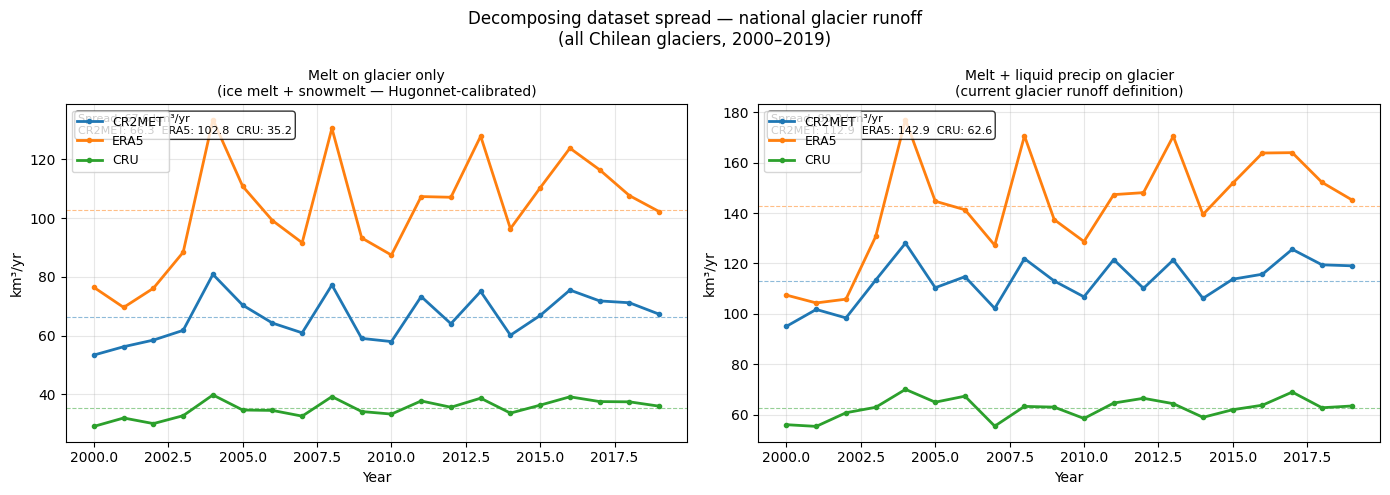


Dataset     Melt        Liq precip  Total       Rain %
CR2MET           66.26       46.67      112.92  41.3%
ERA5            102.79       40.12      142.91  28.1%
CRU              35.17       27.44       62.61  43.8%


In [25]:
# ── Cell 14: National totals — melt only vs melt + liq precip ─────────────
#
# Reads directly from NetCDFs — no dependency on RESULTS.
# Shows whether dataset spread collapses when removing liquid precip
# (Alexis's hypothesis: spread is driven by solid precip differences).

print('Computing national totals from NetCDFs...')
MELT_ONLY_TOTALS = {}
LIQ_PRCP_TOTALS  = {}

for ds_name in DATASETS:
    ann_melt     = np.zeros(len(YEARS))
    ann_liq_prcp = np.zeros(len(YEARS))

    for cl in CLUSTERS:
        ds       = xr.open_dataset(nc_path(ds_name, cl))
        melt     = ds['melt_on_glacier_monthly'].values[YEAR_OFFSET:, :, :]
        liq_prcp = ds['liq_prcp_on_glacier_monthly'].values[YEAR_OFFSET:, :, :]
        ds.close()
        for y_idx in range(len(YEARS)):
            ann_melt[y_idx]     += np.nansum(melt[y_idx, :, :])
            ann_liq_prcp[y_idx] += np.nansum(liq_prcp[y_idx, :, :])

    MELT_ONLY_TOTALS[ds_name] = pd.Series(ann_melt     / 1e12, index=YEARS)
    LIQ_PRCP_TOTALS[ds_name]  = pd.Series(ann_liq_prcp / 1e12, index=YEARS)
    print(f'  {ds_name}: melt={ann_melt.mean()/1e12:.1f}  '
          f'liq_prcp={ann_liq_prcp.mean()/1e12:.1f}  '
          f'total={(ann_melt+ann_liq_prcp).mean()/1e12:.1f} km³/yr')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
panel_data = [
    (MELT_ONLY_TOTALS,
     'Melt on glacier only\n(ice melt + snowmelt — Hugonnet-calibrated)'),
    ({ds: MELT_ONLY_TOTALS[ds] + LIQ_PRCP_TOTALS[ds] for ds in DATASETS},
     'Melt + liquid precip on glacier\n(current glacier runoff definition)'),
]
for ax, (data_dict, title) in zip(axes, panel_data):
    for ds_name, series in data_dict.items():
        ax.plot(YEARS, series.values, color=DS_COLORS[ds_name],
                lw=2, marker='o', ms=3, label=ds_name)
        ax.axhline(series.mean(), color=DS_COLORS[ds_name],
                   lw=0.8, ls='--', alpha=0.5)
    means  = {ds: data_dict[ds].mean() for ds in DATASETS}
    spread = max(means.values()) - min(means.values())
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('km³/yr')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.97,
            f'Spread: {spread:.1f} km³/yr\n'
            + '  '.join(f'{ds}: {means[ds]:.1f}' for ds in DATASETS),
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Decomposing dataset spread — national glacier runoff\n'
             '(all Chilean glaciers, 2000–2019)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/national_totals_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Dataset":10s}  {"Melt":10s}  {"Liq precip":10s}  '
      f'{"Total":10s}  {"Rain %"}')
for ds in DATASETS:
    m  = MELT_ONLY_TOTALS[ds].mean()
    lp = LIQ_PRCP_TOTALS[ds].mean()
    print(f'{ds:10s}  {m:10.2f}  {lp:10.2f}  {m+lp:10.2f}  '
          f'{lp/(m+lp)*100:.1f}%')

In [26]:
# ── Cell 15: Main loop + QC ────────────────────────────────────────────────
#
import pickle, os
pkl_path = f'{OUT_DIR}/RESULTS.pkl'
if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        RESULTS = pickle.load(f)
    print('RESULTS loaded from disk — skipping extraction loop')
else:
    # ── Pre-compute monthly Q ─────────────────────────────────────────
    Q_BY_GAUGE = {}
    for gauge_id in GAUGE_INFO_FRAC:
        if gauge_id in q_wide.columns:
            qs = q_wide[['year','month', gauge_id]].copy().rename(
                columns={gauge_id: 'q_m3s'})
            days = qs.apply(
                lambda r: pd.Timestamp(int(r['year']),
                                       int(r['month']), 1).days_in_month, axis=1)
            qs['q_m3_mon'] = qs['q_m3s'] * days * 86400
            Q_BY_GAUGE[gauge_id] = qs
        else:
            Q_BY_GAUGE[gauge_id] = None

    # ── Main extraction loop ──────────────────────────────────────────
    RESULTS  = {ds_name: {} for ds_name in DATASETS}
    n_gauges = len(GAUGE_INFO_FRAC)

    for ds_name in DATASETS:
        print(f'\n========== {ds_name} ({n_gauges} gauges) ==========')
        for i, gauge_id in enumerate(sorted(GAUGE_INFO_FRAC.keys())):
            info         = GAUGE_INFO_FRAC[gauge_id]
            complete_yrs = info.get('complete_years', YEARS)

            print(f'  [{i+1:3d}/{n_gauges}] {gauge_id} '
                  f'{info["gauge_name"][:32]:32s} ... ', end='', flush=True)
            try:
                glac_df = extract_basin_outputs(gauge_id, ds_name)

                qs = Q_BY_GAUGE[gauge_id]
                if qs is not None:
                    merged = glac_df.merge(qs, on=['year','month'], how='left')
                else:
                    merged = glac_df.copy()
                    merged['q_m3s']    = np.nan
                    merged['q_m3_mon'] = np.nan

                merged['glac_frac'] = np.where(
                    merged['q_m3_mon'].notna() & (merged['q_m3_mon'] > 0),
                    merged['glacier_runoff_m3'] / merged['q_m3_mon'],
                    np.nan
                )
                merged['complete_year'] = merged['year'].isin(complete_yrs)

                RESULTS[ds_name][gauge_id] = {
                    'gauge_name':       info['gauge_name'],
                    'monthly':          merged,
                    'n_glaciers':       info['n_glaciers'],
                    'glacier_area_km2': info['glacier_area_km2'],
                    'basin_area_km2':   info['basin_area_km2'],
                    'cen_lat':          info['cen_lat'],
                    'clusters':         info['clusters'],
                    'complete_years':   complete_yrs,
                }

                ann = (merged[merged['complete_year']]
                       .groupby('year').agg(
                           glac=('glacier_runoff_m3', 'sum'),
                           q   =('q_m3_mon',          'sum')))
                ann = ann[ann['q'] > 0]
                ann_frac = (ann['glac'] / ann['q']).mean() if len(ann) else np.nan
                print(f'frac={ann_frac:.1%}')

            except Exception as e:
                print(f'ERROR: {e}')
                RESULTS[ds_name][gauge_id] = None

        ok = sum(1 for v in RESULTS[ds_name].values() if v is not None)
        print(f'  {ds_name}: {ok}/{n_gauges} OK')

    print('\nAll datasets complete')

    # Save to disk for next time
    with open(pkl_path, 'wb') as f:
        pickle.dump(RESULTS, f)
    print(f'RESULTS saved to {pkl_path}')

# ── Cell 6b: QC — flag high-fraction gauges ────────────────────────────────
#
# Now that complete_years filtering is applied, flagged gauges reflect
# genuinely ambiguous basins (arid, low Q, possible groundwater)
# rather than data quality artefacts.

def get_mean_frac(ds_name, gauge_id):
    """Mean annual fraction using complete years only."""
    res = RESULTS[ds_name].get(gauge_id)
    if res is None:
        return np.nan
    m            = res['monthly']
    complete_yrs = res['complete_years']
    ann = (m[m['year'].isin(complete_yrs)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3', 'sum'),
               q   =('q_m3_mon',          'sum')))
    ann = ann[ann['q'] > 0]
    return float((ann['glac'] / ann['q']).mean()) if len(ann) else np.nan

high_frac_rows = []
for gauge_id in sorted(GAUGE_INFO_FRAC.keys()):
    mean_frac = get_mean_frac('CR2MET', gauge_id)
    if np.isnan(mean_frac) or mean_frac <= 1.0:
        continue
    info = GAUGE_INFO_FRAC[gauge_id]
    high_frac_rows.append({
        'gauge_id':           gauge_id,
        'gauge_name':         info['gauge_name'],
        'lat':                info['cen_lat'],
        'primary_cluster':    info['clusters'][0],
        'n_glaciers':         info['n_glaciers'],
        'glacier_area_km2':   info['glacier_area_km2'],
        'basin_area_km2':     info['basin_area_km2'],
        'glacier_area_pct':   info['glacier_area_km2'] / info['basin_area_km2'] * 100,
        'n_complete_q_years': len(info.get('complete_years', [])),
        'mean_frac_cr2':      mean_frac,
        'mean_frac_era5':     get_mean_frac('ERA5', gauge_id),
        'mean_frac_cru':      get_mean_frac('CRU',  gauge_id),
    })

hf_df = pd.DataFrame(high_frac_rows).sort_values('mean_frac_cr2', ascending=False)

print(f'\n{len(hf_df)} gauges with mean annual fraction > 100% '
      f'(complete years only, flagged not excluded)')
if len(hf_df):
    print(hf_df[['gauge_id','gauge_name','primary_cluster',
                 'mean_frac_cr2','n_complete_q_years']]
          .to_string(index=False, float_format='{:.2f}'.format))

# Write markdown report for Alexis
n_dry = len(hf_df[hf_df['primary_cluster'].isin(['OT3','DA1','DA2','DA3'])])
n_wet = len(hf_df[hf_df['primary_cluster'].isin(
    ['WA1','WA2','WA3','WA4','WA5','WA6'])])

md_lines = [
    '# QC Flag: Gauges with Mean Annual Glacier Fraction > 100%',
    '',
    f'**Prepared by**: Millie Spencer  ',
    f'**Date**: {pd.Timestamp.now().strftime("%Y-%m-%d")}  ',
    '**For**: Alexis Caro',
    '',
    '## Important note on methodology',
    '',
    'Fractions are computed **only over Alexis-validated complete years** '
    '(daily Q completeness: >=70% days in Dec-Apr, >=50% in May-Nov, '
    'with two-decade rule north of 38S). Incomplete years are excluded '
    'from all fraction averages. Despite this, the following gauges still '
    'show mean annual glacier runoff > 100% of observed streamflow.',
    '',
    '## Question',
    '',
    'All flagged gauges are in the **Dry Andes / Altiplano** (OT3, DA1, DA2, DA3). '
    'This could reflect:',
    '',
    '1. **Groundwater interception** — volcanic aquifers intercept meltwater '
    'before it reaches the gauge. Glacier melt > measured Q is physically '
    'possible if a large fraction recharges groundwater.',
    '2. **Genuinely tiny streamflow** — these are arid basins where Q is '
    'very small (0.001-0.01 km3/yr) and glacier melt, though also tiny, '
    'exceeds it.',
    '3. **Spatial mismatch** — glaciers assigned may not fully drain '
    'to this gauge.',
    '',
    '**Should these be excluded, retained with a caveat, or does the '
    'groundwater hypothesis apply here?**',
    '',
    '## Flagged Gauges',
    '',
    '| gauge_id | gauge_name | lat | cluster | n_glaciers | '
    'glacier_area (km2) | basin_area (km2) | glacier_area% | '
    'n_complete_yrs | frac_CR2MET | frac_ERA5 | frac_CRU |',
    '|---|---|---|---|---|---|---|---|---|---|---|---|',
]

for _, row in hf_df.iterrows():
    md_lines.append(
        f"| {row['gauge_id']} | {row['gauge_name']} | {row['lat']:.2f} | "
        f"{row['primary_cluster']} | {row['n_glaciers']} | "
        f"{row['glacier_area_km2']:.1f} | {row['basin_area_km2']:.0f} | "
        f"{row['glacier_area_pct']:.2f}% | {row['n_complete_q_years']} | "
        f"{row['mean_frac_cr2']*100:.0f}% | "
        f"{row['mean_frac_era5']*100:.0f}% | "
        f"{row['mean_frac_cru']*100:.0f}% |"
    )

md_lines += [
    '',
    '## Regional breakdown',
    '',
    f'- **Altiplano/Dry Andes** (OT3, DA1, DA2, DA3): {n_dry} gauges flagged',
    f'- **Wet Andes/Patagonia** (WA1-WA6): {n_wet} gauges flagged',
    '',
    '## Notes',
    '',
    '- Fractions use complete_years filter (Alexis criteria, daily Q data)',
    '- Glacier runoff = melt + liquid precip on glacier (OGGM)',
    '- These gauges are **retained** pending your input',
    '- National melt totals unaffected (no Q needed)',
    '- All 8 flagged gauges are Dry Andes/Altiplano — zero Wet Andes flags',
]

md_path = f'{OUT_DIR}/QC_high_frac_gauges_for_Alexis.md'
with open(md_path, 'w') as f:
    f.write('\n'.join(md_lines))
print(f'\nMarkdown report saved: {md_path}')

RESULTS loaded from disk — skipping extraction loop

6 gauges with mean annual fraction > 100% (complete years only, flagged not excluded)
gauge_id                               gauge_name primary_cluster  mean_frac_cr2  n_complete_q_years
 5406001                 Rio Colorado En Colorado             DA2           2.04                  11
 7317003              Rio Melado En Zona De Presa             DA3           1.61                  16
 3022001                  Rio La Ola En Vertedero             DA1           1.44                  12
 1020003            Rio Lauca En Estancia El Lago             OT3           1.33                  15
 5706001    Rio Olivares Antes Junta Rio Colorado             DA2           1.23                  11
 6008005 Rio Cachapoal En Pte Termas De Cauquenes             DA3           1.06                  16

Markdown report saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/QC_high_frac_gauges_for_Alexis.md


In [27]:
# ── Cell 16: Save RESULTS to disk ─────────────────────────────────────────
# Only needed if Cell 15 ran the extraction loop (not loaded from pkl).
# Safe to run either way — overwrites with current RESULTS.

import pickle
with open(f'{OUT_DIR}/RESULTS.pkl', 'wb') as f:
    pickle.dump(RESULTS, f)
print(f'RESULTS saved: {OUT_DIR}/RESULTS.pkl')

RESULTS saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/RESULTS.pkl


In [ ]:
# ── Cell 17: Remove high-fraction gauges from RESULTS ─────────────────────
#
# Gauges where mean annual glacier fraction > 100% (using complete years only)
# are removed from RESULTS for all datasets.
# They remain in GAUGE_INFO_DEDUP for national melt totals (no Q needed).
#
# This cell modifies RESULTS in-place so all downstream cells
# (Cell 8, basin table, figures) automatically use the clean set.

def get_mean_frac_complete(ds_name, gauge_id):
    """Mean annual fraction using complete years only."""
    res = RESULTS[ds_name].get(gauge_id)
    if res is None:
        return np.nan
    m            = res['monthly']
    complete_yrs = res.get('complete_years',
                           GAUGE_INFO_FRAC[gauge_id].get('complete_years', YEARS))
    ann = (m[m['year'].isin(complete_yrs)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3', 'sum'),
               q   =('q_m3_mon',          'sum')))
    ann = ann[ann['q'] > 0]
    return float((ann['glac'] / ann['q']).mean()) if len(ann) else np.nan

# Identify high-frac gauges using CR2MET as reference
EXCLUDE_HIGH_FRAC = set()
frac_check_rows   = []

for gauge_id in sorted(GAUGE_INFO_FRAC.keys()):
    frac_cr2  = get_mean_frac_complete('CR2MET', gauge_id)
    frac_era5 = get_mean_frac_complete('ERA5',   gauge_id)
    frac_cru  = get_mean_frac_complete('CRU',    gauge_id)

    # Exclude if CR2MET mean fraction > 100%
    # (using CR2MET as reference — most conservative dataset)
    if not np.isnan(frac_cr2) and frac_cr2 > 1.0:
        EXCLUDE_HIGH_FRAC.add(gauge_id)

    frac_check_rows.append({
        'gauge_id':        gauge_id,
        'gauge_name':      GAUGE_INFO_FRAC[gauge_id]['gauge_name'],
        'primary_cluster': GAUGE_INFO_FRAC[gauge_id]['clusters'][0],
        'frac_cr2':        frac_cr2,
        'frac_era5':       frac_era5,
        'frac_cru':        frac_cru,
        'excluded':        gauge_id in EXCLUDE_HIGH_FRAC,
    })

print(f'Gauges excluded (mean annual fraction > 100%): {len(EXCLUDE_HIGH_FRAC)}')
print()
excl_df = pd.DataFrame([r for r in frac_check_rows
                         if r['excluded']]).sort_values('frac_cr2', ascending=False)
print(excl_df[['gauge_id','gauge_name','primary_cluster',
               'frac_cr2','frac_era5','frac_cru']]
      .to_string(index=False, float_format='{:.2f}'.format))

# Remove from RESULTS in-place
for ds_name in DATASETS:
    for gauge_id in EXCLUDE_HIGH_FRAC:
        if gauge_id in RESULTS[ds_name]:
            del RESULTS[ds_name][gauge_id]

# Also remove from GAUGE_INFO_FRAC so loops over that dict are consistent
for gauge_id in EXCLUDE_HIGH_FRAC:
    GAUGE_INFO_FRAC.pop(gauge_id, None)

print(f'\nRemaining gauges in RESULTS/GAUGE_INFO_FRAC: '
      f'{len(GAUGE_INFO_FRAC)}')
print('All downstream cells will automatically use the clean set.')

# Save exclusion list
excl_df.to_csv(f'{OUT_DIR}/excluded_high_frac_gauges.csv', index=False)

# ── Generate markdown report for Alexis ───────────────────────────────────
n_dry = len(excl_df[excl_df['primary_cluster'].isin(
    ['OT3','DA1','DA2','DA3'])])
n_wet = len(excl_df[excl_df['primary_cluster'].isin(
    ['WA1','WA2','WA3','WA4','WA5','WA6'])])

md_lines = [
    '# QC: Gauges Excluded — Mean Annual Glacier Fraction > 100%',
    '',
    f'**Prepared by**: Millie Spencer  ',
    f'**Date**: {pd.Timestamp.now().strftime("%Y-%m-%d")}  ',
    '**For**: Alexis Caro',
    '',
    '## What we did',
    '',
    'After applying your daily Q completeness criteria (>=70% days in '
    'Dec-Apr, >=50% in May-Nov, two-decade rule north of 38S), '
    f'{len(EXCLUDE_HIGH_FRAC)} gauges still showed mean annual glacier '
    'runoff > 100% of observed streamflow. These have been **excluded '
    'from the streamflow fraction analysis** but retained in national '
    'melt totals (which do not use Q data).',
    '',
    '## Question',
    '',
    'All excluded gauges are in the **Dry Andes / Altiplano** — '
    'zero Wet Andes gauges were excluded. Is this exclusion appropriate, '
    'or do some of these basins have known groundwater dynamics that '
    'could explain fractions > 100%?',
    '',
    '## Excluded Gauges',
    '',
    '| gauge_id | gauge_name | cluster | frac_CR2MET | frac_ERA5 | frac_CRU |',
    '|---|---|---|---|---|---|',
]

for _, row in excl_df.iterrows():
    md_lines.append(
        f"| {row['gauge_id']} | {row['gauge_name']} | "
        f"{row['primary_cluster']} | "
        f"{row['frac_cr2']*100:.0f}% | "
        f"{row['frac_era5']*100:.0f}% | "
        f"{row['frac_cru']*100:.0f}% |"
    )

md_lines += [
    '',
    '## Regional breakdown',
    '',
    f'- **Altiplano/Dry Andes** (OT3-DA3): {n_dry} gauges excluded',
    f'- **Wet Andes/Patagonia** (WA1-WA6): {n_wet} gauges excluded',
    '',
    '## Notes',
    '',
    '- Exclusion based on CR2MET as reference (most conservative dataset)',
    '- Fractions computed over complete years only (Alexis daily criteria)',
    '- These basins remain in national melt total calculations',
]

md_path = f'{OUT_DIR}/QC_excluded_high_frac_for_Alexis.md'
with open(md_path, 'w') as f:
    f.write('\n'.join(md_lines))
print(f'Markdown report saved: {md_path}')

Gauges excluded (mean annual fraction > 100%): 6

gauge_id                               gauge_name primary_cluster  frac_cr2  frac_era5  frac_cru
 5406001                 Rio Colorado En Colorado             DA2      2.04       2.68      1.94
 7317003              Rio Melado En Zona De Presa             DA3      1.61       1.42      0.79
 3022001                  Rio La Ola En Vertedero             DA1      1.44       1.99      1.90
 1020003            Rio Lauca En Estancia El Lago             OT3      1.33       2.20      1.06
 5706001    Rio Olivares Antes Junta Rio Colorado             DA2      1.23       1.47      1.15
 6008005 Rio Cachapoal En Pte Termas De Cauquenes             DA3      1.06       0.99      0.63

Remaining gauges in RESULTS/GAUGE_INFO_FRAC: 137
All downstream cells will automatically use the clean set.
Markdown report saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/QC_excluded_high_frac_for_Alexis.md


In [29]:
# ── Cell 18: National melt totals (de-duplicated) ─────────────────────────
#
# Uses GAUGE_INFO_DEDUP — each glacier in its smallest basin only.
# Does NOT use Q — glacier melt modelled for all 2000-2019.

print('Computing national melt totals (de-duplicated)...')
NATIONAL_TOTALS = {}

for ds_name in DATASETS:
    annual_melt = np.zeros(len(YEARS))

    for gauge_id, info in GAUGE_INFO_DEDUP.items():
        res = RESULTS[ds_name].get(gauge_id)
        if res is not None:
            m = res['monthly']
        else:
            try:
                m = extract_basin_outputs(gauge_id, ds_name,
                                          gauge_info_dict=GAUGE_INFO_DEDUP)
            except Exception:
                continue

        ann = m.groupby('year')['glacier_runoff_m3'].sum().values
        if len(ann) == len(YEARS):
            annual_melt += ann

    NATIONAL_TOTALS[ds_name] = pd.Series(annual_melt, index=YEARS)
    print(f'  {ds_name}: mean annual = {annual_melt.mean()/1e9:.2f} km3/yr')

nat_df = pd.DataFrame(NATIONAL_TOTALS) / 1e9
nat_df.index.name = 'year'
nat_df.columns    = [f'{c}_km3' for c in nat_df.columns]
nat_df.to_csv(f'{OUT_DIR}/national_melt_totals_km3.csv')
print('\nNational totals saved')
print(nat_df.round(3))

Computing national melt totals (de-duplicated)...
  CR2MET: mean annual = 53.92 km3/yr
  ERA5: mean annual = 69.26 km3/yr
  CRU: mean annual = 32.50 km3/yr

National totals saved
      CR2MET_km3  ERA5_km3  CRU_km3
year                               
2000      44.544    49.716   28.058
2001      47.152    47.020   29.611
2002      49.404    51.807   32.509
2003      52.215    58.043   31.497
2004      62.954    90.980   36.380
2005      54.210    73.664   32.824
2006      53.587    64.111   34.513
2007      47.357    59.248   27.595
2008      61.609    90.693   33.631
2009      55.596    66.544   33.548
2010      49.536    58.875   30.029
2011      58.966    70.035   34.319
2012      54.245    75.402   35.759
2013      58.936    86.489   32.874
2014      49.549    65.501   29.710
2015      54.877    76.208   32.495
2016      56.332    85.295   33.528
2017      58.151    78.048   36.492
2018      55.217    70.882   32.767
2019      53.918    66.620   31.822


In [30]:
# ── Cell 19: Annual summary tables ────────────────────────────────────────

ANN_SUMMARIES = {}

for ds_name in DATASETS:
    rows = []
    for gauge_id, res in RESULTS[ds_name].items():
        if res is None:
            continue
        m = res['monthly']

        ann = m.groupby('year').agg(
            glac_runoff_m3 = ('glacier_runoff_m3',     'sum'),
            melt_m3        = ('melt_on_glacier_m3',     'sum'),
            liq_prcp_m3    = ('liq_prcp_on_glacier_m3', 'sum'),
            q_m3           = ('q_m3_mon',               'sum'),
        ).reset_index()

        ann['frac'] = np.where(
            ann['q_m3'] > 0,
            ann['glac_runoff_m3'] / ann['q_m3'],
            np.nan
        )

        q_thresh     = ann.loc[ann['q_m3'] > 0, 'q_m3'].quantile(0.20)
        drought_frac = ann.loc[
            (ann['q_m3'] > 0) & (ann['q_m3'] <= q_thresh), 'frac'
        ].mean()

        rows.append({
            'gauge_id':           gauge_id,
            'gauge_name':         res['gauge_name'],
            'lat':                res['cen_lat'],
            'n_glaciers':         res['n_glaciers'],
            'glacier_area_km2':   res['glacier_area_km2'],
            'basin_area_km2':     res['basin_area_km2'],
            'glacier_pct_basin':  res['glacier_area_km2'] / res['basin_area_km2'] * 100,
            'mean_ann_glac_km3':  ann['glac_runoff_m3'].mean() / 1e9,
            'mean_ann_melt_km3':  ann['melt_m3'].mean() / 1e9,
            'mean_ann_q_km3':     ann.loc[ann['q_m3'] > 0, 'q_m3'].mean() / 1e9,
            'mean_ann_frac':      ann['frac'].mean(),
            'median_ann_frac':    ann['frac'].median(),
            'max_ann_frac':       ann['frac'].max(),
            'drought_ann_frac':   drought_frac,
            'n_complete_q_years': gauge_complete_years.get(gauge_id, np.nan),
            'high_frac_flag':     ann['frac'].mean() > 1.0,
            'dataset':            ds_name,
            'primary_cluster':    res['clusters'][0],
            'clusters':           ','.join(res['clusters']),
        })

    df = pd.DataFrame(rows).sort_values('lat', ascending=False)
    ANN_SUMMARIES[ds_name] = df
    df.to_csv(f'{OUT_DIR}/annual_summary_{ds_name}.csv', index=False)
    print(f'{ds_name}: {len(df)} basins ({df["high_frac_flag"].sum()} high-frac flagged)')

combined = pd.concat(ANN_SUMMARIES.values(), ignore_index=True)
combined.to_csv(f'{OUT_DIR}/annual_summary_all_datasets.csv', index=False)
print(f'Combined: {len(combined)} rows saved')

CR2MET: 137 basins (2 high-frac flagged)
ERA5: 137 basins (3 high-frac flagged)
CRU: 137 basins (0 high-frac flagged)
Combined: 411 rows saved


In [31]:
# ── Cell 20: Save monthly CSVs ────────────────────────────────────────────

for ds_name in DATASETS:
    ds_dir = os.path.join(OUT_DIR, ds_name)
    os.makedirs(ds_dir, exist_ok=True)
    saved = 0
    for gauge_id, res in RESULTS[ds_name].items():
        if res is None:
            continue
        res['monthly'].to_csv(
            f'{ds_dir}/monthly_{ds_name}_{gauge_id}.csv', index=False)
        saved += 1
    print(f'{ds_name}: {saved} monthly CSVs saved')

CR2MET: 137 monthly CSVs saved
ERA5: 137 monthly CSVs saved
CRU: 137 monthly CSVs saved


In [32]:
# ── Cell 21: Statistical comparison — dataset sensitivity ─────────────────
#
# Excludes high-frac flagged gauges from statistical comparison.

combined_clean = combined[~combined['high_frac_flag']].copy()

print('=== Dataset sensitivity: glacier runoff fraction ===')
print(f'(excluding {combined["high_frac_flag"].sum()//3} high-frac gauges)')
print()

frac_pivot = combined_clean.pivot_table(
    index='gauge_id', columns='dataset', values='mean_ann_frac')

for d1, d2 in [('CR2MET','ERA5'), ('CR2MET','CRU'), ('ERA5','CRU')]:
    df_pair = frac_pivot[[d1, d2]].dropna()
    diff    = df_pair[d2] - df_pair[d1]
    r, p_r  = stats.pearsonr(df_pair[d1], df_pair[d2])
    _, p_w  = stats.wilcoxon(df_pair[d1], df_pair[d2])
    print(f'{d1} vs {d2} (n={len(df_pair)}):')
    print(f'  Mean diff ({d2}-{d1}): {diff.mean()*100:+.2f} pp')
    print(f'  RMSD:                  {np.sqrt((diff**2).mean())*100:.2f} pp')
    print(f'  Pearson r:             {r:.3f}  (p={p_r:.3e})')
    print(f'  Wilcoxon p:            {p_w:.3e}')
    print()

print('Mean annual fraction by cluster and dataset:')
reg = combined_clean.groupby(
    ['primary_cluster','dataset'])['mean_ann_frac'].mean().unstack()
reg = reg.reindex([c for c in CLUSTERS if c in reg.index])
print((reg * 100).round(2).to_string())
reg.to_csv(f'{OUT_DIR}/regional_frac_by_dataset.csv')

=== Dataset sensitivity: glacier runoff fraction ===
(excluding 1 high-frac gauges)

CR2MET vs ERA5 (n=134):
  Mean diff (ERA5-CR2MET): +2.12 pp
  RMSD:                  6.05 pp
  Pearson r:             0.981  (p=1.273e-96)
  Wilcoxon p:            2.629e-02

CR2MET vs CRU (n=135):
  Mean diff (CRU-CR2MET): -2.64 pp
  RMSD:                  5.22 pp
  Pearson r:             0.971  (p=3.312e-84)
  Wilcoxon p:            1.445e-18

ERA5 vs CRU (n=134):
  Mean diff (CRU-ERA5): -4.70 pp
  RMSD:                  9.41 pp
  Pearson r:             0.977  (p=1.525e-90)
  Wilcoxon p:            3.005e-23

Mean annual fraction by cluster and dataset:
dataset          CR2MET    CRU   ERA5
primary_cluster                      
OT3                2.96   1.50   4.39
DA1               20.74  26.13  23.99
DA2               22.96  19.54  29.06
DA3               10.91   6.76  11.63
WA1                4.31   2.41   3.32
WA2                5.74   2.95   6.67
WA3               22.93  15.83  34.60
WA4        

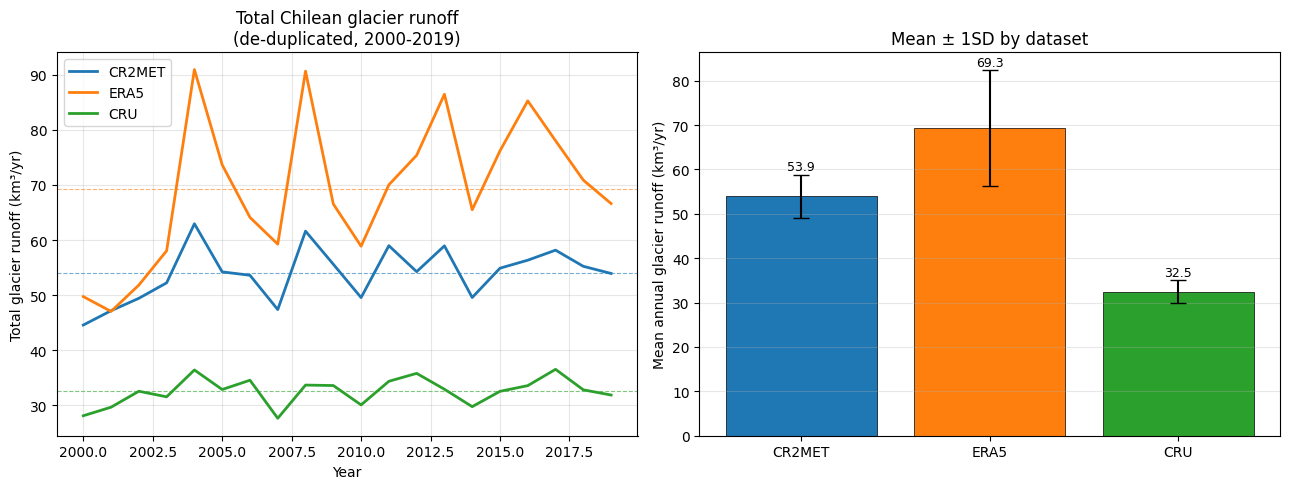

In [33]:
# ── Cell 22: Figure 1 — National melt totals ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for ds_name in DATASETS:
    km3 = NATIONAL_TOTALS[ds_name] / 1e9
    ax.plot(YEARS, km3, color=DS_COLORS[ds_name], lw=2, label=ds_name)
    ax.axhline(km3.mean(), color=DS_COLORS[ds_name],
               lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Year')
ax.set_ylabel('Total glacier runoff (km³/yr)')
ax.set_title('Total Chilean glacier runoff\n(de-duplicated, 2000-2019)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
means = {ds: (NATIONAL_TOTALS[ds]/1e9).mean() for ds in DATASETS}
stds  = {ds: (NATIONAL_TOTALS[ds]/1e9).std()  for ds in DATASETS}
bars  = ax.bar(list(means.keys()), list(means.values()),
               color=[DS_COLORS[d] for d in means],
               yerr=list(stds.values()), capsize=6,
               edgecolor='k', lw=0.5)
for bar, (ds, val) in zip(bars, means.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + stds[ds] + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean annual glacier runoff (km³/yr)')
ax.set_title('Mean ± 1SD by dataset')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1_national_melt_totals.png', dpi=150)
plt.show()

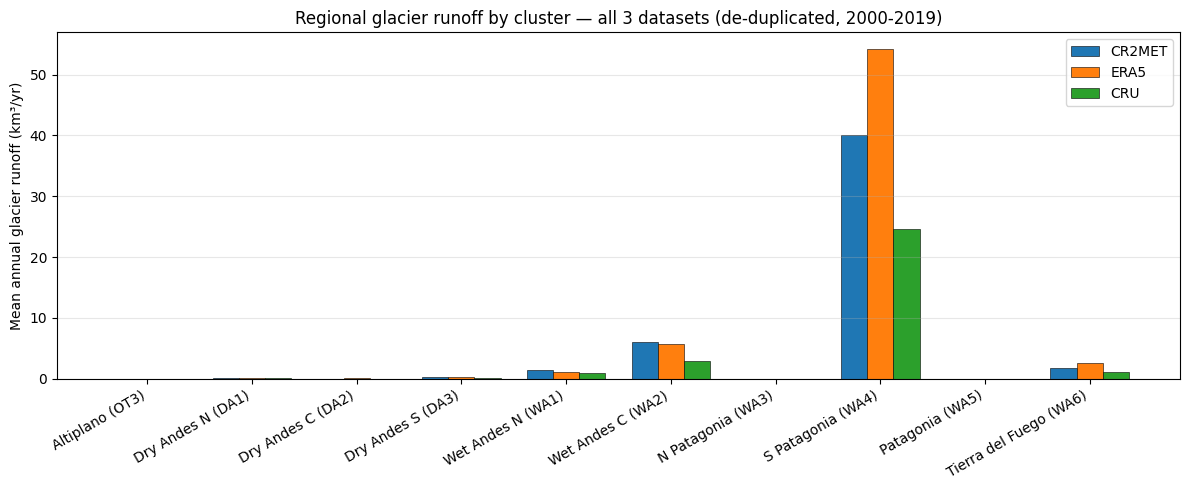

In [34]:
# ── Cell 23: Figure 2 — Regional melt by cluster ──────────────────────────

cluster_melt = {}
for ds_name in DATASETS:
    cluster_totals = {cl: 0.0 for cl in CLUSTERS}
    for gauge_id, info in GAUGE_INFO_DEDUP.items():
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        total = res['monthly']['glacier_runoff_m3'].sum() / 1e9 / 20
        pc    = info['primary_cluster']
        if pc in cluster_totals:
            cluster_totals[pc] += total
    cluster_melt[ds_name] = cluster_totals

fig, ax = plt.subplots(figsize=(12, 5))
x, width = np.arange(len(CLUSTERS)), 0.25
for i, ds_name in enumerate(DATASETS):
    vals = [cluster_melt[ds_name].get(cl, 0) for cl in CLUSTERS]
    ax.bar(x + i*width, vals, width, label=ds_name,
           color=DS_COLORS[ds_name], edgecolor='k', lw=0.4)
ax.set_xticks(x + width)
ax.set_xticklabels([REGION_LABELS[c] for c in CLUSTERS],
                   rotation=30, ha='right')
ax.set_ylabel('Mean annual glacier runoff (km³/yr)')
ax.set_title('Regional glacier runoff by cluster — all 3 datasets '
             '(de-duplicated, 2000-2019)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2_regional_melt_by_cluster.png', dpi=150)
plt.show()

Computing fractions...
Done
Colour scale: 0 – 67.8%
Pre-joining bounds...
Pre-joined: 137 basins, 6 panels


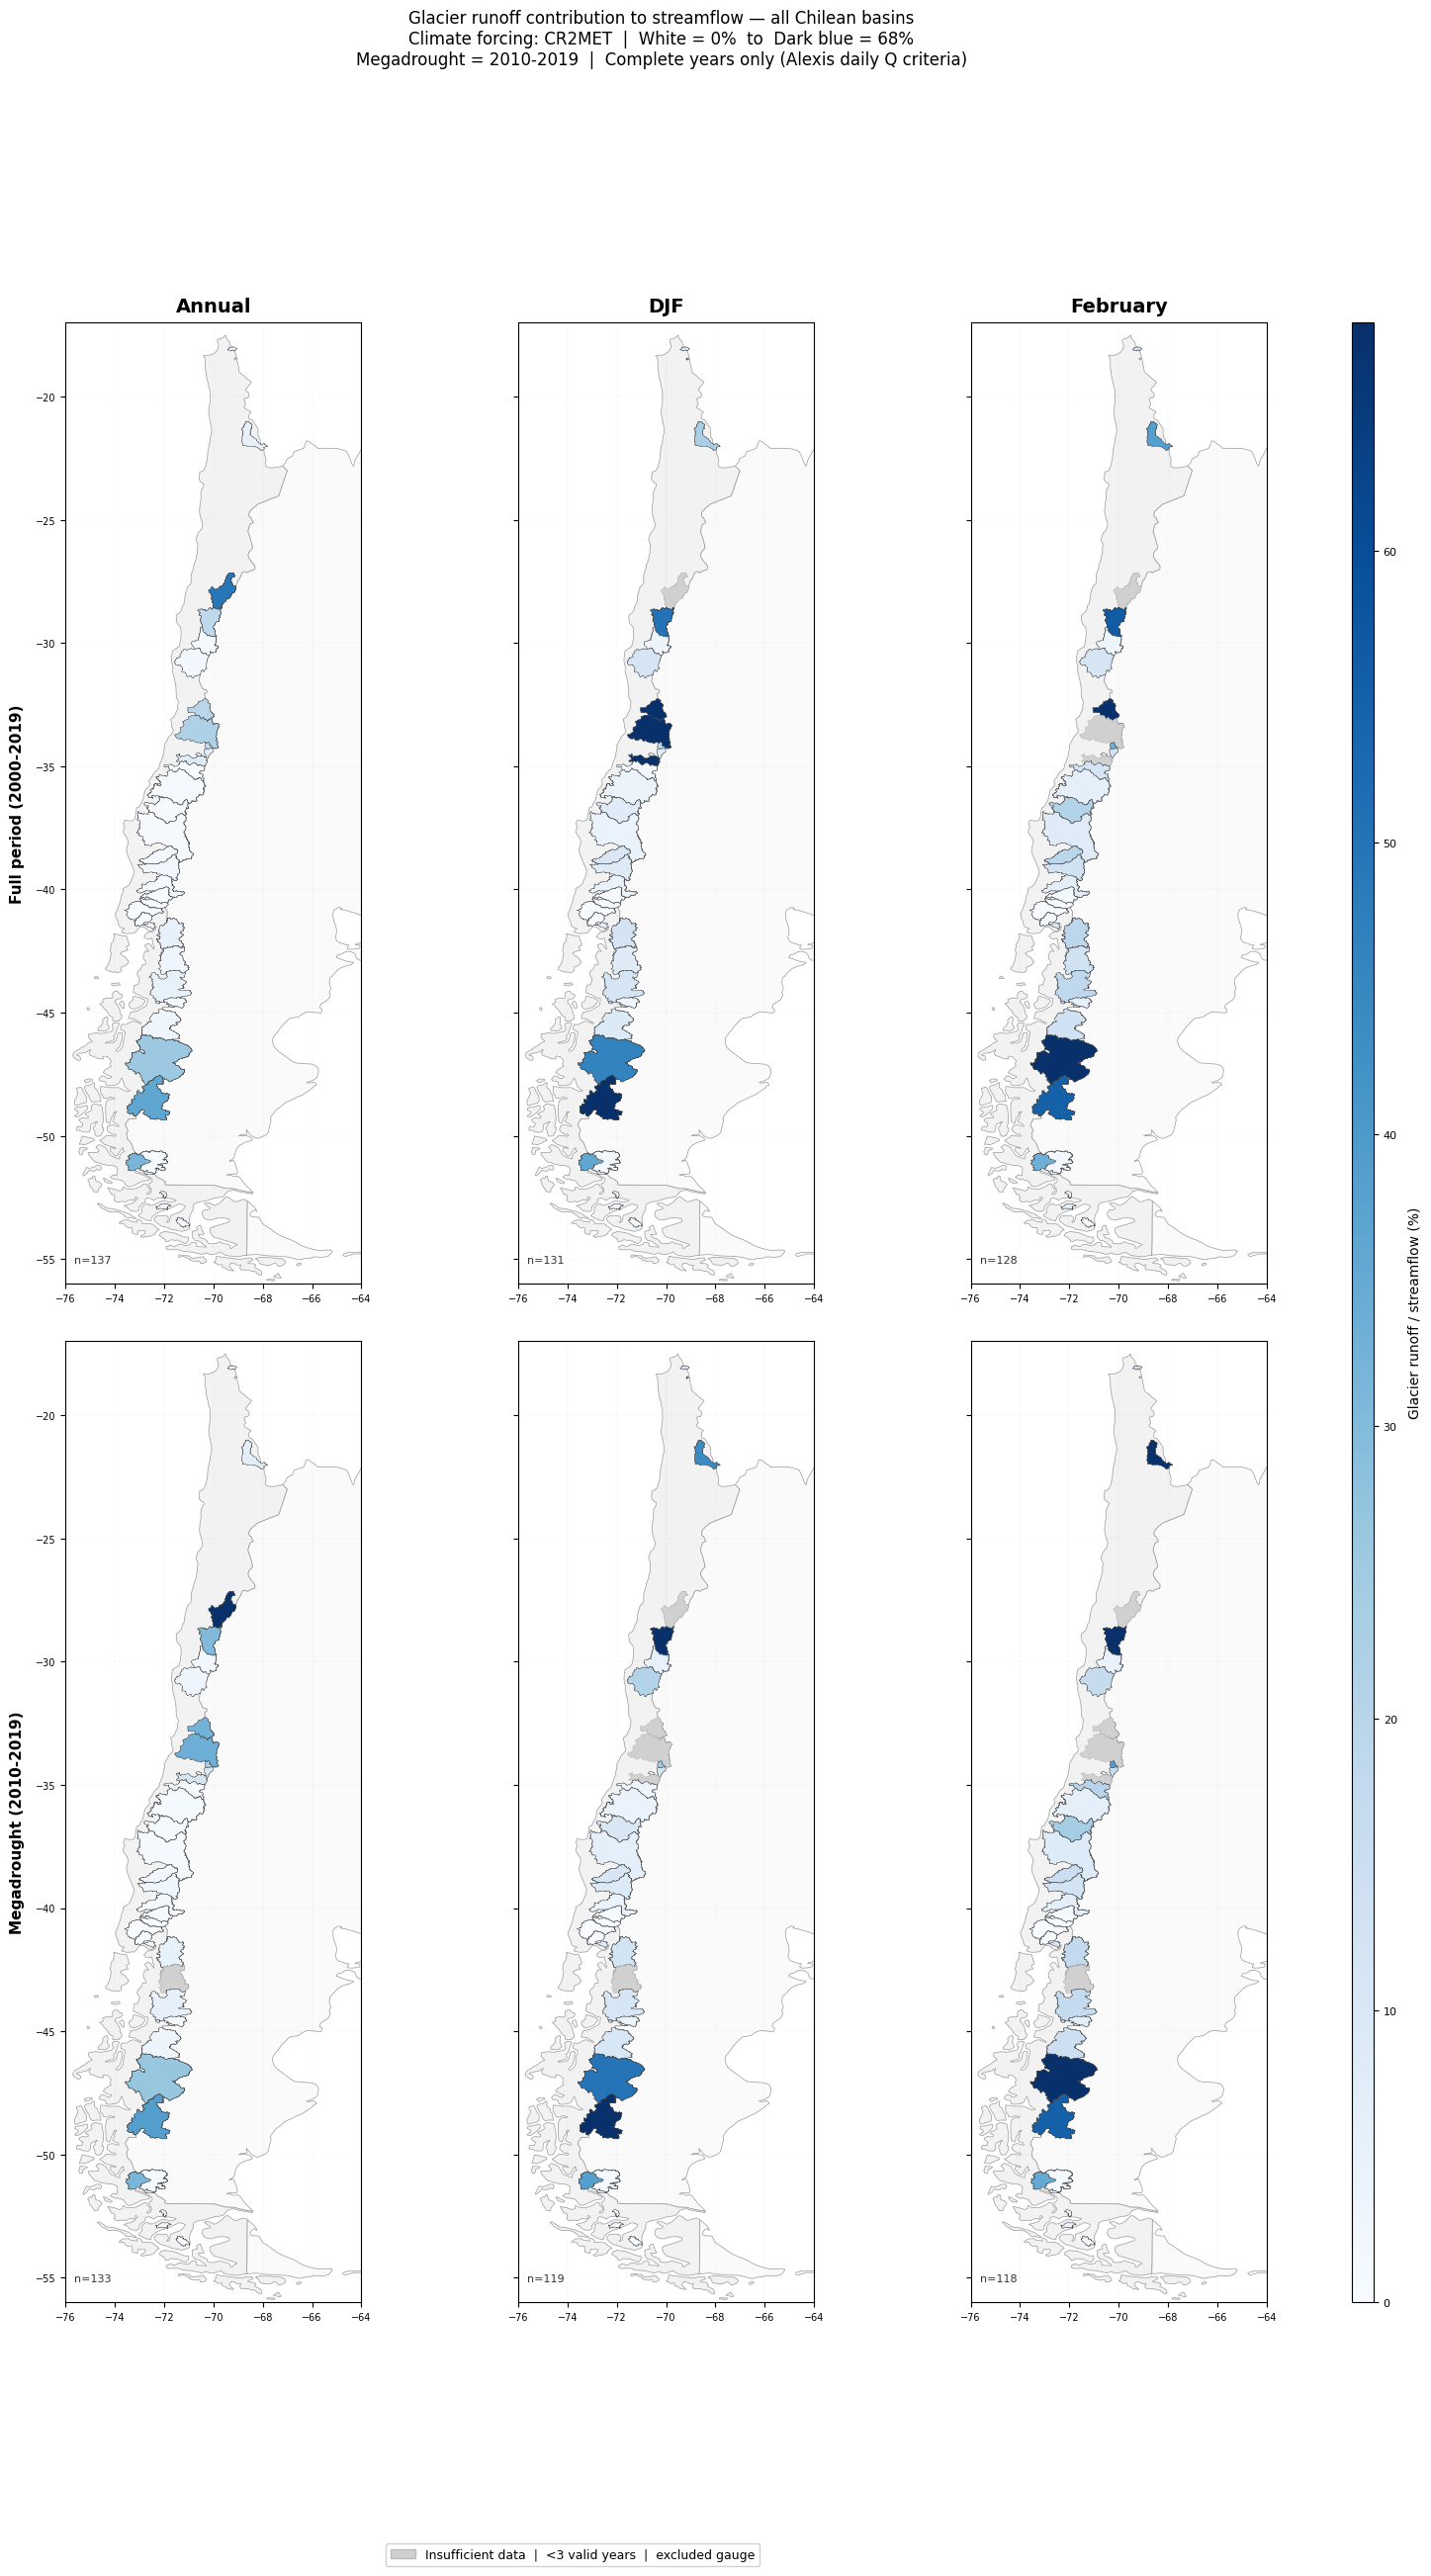

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/map_glacier_fraction_chile_CR2MET.png


In [35]:
# ── Cell 24: Figure — Glacier fraction maps, all Chile ────────────────────
#
# 2 rows x 3 cols: Full period | Megadrought  x  Annual | DJF | February
# Vectorised plotting — pre-joins bounds to fracs once for speed

DS_MAP = 'CR2MET'

PERIOD_DEFS = {
    'Full period (2000-2019)': YEARS,
    'Megadrought (2010-2019)': MEGADROUGHT_YEARS,
}
SEASON_DEFS = {
    'Annual':   list(range(1, 13)),
    'DJF':      [12, 1, 2],
    'February': [2],
}

def basin_mean_frac(gauge_id, years, months):
    res = RESULTS[DS_MAP].get(gauge_id)
    if res is None:
        return np.nan
    m            = res['monthly']
    complete_yrs = res.get('complete_years',
                           GAUGE_INFO_FRAC.get(gauge_id, {})
                           .get('complete_years', YEARS))
    valid_years  = [y for y in years if y in complete_yrs]
    if len(valid_years) < 3:
        return np.nan
    m   = m[m['year'].isin(valid_years) & m['month'].isin(months)].copy()
    ann = m.groupby('year').agg(
        glac=('glacier_runoff_m3', 'sum'),
        q   =('q_m3_mon',          'sum')
    )
    ann = ann[ann['q'] > 0]
    if len(ann) < 3:
        return np.nan
    frac = (ann['glac'] / ann['q']).mean() * 100
    return frac if frac <= 100 else np.nan

print('Computing fractions...')
frac_maps = {}
for period_label, p_years in PERIOD_DEFS.items():
    for season_label, months in SEASON_DEFS.items():
        frac_maps[(period_label, season_label)] = {
            gid: basin_mean_frac(gid, p_years, months)
            for gid in GAUGE_INFO_FRAC
        }
print('Done')

all_fracs = [v for d in frac_maps.values()
             for v in d.values() if not np.isnan(v)]
vmax = np.nanpercentile(all_fracs, 95)
print(f'Colour scale: 0 – {vmax:.1f}%')

cmap_map  = plt.cm.Blues
norm      = Normalize(vmin=0, vmax=vmax)
GREY      = '#d0d0d0'
GREY_EDGE = '#bbbbbb'
BLUE_EDGE = '#444444'

print('Pre-joining bounds...')
bounds_valid = bounds[bounds['gauge_id'].isin(GAUGE_INFO_FRAC)].copy()
for (period_label, season_label), fracs in frac_maps.items():
    col = f'{period_label}|{season_label}'
    bounds_valid[col] = bounds_valid['gauge_id'].map(fracs)
print(f'Pre-joined: {len(bounds_valid)} basins, {len(frac_maps)} panels')

try:
    world       = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    chile       = world[world['NAME'] == 'Chile']
    arg         = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception:
    has_borders = False
    print('Country borders unavailable')

period_labels = list(PERIOD_DEFS.keys())
season_labels = list(SEASON_DEFS.keys())

fig = plt.figure(figsize=(18, 26))
gs  = gridspec.GridSpec(2, 4, width_ratios=[1,1,1,0.05],
                        wspace=0.04, hspace=0.06)

for r_idx, period_label in enumerate(period_labels):
    for c_idx, season_label in enumerate(season_labels):
        ax  = fig.add_subplot(gs[r_idx, c_idx])
        col = f'{period_label}|{season_label}'

        if has_borders:
            chile.plot(ax=ax, facecolor='#f2f2f2',
                       edgecolor='#999999', linewidth=0.5, zorder=0)
            arg.plot(ax=ax, facecolor='#fafafa',
                     edgecolor='#999999', linewidth=0.5, zorder=0)

        frac_vals   = bounds_valid[col].values
        face_colors = [to_hex(cmap_map(norm(v))) if not np.isnan(v) else GREY
                       for v in frac_vals]
        edge_colors = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE
                       for v in frac_vals]
        bounds_valid.plot(ax=ax, color=face_colors, edgecolor=edge_colors,
                          linewidth=0.25, zorder=2)

        ax.set_xlim(-76, -64)
        ax.set_ylim(-56, -17)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.15, lw=0.3)

        if r_idx == 0:
            ax.set_title(season_label, fontsize=14,
                         fontweight='bold', pad=8)
        if c_idx == 0:
            ax.set_ylabel(period_label, fontsize=11,
                          labelpad=8, fontweight='bold')
        else:
            ax.set_yticklabels([])

        n_valid = int(np.sum(~np.isnan(frac_vals)))
        ax.text(0.03, 0.02, f'n={n_valid}',
                transform=ax.transAxes, fontsize=8,
                color='#333333', va='bottom')

cbar_ax = fig.add_subplot(gs[:, 3])
sm = ScalarMappable(cmap=cmap_map, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Glacier runoff / streamflow (%)', fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[Patch(facecolor=GREY, edgecolor=GREY_EDGE,
                   label='Insufficient data  |  <3 valid years  |  excluded gauge')],
    loc='lower center', fontsize=9,
    bbox_to_anchor=(0.45, 0.005), framealpha=0.9
)
fig.suptitle(
    f'Glacier runoff contribution to streamflow — all Chilean basins\n'
    f'Climate forcing: {DS_MAP}  |  White = 0%  to  Dark blue = {vmax:.0f}%\n'
    f'Megadrought = 2010-2019  |  Complete years only (Alexis daily Q criteria)',
    fontsize=12, y=1.002
)
fname = f'{OUT_DIR}/map_glacier_fraction_chile_{DS_MAP}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

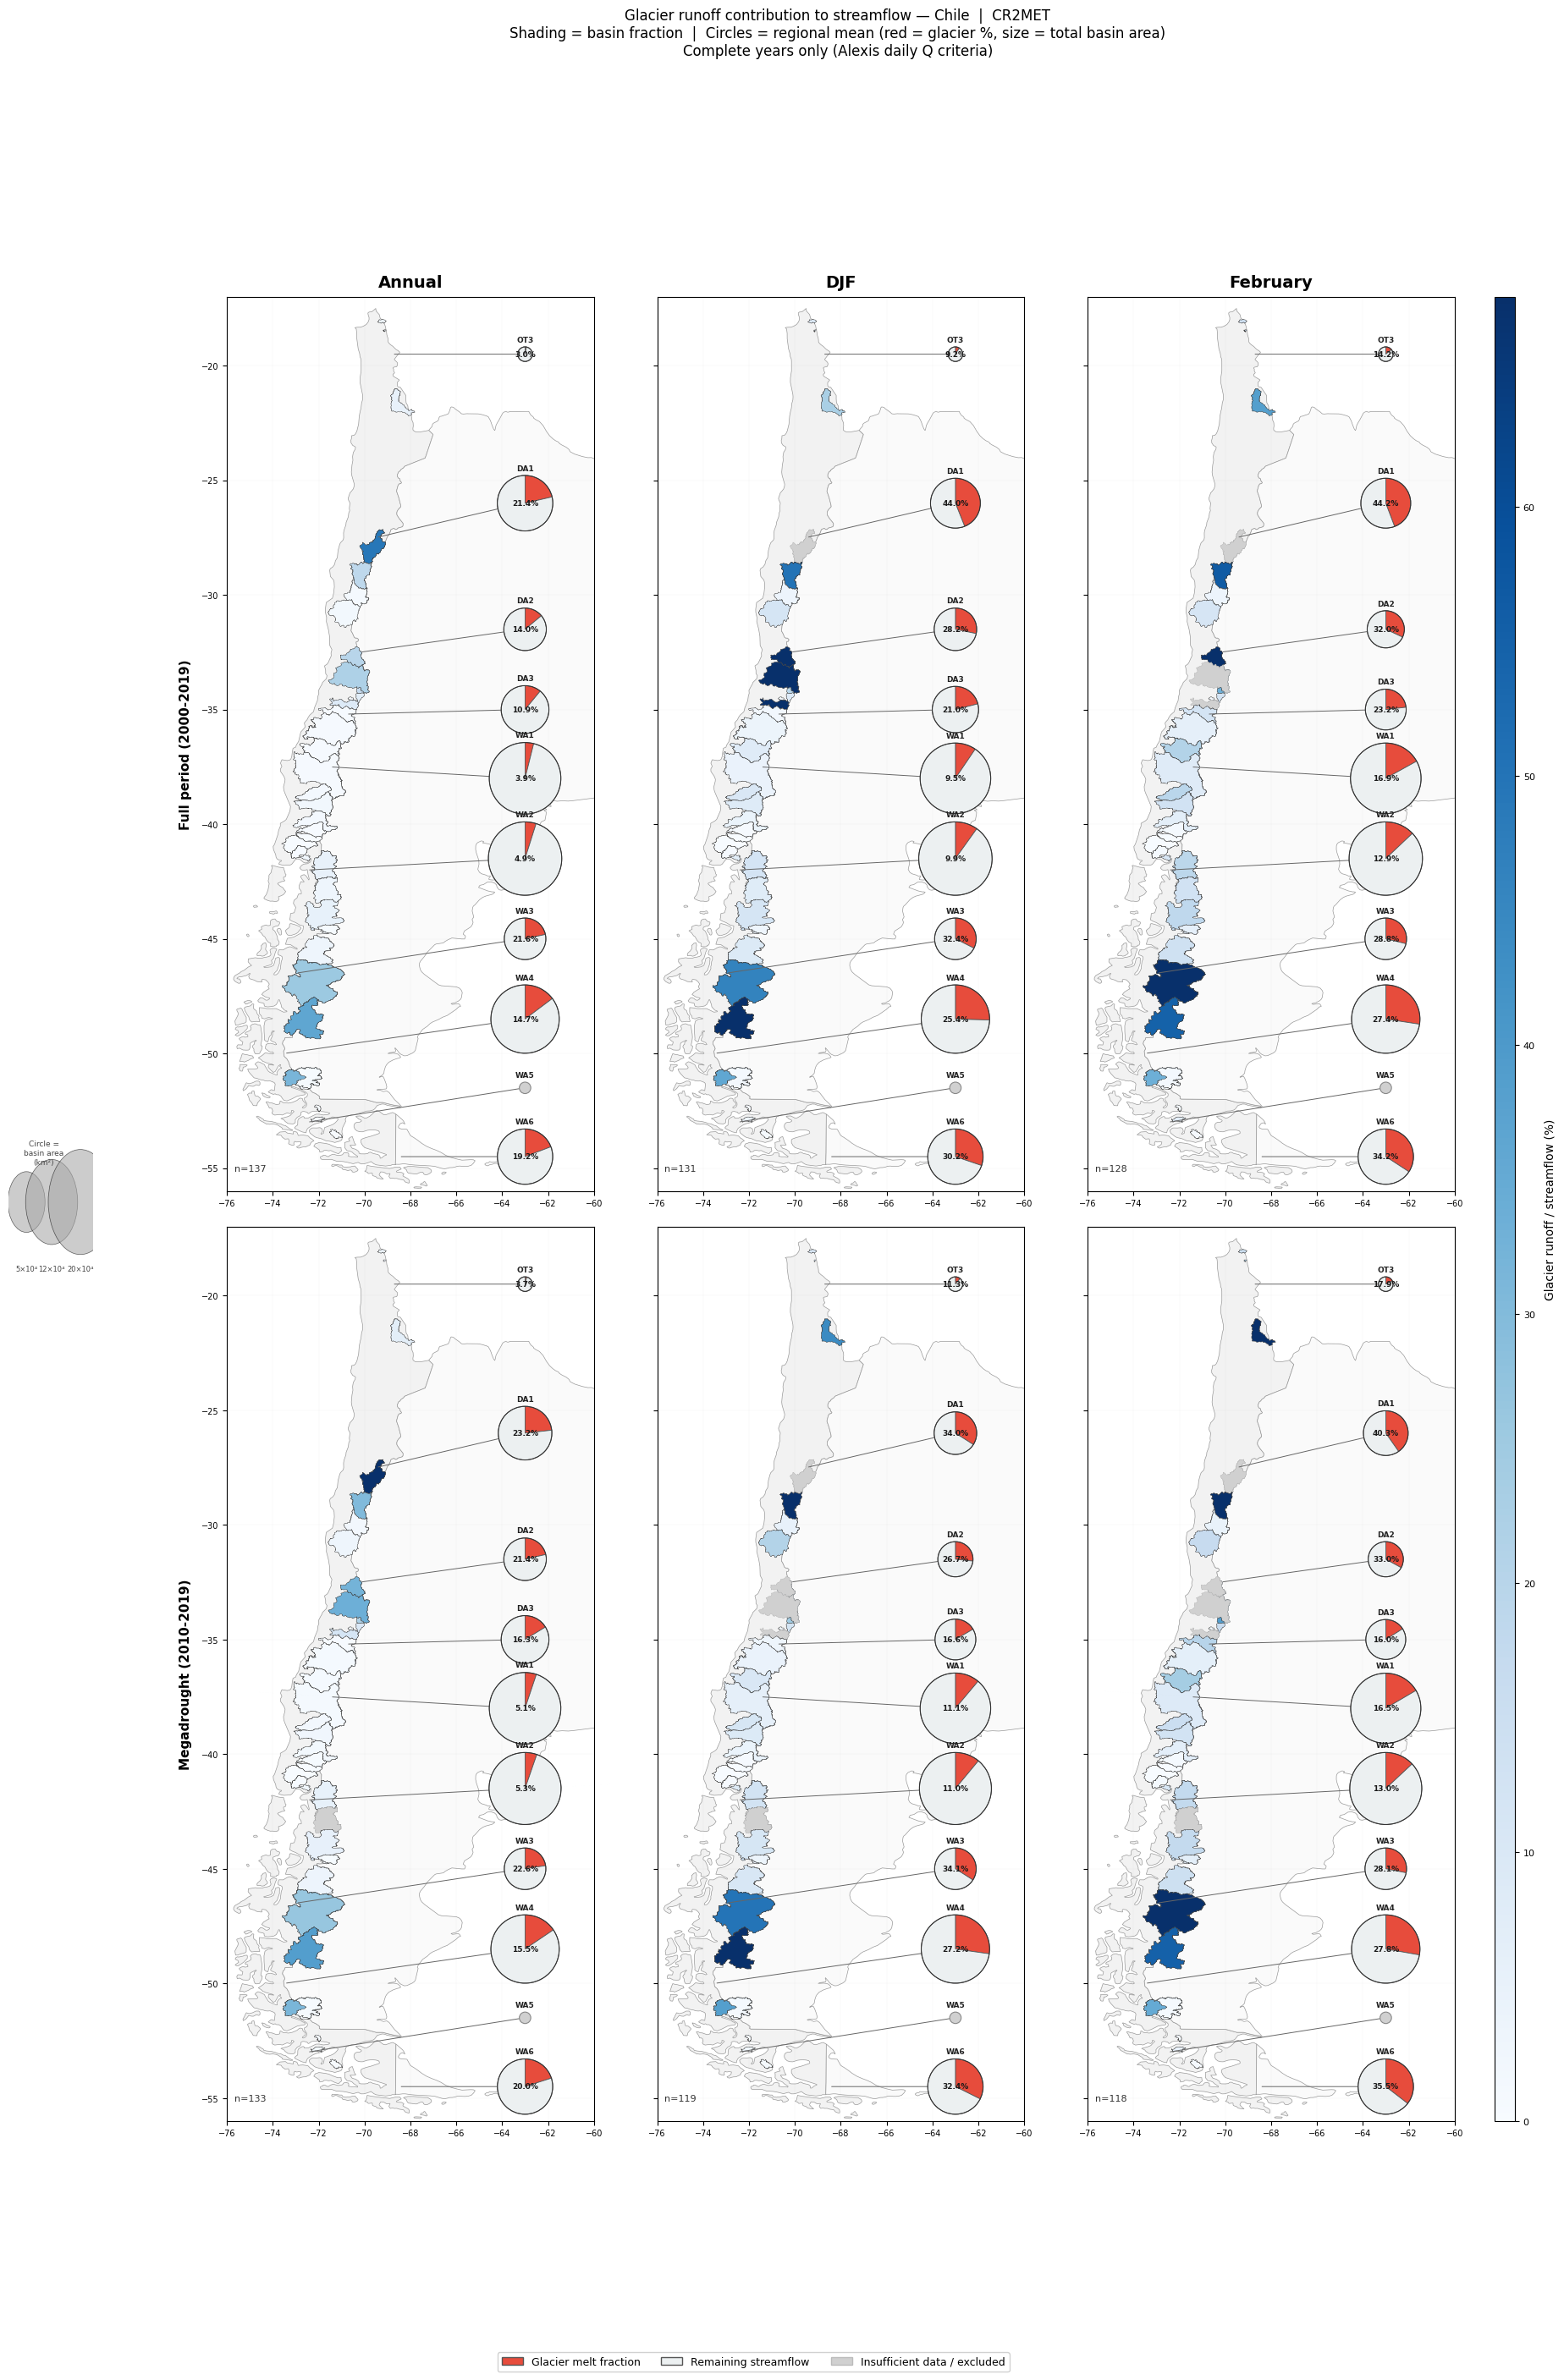

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/map_glacier_fraction_piecharts_CR2MET.png


In [36]:
# ── Cell 25: Figure — Glacier fraction maps with regional pie pullouts ─────
#
# Same layout as Cell 24 — reuses frac_maps, vmax, bounds_valid,
# cmap_map, norm, GREY, GREY_EDGE, BLUE_EDGE, has_borders, chile, arg,
# PERIOD_DEFS, SEASON_DEFS, period_labels, season_labels from Cell 24.

REGION_ANCHORS = {
    'OT3': (-68.8, -19.5), 'DA1': (-69.5, -27.5),
    'DA2': (-70.2, -32.5), 'DA3': (-70.8, -35.2),
    'WA1': (-71.5, -37.5), 'WA2': (-72.5, -42.0),
    'WA3': (-73.0, -46.5), 'WA4': (-73.5, -50.0),
    'WA5': (-72.5, -53.0), 'WA6': (-68.5, -54.5),
}
PULLOUT_POS = {
    'OT3': (-63.0, -19.5), 'DA1': (-63.0, -26.0),
    'DA2': (-63.0, -31.5), 'DA3': (-63.0, -35.0),
    'WA1': (-63.0, -38.0), 'WA2': (-63.0, -41.5),
    'WA3': (-63.0, -45.0), 'WA4': (-63.0, -48.5),
    'WA5': (-63.0, -51.5), 'WA6': (-63.0, -54.5),
}

def regional_frac(cluster, years, months):
    fracs, b_areas, g_areas = [], [], []
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        if cluster not in info['clusters']:
            continue
        frac = basin_mean_frac(gauge_id, years, months)
        if np.isnan(frac):
            continue
        fracs.append(frac)
        b_areas.append(info['basin_area_km2'])
        g_areas.append(info['glacier_area_km2'])
    if not fracs:
        return np.nan, 0, 0
    return np.nanmean(fracs), sum(b_areas), sum(g_areas)

cluster_basin_areas = {
    cl: sum(info['basin_area_km2'] for gid, info in GAUGE_INFO_FRAC.items()
            if cl in info['clusters'])
    for cl in CLUSTERS
}
area_max = max(cluster_basin_areas.values())
CIRC_MAX, CIRC_MIN = 1.6, 0.25

def area_to_radius(area):
    if area <= 0:
        return CIRC_MIN
    return CIRC_MIN + (area / area_max) ** 0.5 * (CIRC_MAX - CIRC_MIN)

fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(2, 4, width_ratios=[1,1,1,0.05],
                        wspace=0.05, hspace=0.04)

for r_idx, period_label in enumerate(period_labels):
    years = PERIOD_DEFS[period_label]
    for c_idx, season_label in enumerate(season_labels):
        months = SEASON_DEFS[season_label]
        ax     = fig.add_subplot(gs[r_idx, c_idx])
        col    = f'{period_label}|{season_label}'

        if has_borders:
            chile.plot(ax=ax, facecolor='#f2f2f2',
                       edgecolor='#999999', linewidth=0.5, zorder=0)
            arg.plot(ax=ax, facecolor='#fafafa',
                     edgecolor='#999999', linewidth=0.5, zorder=0)

        frac_vals   = bounds_valid[col].values
        face_colors = [to_hex(cmap_map(norm(v))) if not np.isnan(v) else GREY
                       for v in frac_vals]
        edge_colors = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE
                       for v in frac_vals]
        bounds_valid.plot(ax=ax, color=face_colors, edgecolor=edge_colors,
                          linewidth=0.25, zorder=2)

        for cl in CLUSTERS:
            mean_frac, tot_basin_area, _ = regional_frac(cl, years, months)
            anchor  = REGION_ANCHORS[cl]
            pullout = PULLOUT_POS[cl]
            radius  = area_to_radius(tot_basin_area)

            if np.isnan(mean_frac) or mean_frac == 0:
                ax.add_patch(plt.Circle(pullout, radius,
                    facecolor=GREY, edgecolor='#888888',
                    linewidth=0.8, zorder=6, transform=ax.transData))
            else:
                frac_clipped = min(mean_frac / 100, 1.0)
                theta1 = 90
                for size, fc in [(frac_clipped, '#e74c3c'),
                                  (1 - frac_clipped, '#ecf0f1')]:
                    theta2 = theta1 - size * 360
                    ax.add_patch(Wedge(pullout, radius,
                        min(theta1, theta2), max(theta1, theta2),
                        facecolor=fc, edgecolor='#555555',
                        linewidth=0.6, zorder=6, transform=ax.transData))
                    theta1 = theta2
                ax.add_patch(plt.Circle(pullout, radius,
                    facecolor='none', edgecolor='#333333',
                    linewidth=0.8, zorder=7, transform=ax.transData))
                ax.text(pullout[0], pullout[1], f'{mean_frac:.1f}%',
                        ha='center', va='center', fontsize=6.5,
                        fontweight='bold', color='#1a1a1a', zorder=8)

            ax.text(pullout[0], pullout[1] + radius + 0.15, cl,
                    ha='center', va='bottom', fontsize=6.5,
                    fontweight='bold', color='#222222', zorder=8)
            ax.annotate('', xy=anchor,
                        xytext=(pullout[0] - radius * 0.1, pullout[1]),
                        arrowprops=dict(arrowstyle='-', color='#666666',
                                        lw=0.7, connectionstyle='arc3,rad=0.0'),
                        zorder=5)

        ax.set_xlim(-76, -60)
        ax.set_ylim(-56, -17)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.15, lw=0.3)

        if r_idx == 0:
            ax.set_title(season_label, fontsize=14,
                         fontweight='bold', pad=8)
        if c_idx == 0:
            ax.set_ylabel(period_label, fontsize=11,
                          labelpad=8, fontweight='bold')
        else:
            ax.set_yticklabels([])

        n_valid = int(np.sum(~np.isnan(frac_vals)))
        ax.text(0.02, 0.02, f'n={n_valid}', transform=ax.transAxes,
                fontsize=8, color='#333333', va='bottom')

cbar_ax = fig.add_subplot(gs[:, 3])
sm = ScalarMappable(cmap=cmap_map, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Glacier runoff / streamflow (%)', fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', edgecolor='#555555',
              label='Glacier melt fraction'),
        Patch(facecolor='#ecf0f1', edgecolor='#555555',
              label='Remaining streamflow'),
        Patch(facecolor=GREY, edgecolor=GREY_EDGE,
              label='Insufficient data / excluded'),
    ],
    loc='lower center', ncol=3, fontsize=9,
    bbox_to_anchor=(0.45, 0.002), framealpha=0.9
)

size_ax = fig.add_axes([0.01, 0.46, 0.05, 0.07])
size_ax.set_axis_off()
for pct, label in [(0.25, f'{area_max*0.25/1e4:.0f}×10⁴'),
                    (0.6,  f'{area_max*0.6/1e4:.0f}×10⁴'),
                    (1.0,  f'{area_max/1e4:.0f}×10⁴')]:
    size_ax.add_patch(plt.Circle((pct * 0.85, 0.55),
        area_to_radius(pct * area_max) / CIRC_MAX * 0.38,
        facecolor='#aaaaaa', edgecolor='k', lw=0.5, alpha=0.6))
    size_ax.text(pct * 0.85, 0.05, label,
                 ha='center', fontsize=6, color='#444444')
size_ax.text(0.42, 1.0, 'Circle =\nbasin area\n(km²)',
             ha='center', va='top', fontsize=6.5,
             color='#444444', linespacing=1.3)
size_ax.set_xlim(0, 1)
size_ax.set_ylim(-0.1, 1.1)

fig.suptitle(
    f'Glacier runoff contribution to streamflow — Chile  |  {DS_MAP}\n'
    f'Shading = basin fraction  |  '
    f'Circles = regional mean (red = glacier %, size = total basin area)\n'
    f'Complete years only (Alexis daily Q criteria)',
    fontsize=12, y=1.002
)
fname = f'{OUT_DIR}/map_glacier_fraction_piecharts_{DS_MAP}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

WA1 gauges: 50
  7123001  Rio Mataquito En Licanten                 lat=-35.26
  7115001  Rio Palos En Junta Con Colorado           lat=-35.54
  7306001  Rio Cipreses En Dasague Laguna La Invern  lat=-35.58
  7320003  Rio Claro En San Carlos                   lat=-35.62
  7355002  Rio Ancoa En El Morro                     lat=-35.96
  7321002  Rio Maule En Armerillo                    lat=-35.97
  7322001  Rio Maule En Longitudinal                 lat=-35.97
  7383001  Rio Maule En Forel                        lat=-36.01
  7354002  Rio Achibueno En La Recova                lat=-36.06
  7317005  Rio Melado En El Salto                    lat=-36.08
  7359001  Rio Loncomilla En Las Brisas              lat=-36.11
  7350001  Rio Longavi En La Quiriquina              lat=-36.24
  7350003  Rio Longavi En El Castillo                lat=-36.24
  7357002  Rio Loncomilla En Bodega                  lat=-36.24
  8104001  Rio Sauces Antes Junta Con ÑUble          lat=-36.65
  8105001  Rio ÑUble En L

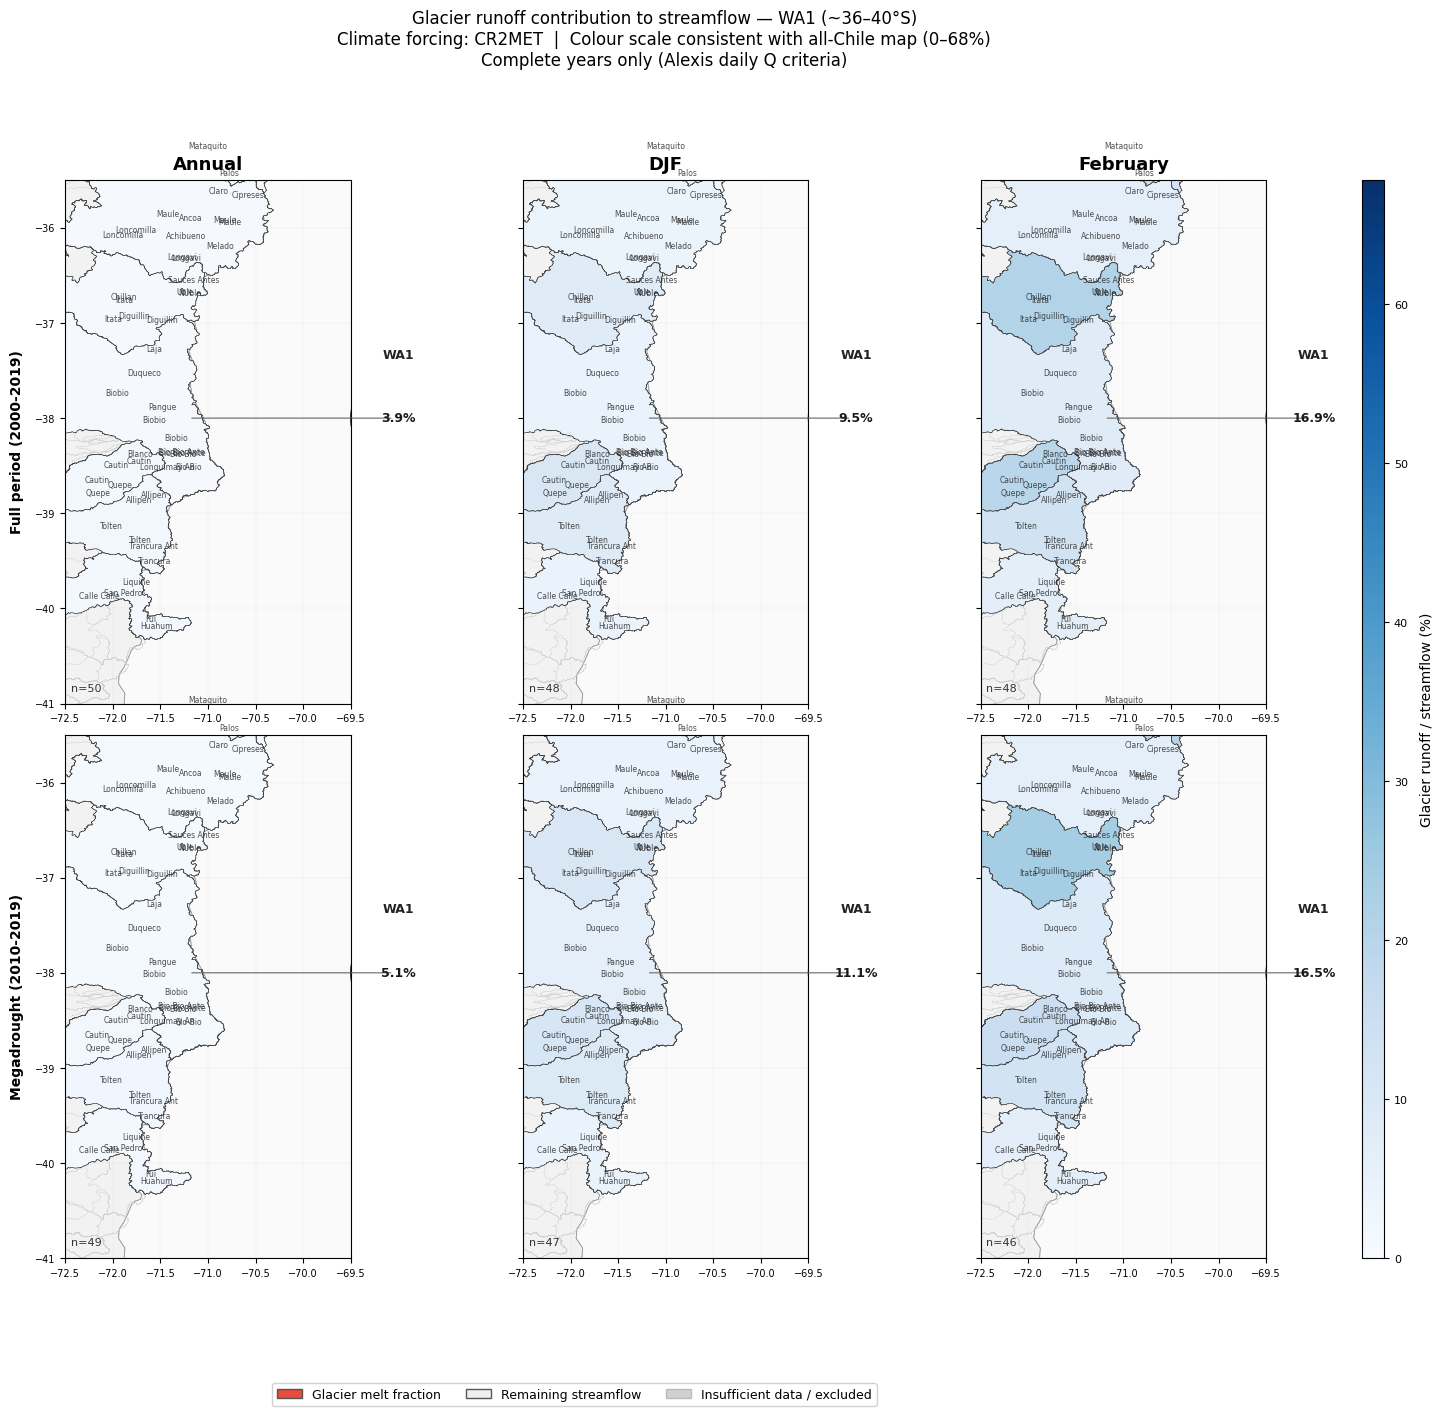

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/map_glacier_fraction_WA1_zoom_CR2MET.png


In [37]:
# ── Cell 26: Figure — WA1 zoom with pie pullout ───────────────────────────
#
# Reuses from Cell 24: vmax, cmap_map, norm, GREY, GREY_EDGE, BLUE_EDGE,
# has_borders, chile, arg, frac_maps, basin_mean_frac, regional_frac,
# PERIOD_DEFS, SEASON_DEFS, period_labels, season_labels

WA1_BOUNDS = {'minx': -72.5, 'maxx': -69.5, 'miny': -41.0, 'maxy': -35.5}

wa1_gauges = {
    gid: info for gid, info in GAUGE_INFO_FRAC.items()
    if 'WA1' in info['clusters']
}
print(f'WA1 gauges: {len(wa1_gauges)}')
for gid, info in sorted(wa1_gauges.items(),
                         key=lambda x: x[1]['cen_lat'], reverse=True):
    print(f'  {gid}  {info["gauge_name"][:40]:40s}  lat={info["cen_lat"]:.2f}')

bounds_wa1 = bounds[bounds['gauge_id'].isin(wa1_gauges)].copy()
for (period_label, season_label), fracs in frac_maps.items():
    col = f'{period_label}|{season_label}'
    bounds_wa1[col] = bounds_wa1['gauge_id'].map(fracs)

WA1_PULLOUT  = (-69.0, -38.0)
WA1_ANCHOR   = (-71.2, -38.0)
WA1_CIRC_R   = 0.5

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 4, width_ratios=[1,1,1,0.05],
                        wspace=0.06, hspace=0.06)

for r_idx, period_label in enumerate(period_labels):
    years = PERIOD_DEFS[period_label]
    for c_idx, season_label in enumerate(season_labels):
        months = SEASON_DEFS[season_label]
        ax     = fig.add_subplot(gs[r_idx, c_idx])
        col    = f'{period_label}|{season_label}'

        if has_borders:
            chile.plot(ax=ax, facecolor='#f2f2f2',
                       edgecolor='#999999', linewidth=0.6, zorder=0)
            arg.plot(ax=ax, facecolor='#fafafa',
                     edgecolor='#999999', linewidth=0.6, zorder=0)

        frac_vals   = bounds_wa1[col].values
        face_colors = [to_hex(cmap_map(norm(v))) if not np.isnan(v) else GREY
                       for v in frac_vals]
        edge_colors = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE
                       for v in frac_vals]
        bounds_wa1.plot(ax=ax, color=face_colors, edgecolor=edge_colors,
                        linewidth=0.4, zorder=2)

        bounds_bg = bounds.cx[
            WA1_BOUNDS['minx']:WA1_BOUNDS['maxx'],
            WA1_BOUNDS['miny']:WA1_BOUNDS['maxy']
        ]
        bounds_bg[~bounds_bg['gauge_id'].isin(wa1_gauges)].plot(
            ax=ax, facecolor='none', edgecolor='#cccccc',
            linewidth=0.2, zorder=1)

        mean_frac, _, _ = regional_frac('WA1', years, months)
        if not np.isnan(mean_frac) and mean_frac > 0:
            frac_clipped = min(mean_frac / 100, 1.0)
            theta1 = 90
            for size, fc in [(frac_clipped, '#e74c3c'),
                              (1 - frac_clipped, '#ecf0f1')]:
                theta2 = theta1 - size * 360
                ax.add_patch(Wedge(WA1_PULLOUT, WA1_CIRC_R,
                    min(theta1, theta2), max(theta1, theta2),
                    facecolor=fc, edgecolor='#555555',
                    linewidth=0.8, zorder=6, transform=ax.transData))
                theta1 = theta2
            ax.add_patch(plt.Circle(WA1_PULLOUT, WA1_CIRC_R,
                facecolor='none', edgecolor='#333333',
                linewidth=1.0, zorder=7, transform=ax.transData))
            ax.text(WA1_PULLOUT[0], WA1_PULLOUT[1], f'{mean_frac:.1f}%',
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='#1a1a1a', zorder=8)
        else:
            ax.add_patch(plt.Circle(WA1_PULLOUT, WA1_CIRC_R,
                facecolor=GREY, edgecolor='#888888',
                linewidth=0.8, zorder=6, transform=ax.transData))

        ax.text(WA1_PULLOUT[0], WA1_PULLOUT[1] + WA1_CIRC_R + 0.1,
                'WA1', ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='#222222', zorder=8)
        ax.annotate('', xy=WA1_ANCHOR,
                    xytext=(WA1_PULLOUT[0] - WA1_CIRC_R * 0.1, WA1_PULLOUT[1]),
                    arrowprops=dict(arrowstyle='-', color='#666666',
                                    lw=0.8, connectionstyle='arc3,rad=0.0'),
                    zorder=5)

        for gid, info in wa1_gauges.items():
            basin = bounds_wa1[bounds_wa1['gauge_id'] == gid]
            if len(basin) == 0:
                continue
            centroid = basin.geometry.centroid.iloc[0]
            ax.text(centroid.x, centroid.y,
                    info['gauge_name'].split(' En ')[0]
                    .replace('Rio ','').replace('Estero ','')[:12],
                    ha='center', va='center', fontsize=5.5,
                    color='#222222', zorder=9, alpha=0.8)

        ax.set_xlim(WA1_BOUNDS['minx'], WA1_BOUNDS['maxx'])
        ax.set_ylim(WA1_BOUNDS['miny'], WA1_BOUNDS['maxy'])
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2, lw=0.3)

        if r_idx == 0:
            ax.set_title(season_label, fontsize=13,
                         fontweight='bold', pad=8)
        if c_idx == 0:
            ax.set_ylabel(period_label, fontsize=10,
                          labelpad=8, fontweight='bold')
        else:
            ax.set_yticklabels([])

        n_valid = int(np.sum(~np.isnan(frac_vals)))
        ax.text(0.02, 0.02, f'n={n_valid}', transform=ax.transAxes,
                fontsize=8, color='#333333', va='bottom')

cbar_ax = fig.add_subplot(gs[:, 3])
sm = ScalarMappable(cmap=cmap_map, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Glacier runoff / streamflow (%)', fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', edgecolor='#555555',
              label='Glacier melt fraction'),
        Patch(facecolor='#ecf0f1', edgecolor='#555555',
              label='Remaining streamflow'),
        Patch(facecolor=GREY, edgecolor=GREY_EDGE,
              label='Insufficient data / excluded'),
    ],
    loc='lower center', ncol=3, fontsize=9,
    bbox_to_anchor=(0.45, 0.0), framealpha=0.9
)
fig.suptitle(
    f'Glacier runoff contribution to streamflow — WA1 (~36–40°S)\n'
    f'Climate forcing: {DS_MAP}  |  '
    f'Colour scale consistent with all-Chile map (0–{vmax:.0f}%)\n'
    f'Complete years only (Alexis daily Q criteria)',
    fontsize=12, y=1.002
)
fname = f'{OUT_DIR}/map_glacier_fraction_WA1_zoom_{DS_MAP}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

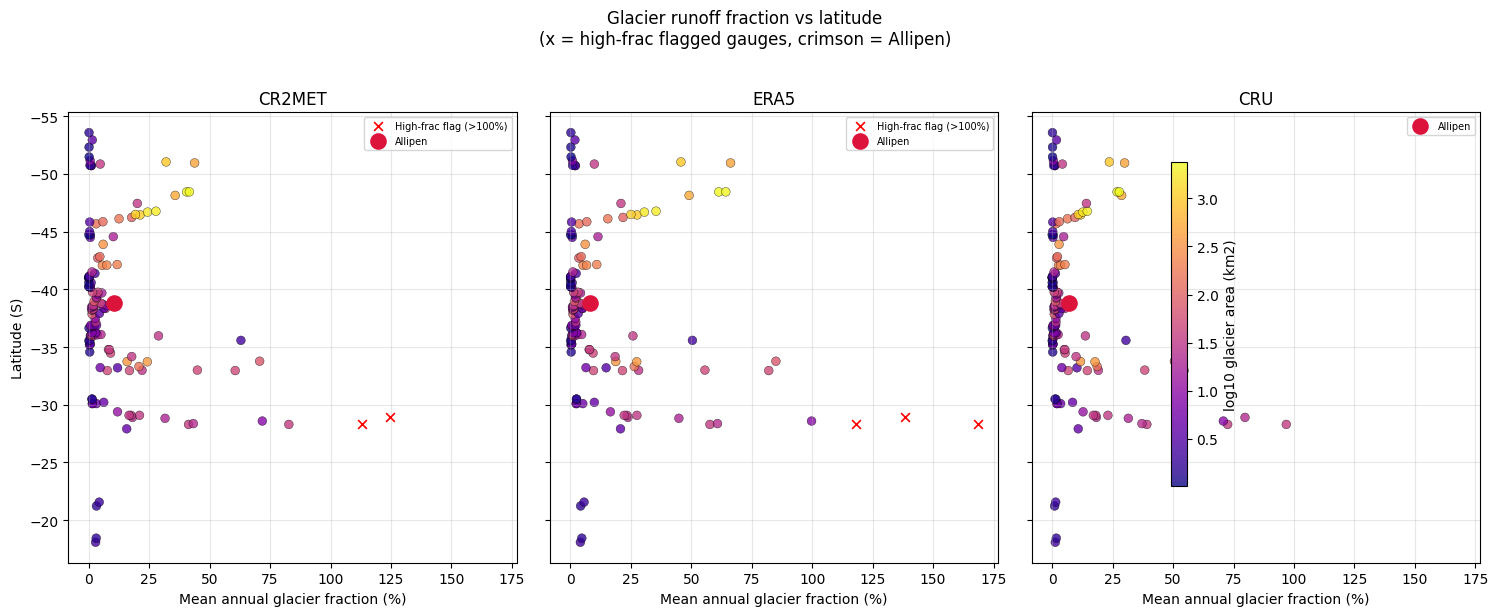

In [38]:
# ── Cell 27: Figure 3 — Latitudinal gradient ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True, sharex=True)

for ax, ds_name in zip(axes, DATASETS):
    df     = ANN_SUMMARIES[ds_name].dropna(subset=['mean_ann_frac'])
    df_ok  = df[~df['high_frac_flag']]
    df_hf  = df[df['high_frac_flag']]

    sc = ax.scatter(df_ok['mean_ann_frac'] * 100, df_ok['lat'],
                    c=np.log10(df_ok['glacier_area_km2'] + 1),
                    cmap='plasma', s=40, edgecolors='k', lw=0.3, alpha=0.8)
    if len(df_hf):
        ax.scatter(df_hf['mean_ann_frac'] * 100, df_hf['lat'],
                   marker='x', color='red', s=40, lw=1.2,
                   label='High-frac flag (>100%)', zorder=6)

    allipen = df[df['gauge_id'] == '9402001']
    if len(allipen):
        ax.scatter(allipen['mean_ann_frac']*100, allipen['lat'],
                   s=120, color='crimson', zorder=7, label='Allipen')

    ax.set_title(ds_name)
    ax.set_xlabel('Mean annual glacier fraction (%)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Latitude (S)')
fig.colorbar(sc, ax=axes, label='log10 glacier area (km2)', shrink=0.7)
fig.suptitle('Glacier runoff fraction vs latitude\n'
             '(x = high-frac flagged gauges, crimson = Allipen)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_latitudinal_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

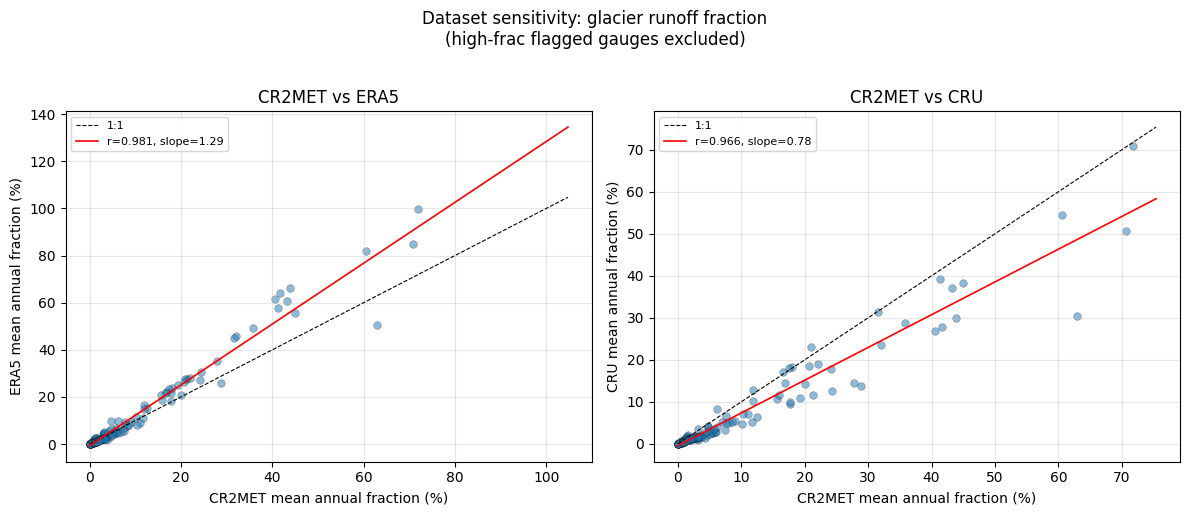

In [39]:
# ── Cell 28: Dataset comparison scatter ────────────────────────

combined_clean = combined[~combined['high_frac_flag']].copy()
frac_pivot = combined_clean.pivot_table(
    index='gauge_id', columns='dataset', values='mean_ann_frac').dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, alt_ds in zip(axes, ['ERA5','CRU']):
    x = frac_pivot['CR2MET'] * 100
    y = frac_pivot[alt_ds]   * 100
    ax.scatter(x, y, alpha=0.5, s=30, edgecolors='k', lw=0.3)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xfit = np.linspace(0, lim, 100)
    ax.plot(xfit, slope*xfit + intercept, 'r-', lw=1.2,
            label=f'r={r:.3f}, slope={slope:.2f}')
    ax.set_xlabel('CR2MET mean annual fraction (%)')
    ax.set_ylabel(f'{alt_ds} mean annual fraction (%)')
    ax.set_title(f'CR2MET vs {alt_ds}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Dataset sensitivity: glacier runoff fraction\n'
             '(high-frac flagged gauges excluded)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig4_dataset_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

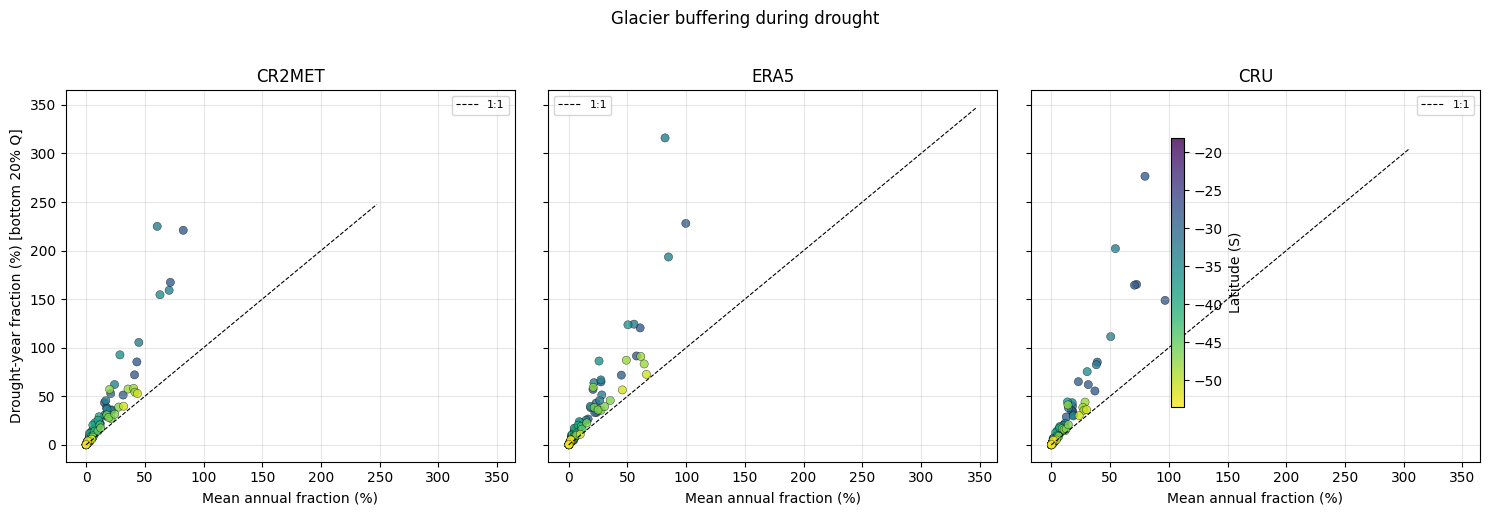

In [40]:
# ── Cell 29: Drought amplification ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, ds_name in zip(axes, DATASETS):
    df = ANN_SUMMARIES[ds_name].dropna(
        subset=['drought_ann_frac','mean_ann_frac']).copy()
    df = df[~df['high_frac_flag']]
    sc = ax.scatter(df['mean_ann_frac']*100, df['drought_ann_frac']*100,
                    c=df['lat'], cmap='viridis_r',
                    s=35, edgecolors='k', lw=0.3, alpha=0.8)
    lim = max(df['drought_ann_frac'].max(), df['mean_ann_frac'].max()) * 110
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    ax.set_title(ds_name)
    ax.set_xlabel('Mean annual fraction (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Drought-year fraction (%) [bottom 20% Q]')
fig.colorbar(sc, ax=axes, label='Latitude (S)', shrink=0.7)
fig.suptitle('Glacier buffering during drought', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5_drought_amplification.png', dpi=150, bbox_inches='tight')
plt.show()

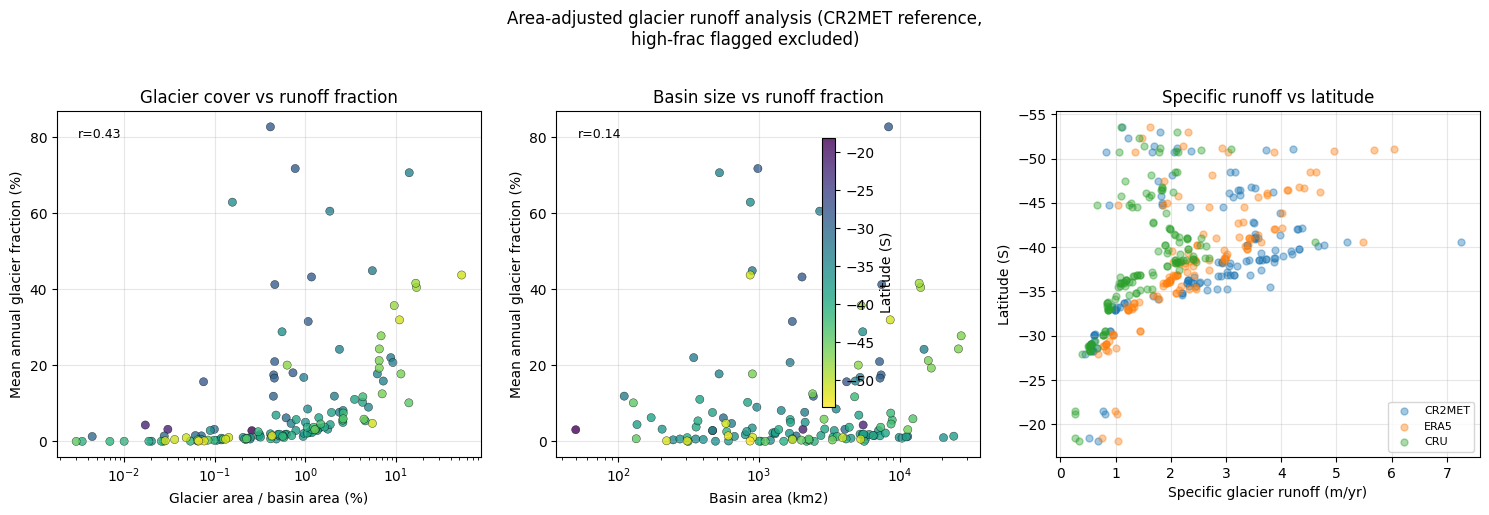

In [41]:
# ── Cell 30: Area-adjusted analysis ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_cr2 = ANN_SUMMARIES['CR2MET'].dropna(subset=['mean_ann_frac']).copy()
df_cr2 = df_cr2[~df_cr2['high_frac_flag']]
df_cr2['specific_runoff'] = (
    df_cr2['mean_ann_glac_km3'] * 1e9 / df_cr2['glacier_area_km2'] / 1e6)

ax = axes[0]
sc = ax.scatter(df_cr2['glacier_pct_basin'], df_cr2['mean_ann_frac']*100,
                c=df_cr2['lat'], cmap='viridis_r',
                s=35, edgecolors='k', lw=0.3, alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Glacier area / basin area (%)')
ax.set_ylabel('Mean annual glacier fraction (%)')
ax.set_title('Glacier cover vs runoff fraction')
r, _ = stats.pearsonr(np.log10(df_cr2['glacier_pct_basin'].clip(lower=0.001)),
                       df_cr2['mean_ann_frac'])
ax.text(0.05, 0.95, f'r={r:.2f}', transform=ax.transAxes, va='top', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(df_cr2['basin_area_km2'], df_cr2['mean_ann_frac']*100,
           c=df_cr2['lat'], cmap='viridis_r',
           s=35, edgecolors='k', lw=0.3, alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Basin area (km2)')
ax.set_ylabel('Mean annual glacier fraction (%)')
ax.set_title('Basin size vs runoff fraction')
r2, _ = stats.pearsonr(np.log10(df_cr2['basin_area_km2']), df_cr2['mean_ann_frac'])
ax.text(0.05, 0.95, f'r={r2:.2f}', transform=ax.transAxes, va='top', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
for ds_name in DATASETS:
    df_ds = ANN_SUMMARIES[ds_name].copy()
    df_ds = df_ds[~df_ds['high_frac_flag']]
    df_ds['specific_runoff'] = (
        df_ds['mean_ann_glac_km3'] * 1e9 / df_ds['glacier_area_km2'] / 1e6)
    ax.scatter(df_ds['specific_runoff'], df_ds['lat'],
               alpha=0.4, s=25, color=DS_COLORS[ds_name], label=ds_name)
ax.set_xlabel('Specific glacier runoff (m/yr)')
ax.set_ylabel('Latitude (S)')
ax.set_title('Specific runoff vs latitude')
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.colorbar(sc, ax=axes[:2], label='Latitude (S)', shrink=0.7)
fig.suptitle('Area-adjusted glacier runoff analysis (CR2MET reference,\nhigh-frac flagged excluded)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig6_area_adjusted_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

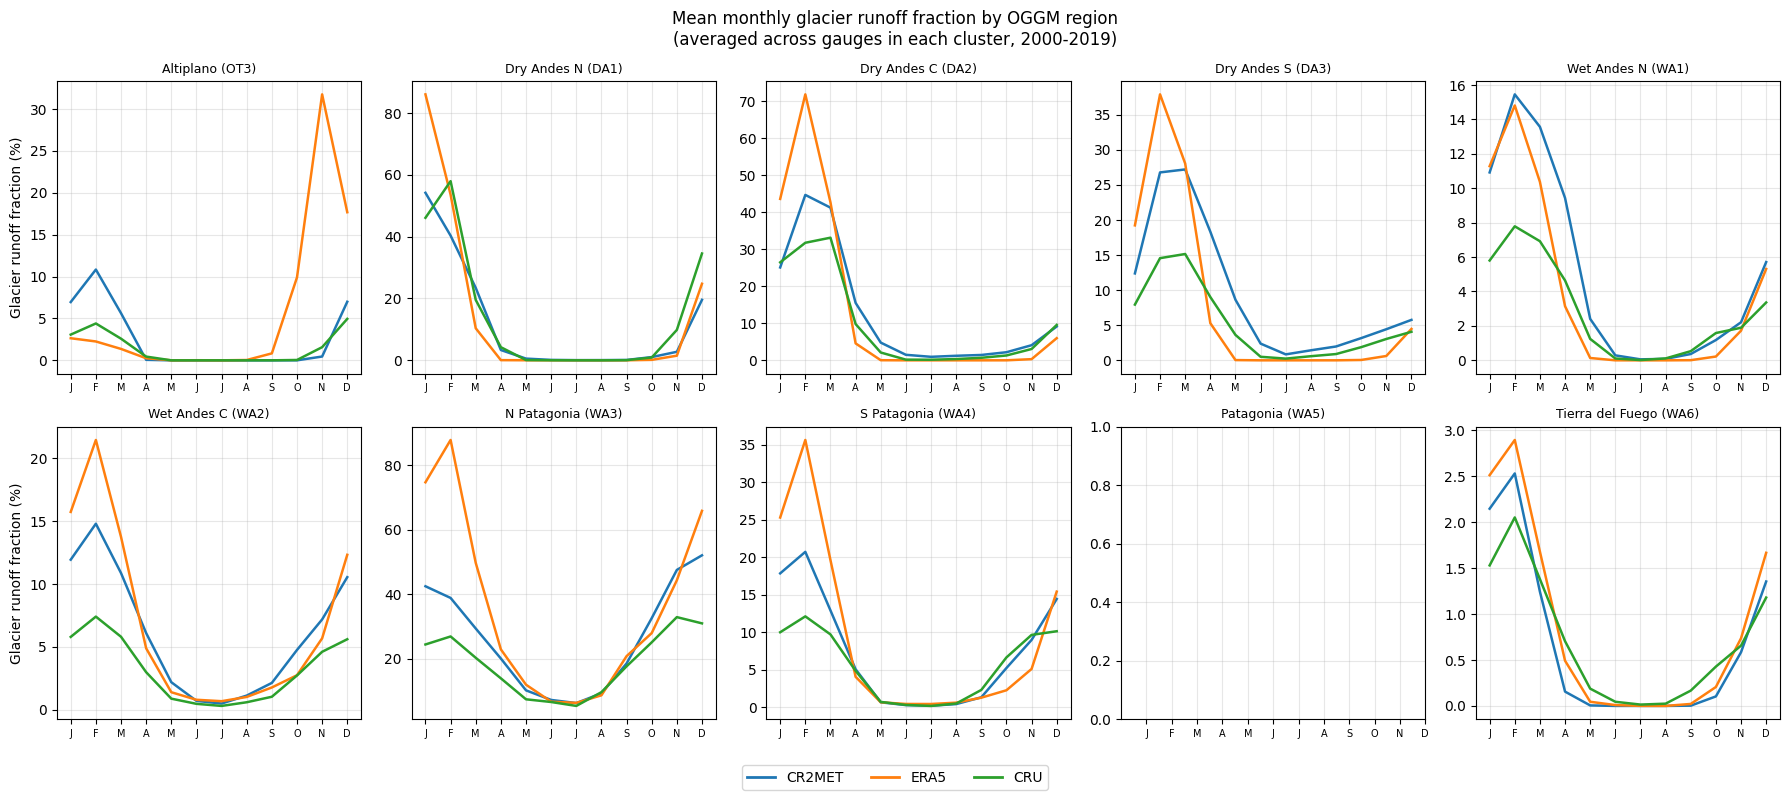

In [42]:
# ── Cell 31: Figure 7 — Monthly seasonality by region ─────────────────────

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
axes_flat = axes.flatten()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, cl in zip(axes_flat, CLUSTERS):
    for ds_name in DATASETS:
        df = ANN_SUMMARIES[ds_name]
        gauges_in_cl = df[
            (df['primary_cluster'] == cl) & (~df['high_frac_flag'])
        ]['gauge_id'].tolist()
        if not gauges_in_cl:
            continue
        mon_fracs = []
        for gid in gauges_in_cl:
            res = RESULTS[ds_name].get(gid)
            if res is None:
                continue
            m = res['monthly']
            mf = m.groupby('month').apply(
                lambda g: g['glacier_runoff_m3'].sum() / g['q_m3_mon'].sum()
                if g['q_m3_mon'].sum() > 0 else np.nan)
            mon_fracs.append(mf)
        if mon_fracs:
            mean_mf = pd.concat(mon_fracs, axis=1).mean(axis=1)
            ax.plot(mean_mf.index, mean_mf.values*100,
                    color=DS_COLORS[ds_name], lw=1.8, label=ds_name)

    ax.set_title(REGION_LABELS[cl], fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0,0].set_ylabel('Glacier runoff fraction (%)')
axes[1,0].set_ylabel('Glacier runoff fraction (%)')
handles = [plt.Line2D([0],[0], color=DS_COLORS[d], lw=2, label=d) for d in DATASETS]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10)
fig.suptitle('Mean monthly glacier runoff fraction by OGGM region\n'
             '(averaged across gauges in each cluster, 2000-2019)')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{OUT_DIR}/fig7_monthly_seasonality_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── Cell 32: Summary statistics ───────────────────────────────────────────

print('=' * 70)
print('SUMMARY STATISTICS — All-Chile Glacier Runoff Analysis')
print('=' * 70)

print(f'\nSpatial coverage:')
print(f'  Total RGI glaciers:                   {len(rgi_gdf):>6}')
print(f'  Glaciers matched to a gauge:          {joined_valid["RGIId"].nunique():>6}')
print(f'  Gauges with glaciers + Q data:        {len(GAUGE_INFO):>6}')
print(f'  Gauges passing Q completeness filter: {len(GAUGE_INFO_FRAC):>6}')
print(f'  Gauges with high-frac flag (>100%):   '
      f'{len(hf_df):>6}  (flagged, not excluded)')

print(f'\nNational glacier runoff (de-duplicated, 2000-2019 mean):')
for ds_name in DATASETS:
    mean_km3 = NATIONAL_TOTALS[ds_name].mean() / 1e9
    std_km3  = NATIONAL_TOTALS[ds_name].std()  / 1e9
    print(f'  {ds_name:8s}: {mean_km3:.2f} +/- {std_km3:.2f} km3/yr')

print(f'\nMean annual glacier fraction (non-flagged gauges only):')
for ds_name in DATASETS:
    df = ANN_SUMMARIES[ds_name]
    df_ok = df[~df['high_frac_flag']]
    print(f'  {ds_name:8s}: mean={df_ok["mean_ann_frac"].mean()*100:.2f}%  '
          f'median={df_ok["mean_ann_frac"].median()*100:.2f}%  '
          f'max={df_ok["mean_ann_frac"].max()*100:.1f}%')

print(f'\nAllipen (9402001) — CR2MET:')
cr2_idx = ANN_SUMMARIES['CR2MET'].set_index('gauge_id')
if '9402001' in cr2_idx.index:
    row = cr2_idx.loc['9402001']
    print(f'  n_glaciers:        {row["n_glaciers"]}')
    print(f'  glacier_area:      {row["glacier_area_km2"]:.1f} km2')
    print(f'  mean_ann_frac:     {row["mean_ann_frac"]*100:.1f}%')
    print(f'  drought_frac:      {row["drought_ann_frac"]*100:.1f}%')
    print(f'  n_complete_q_yrs:  {row["n_complete_q_years"]}')

print(f'\nOutputs saved to: {OUT_DIR}')

SUMMARY STATISTICS — All-Chile Glacier Runoff Analysis

Spatial coverage:
  Total RGI glaciers:                    13246
  Glaciers matched to a gauge:            6883
  Gauges with glaciers + Q data:           266
  Gauges passing Q completeness filter:    137
  Gauges with high-frac flag (>100%):        6  (flagged, not excluded)

National glacier runoff (de-duplicated, 2000-2019 mean):
  CR2MET  : 53.92 +/- 4.92 km3/yr
  ERA5    : 69.26 +/- 13.06 km3/yr
  CRU     : 32.50 +/- 2.52 km3/yr

Mean annual glacier fraction (non-flagged gauges only):
  CR2MET  : mean=10.26%  median=3.19%  max=82.8%
  ERA5    : mean=11.85%  median=2.65%  max=99.7%
  CRU     : mean=8.80%  median=1.70%  max=96.8%

Allipen (9402001) — CR2MET:
  n_glaciers:        92
  glacier_area:      35.6 km2
  mean_ann_frac:     10.3%
  drought_frac:      25.4%
  n_complete_q_yrs:  14

Outputs saved to: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2


In [44]:
# Cell 33 ── Basin characteristics and glacier contribution table ──────────────────

def get_seasonal_frac(monthly_df, months):
    """
    Mean glacier fraction over specified months, averaged across valid years.
    months: list of month integers e.g. [12,1,2] for DJF
    Returns value in range 0-1 (multiply by 100 for %).
    """
    m = monthly_df[monthly_df['month'].isin(months)].copy()
    ann = m.groupby('year').agg(
        glac=('glacier_runoff_m3', 'sum'),
        q   =('q_m3_mon',          'sum')
    )
    ann = ann[ann['q'] > 0]
    if len(ann) == 0:
        return np.nan
    return (ann['glac'] / ann['q']).mean()

def get_monthly_frac(monthly_df, month_int):
    """
    Mean glacier fraction for a single calendar month across valid years.
    Returns value in range 0-1.
    """
    m = monthly_df[monthly_df['month'] == month_int].copy()
    m = m[m['q_m3_mon'].notna() & (m['q_m3_mon'] > 0)]
    if len(m) == 0:
        return np.nan
    return (m['glacier_runoff_m3'] / m['q_m3_mon']).mean()

def get_q_stat(monthly_df, months=None):
    """
    Mean streamflow in m3/s over valid months.
    months=None → annual mean; months=[12,1,2] → DJF mean etc.
    """
    if months is not None:
        m = monthly_df[monthly_df['month'].isin(months)].copy()
    else:
        m = monthly_df.copy()
    m = m[m['q_m3_mon'].notna() & (m['q_m3_mon'] > 0)]
    if len(m) == 0:
        return np.nan
    return m['q_m3s'].mean()

rows = []
for gauge_id in sorted(GAUGE_INFO_FRAC.keys()):
    info = GAUGE_INFO_FRAC[gauge_id]

    res_cr2 = RESULTS['CR2MET'].get(gauge_id)
    if res_cr2 is None:
        continue
    m_cr2 = res_cr2['monthly']

    row = {
        'gauge_id':                  gauge_id,
        'gauge_name':                info['gauge_name'],
        'lat':                       info['cen_lat'],
        'primary_cluster':           info['clusters'][0],
        'basin_area_km2':            info['basin_area_km2'],
        'glacier_area_km2':          info['glacier_area_km2'],
        # glacier area as % of basin area — already in %, do NOT multiply by 100 again
        'glacier_area_pct_of_basin': info['glacier_area_km2'] / info['basin_area_km2'] * 100,
        'n_glaciers':                info['n_glaciers'],
        'n_complete_q_years':        info['n_complete_q_years'],

        # Streamflow in m3/s (valid months only)
        'q_annual_m3s':              get_q_stat(m_cr2),
        'q_DJF_m3s':                 get_q_stat(m_cr2, [12, 1, 2]),
        'q_Feb_m3s':                 get_q_stat(m_cr2, [2]),
    }

    # Glacier fraction (0-1 scale) for each dataset x temporal window
    for ds_name in DATASETS:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            row[f'frac_annual_{ds_name}'] = np.nan
            row[f'frac_DJF_{ds_name}']    = np.nan
            row[f'frac_Feb_{ds_name}']    = np.nan
            continue
        m = res['monthly']
        row[f'frac_annual_{ds_name}'] = get_seasonal_frac(m, MONTHS)
        row[f'frac_DJF_{ds_name}']    = get_seasonal_frac(m, [12, 1, 2])
        row[f'frac_Feb_{ds_name}']    = get_monthly_frac(m, 2)

    rows.append(row)

basin_table = pd.DataFrame(rows).sort_values('lat', ascending=False)

# Convert fraction columns (0-1) to % — but NOT glacier_area_pct_of_basin
# which is already in % from construction
frac_cols = [c for c in basin_table.columns if c.startswith('frac_')]
basin_table[frac_cols] = basin_table[frac_cols] * 100

# # Verify glacier_area_pct_of_basin is correct
# # e.g. 1.2 km2 / 467.6 km2 * 100 = 0.26% (not 25.8%)
# print('Spot check glacier_area_pct_of_basin:')
# check = basin_table[['gauge_name','glacier_area_km2',
#                       'basin_area_km2','glacier_area_pct_of_basin']].head(5)
# print(check.to_string(index=False, float_format='{:.3f}'.format))
# print()

# Save
basin_table.to_csv(f'{OUT_DIR}/basin_characteristics_table.csv', index=False)
print(f'Table saved: {len(basin_table)} basins')

# Display
display_cols = [
    'gauge_id', 'gauge_name', 'lat', 'primary_cluster',
    'basin_area_km2', 'glacier_area_km2', 'glacier_area_pct_of_basin',
    'q_annual_m3s', 'q_DJF_m3s', 'q_Feb_m3s',
    'frac_annual_CR2MET', 'frac_annual_ERA5', 'frac_annual_CRU',
    'frac_DJF_CR2MET',    'frac_DJF_ERA5',    'frac_DJF_CRU',
    'frac_Feb_CR2MET',    'frac_Feb_ERA5',     'frac_Feb_CRU',
]
print()
print(basin_table[display_cols].to_string(
    index=False,
    float_format=lambda x: f'{x:.2f}' if abs(x) < 1000 else f'{x:.0f}'
))

Table saved: 137 basins

gauge_id                                       gauge_name    lat primary_cluster  basin_area_km2  glacier_area_km2  glacier_area_pct_of_basin  q_annual_m3s  q_DJF_m3s  q_Feb_m3s  frac_annual_CR2MET  frac_annual_ERA5  frac_annual_CRU  frac_DJF_CR2MET  frac_DJF_ERA5  frac_DJF_CRU  frac_Feb_CR2MET  frac_Feb_ERA5  frac_Feb_CRU
 1001002                         Rio Caquena En Vertedero -18.08             OT3          467.56              1.21                       0.26          1.11       1.38       1.93                2.84              4.10             1.29             7.92           4.84          3.35            11.33           1.78          3.82
 1021002                     Rio Guallatire En Guallatire -18.43             OT3           49.70              0.64                       1.29          0.36       0.37       0.38                3.08              4.69             1.70             9.57           8.55          4.84            15.10           3.53          6.21


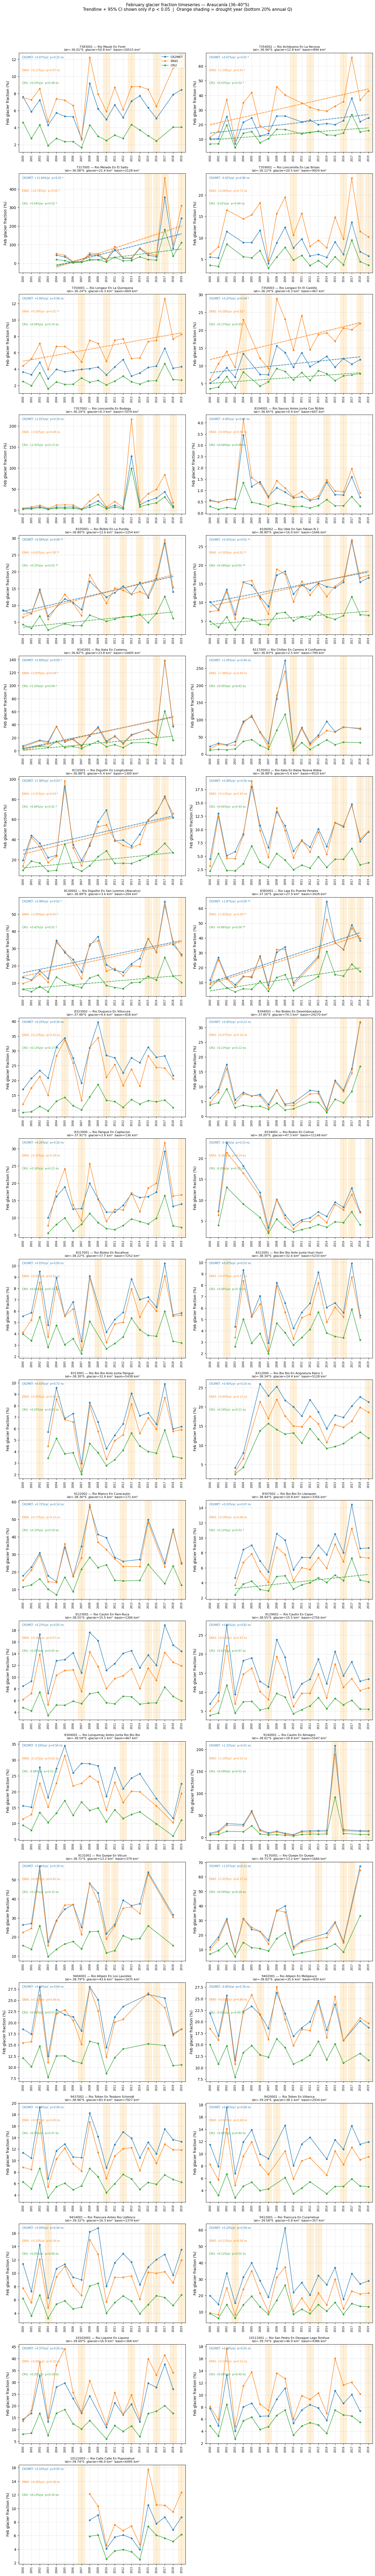

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/feb_timeseries_trends_araucania.png


In [45]:
# Cell 34── February glacier fraction timeseries with trends ─────────────────────

LAT_MIN = -40.0
LAT_MAX = -36.0

study_basins = {
    gid: info for gid, info in GAUGE_INFO_FRAC.items()
    if LAT_MIN <= info['cen_lat'] <= LAT_MAX
}
study_basins = dict(sorted(study_basins.items(),
                            key=lambda x: x[1]['cen_lat'], reverse=True))

n_basins = len(study_basins)
ncols    = 2
nrows    = int(np.ceil(n_basins / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(14, nrows * 4.5),
                          sharex=False)   # sharex=False so each ax sets its own ticks
axes_flat = axes.flatten()

for ax_idx, (gauge_id, info) in enumerate(study_basins.items()):
    ax = axes_flat[ax_idx]

    for ds_name in DATASETS:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m   = res['monthly']
        feb = m[m['month'] == 2].copy().set_index('year')
        feb['frac'] = np.where(
            feb['q_m3_mon'].notna() & (feb['q_m3_mon'] > 0),
            feb['glacier_runoff_m3'] / feb['q_m3_mon'],
            np.nan
        )
        valid = feb['frac'].dropna() * 100

        if len(valid) < 3:
            continue

        # Raw values
        ax.plot(valid.index, valid.values,
                color=DS_COLORS[ds_name], lw=1.5,
                marker='o', ms=4, label=ds_name, alpha=0.8)

        # Trendline — only plot if p < 0.05
        x = valid.index.values.astype(float)
        y = valid.values
        slope, intercept, r, p, se = stats.linregress(x, y)

        if p < 0.05:
            xfit   = np.linspace(x.min(), x.max(), 100)
            yfit   = slope * xfit + intercept
            n      = len(x)
            t95    = stats.t.ppf(0.975, df=n - 2)
            x_mean = x.mean()
            ci     = t95 * se * np.sqrt(
                1/n + (xfit - x_mean)**2 / np.sum((x - x_mean)**2))
            ax.plot(xfit, yfit,
                    color=DS_COLORS[ds_name], lw=1.5, ls='--', alpha=0.9)
            ax.fill_between(xfit, yfit - ci, yfit + ci,
                            color=DS_COLORS[ds_name], alpha=0.1)
            sig_str = '**' if p < 0.01 else '*'
        else:
            sig_str = 'ns'

        # Slope annotation regardless of significance
        ax.text(0.02,
                0.97 - list(DATASETS.keys()).index(ds_name) * 0.13,
                f'{ds_name}: {slope:+.2f}%/yr  p={p:.2f} {sig_str}',
                transform=ax.transAxes, fontsize=7,
                color=DS_COLORS[ds_name], va='top')

    # Drought year shading
    res_cr2 = RESULTS['CR2MET'].get(gauge_id)
    if res_cr2 is not None:
        ann_q    = res_cr2['monthly'].groupby('year')['q_m3_mon'].sum()
        ann_q    = ann_q[ann_q > 0]
        q_thresh = ann_q.quantile(0.20)
        for yr in ann_q[ann_q <= q_thresh].index:
            ax.axvspan(yr - 0.4, yr + 0.4,
                       color='orange', alpha=0.15, zorder=0)

    # X axis — every year labelled, rotated vertically
    ax.set_xticks(range(2000, 2020))
    ax.set_xticklabels(
        [str(y) for y in range(2000, 2020)],
        rotation=90, fontsize=7
    )
    ax.set_xlim(1999.5, 2019.5)

    ax.set_title(f'{gauge_id} — {info["gauge_name"]}\n'
                 f'lat={info["cen_lat"]:.2f}°S  '
                 f'glacier={info["glacier_area_km2"]:.1f} km²  '
                 f'basin={info["basin_area_km2"]:.0f} km²',
                 fontsize=8)
    ax.set_ylabel('Feb glacier fraction (%)')
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=8, loc='upper right')
for ax in axes_flat[n_basins:]:
    ax.set_visible(False)

fig.suptitle('February glacier fraction timeseries — Araucanía (36–40°S)\n'
             'Trendline + 95% CI shown only if p < 0.05  |  '
             'Orange shading = drought year (bottom 20% annual Q)',
             fontsize=11, y=1.01)
plt.tight_layout()
fname = f'{OUT_DIR}/feb_timeseries_trends_araucania.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

## looking at the high frac flag basins: 

In [46]:
# Cell 35 ── High-frac flag diagnostic: MB timeseries vs Q timeseries ─────────────
#
# For each flagged gauge, plots:
#   Panel 1: Annual glacier melt (km3/yr) — all 3 datasets
#   Panel 2: Annual observed streamflow Q (km3/yr) — from CAMELS
#   Panel 3: Resulting glacier fraction (%) — all 3 datasets
# Goal: determine whether implausible fractions are driven by
#   (a) implausibly high melt, (b) implausibly low Q, or (c) both.

flagged_gauges = hf_df['gauge_id'].tolist()
n_flagged      = len(flagged_gauges)

print(f'Plotting {n_flagged} high-frac flagged gauges...')

for gauge_id in flagged_gauges:
    info = GAUGE_INFO_FRAC.get(gauge_id)
    if info is None:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    name = info['gauge_name']

    # ── Panel 1: Annual glacier melt (km3/yr) ─────────────────────────
    ax = axes[0]
    for ds_name in DATASETS:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        ann_melt = res['monthly'].groupby('year')['glacier_runoff_m3'].sum() / 1e9
        ann_melt = ann_melt.reindex(YEARS)
        ax.plot(YEARS, ann_melt.values,
                color=DS_COLORS[ds_name], lw=1.8,
                marker='o', ms=4, label=ds_name)
    ax.set_title('Annual glacier melt (km³/yr)\n← check if this looks too high')
    ax.set_ylabel('km³/yr')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(axis='x', rotation=45)

    # ── Panel 2: Annual observed Q (km3/yr) ───────────────────────────
    ax = axes[1]
    res_cr2 = RESULTS['CR2MET'].get(gauge_id)
    if res_cr2 is not None:
        m      = res_cr2['monthly']
        ann_q  = m.groupby('year')['q_m3_mon'].sum().reindex(YEARS) / 1e9
        n_nan  = m.groupby('year')['q_m3_mon'].apply(
            lambda x: x.isna().sum()).reindex(YEARS)

        # Colour bars by data completeness
        colors_q = ['#2196F3' if n == 0 else
                    '#FF9800' if n <= 3 else '#F44336'
                    for n in n_nan.fillna(12)]
        ax.bar(YEARS, ann_q.fillna(0).values,
               color=colors_q, edgecolor='k', lw=0.3, alpha=0.8)

        # Legend for bar colours
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#2196F3', label='Complete (0 missing months)'),
            Patch(color='#FF9800', label='1-3 missing months'),
            Patch(color='#F44336', label='>3 missing months'),
        ], fontsize=7, loc='upper right')

    ax.set_title('Annual observed Q (km³/yr)\n← check if this looks too low / sparse')
    ax.set_ylabel('km³/yr')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(axis='x', rotation=45)

    # ── Panel 3: Glacier fraction (%) ─────────────────────────────────
    ax = axes[2]
    for ds_name in DATASETS:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m   = res['monthly']
        ann = m.groupby('year').agg(
            glac=('glacier_runoff_m3', 'sum'),
            q   =('q_m3_mon',          'sum')
        ).reindex(YEARS)
        ann['frac'] = np.where(ann['q'] > 0,
                               ann['glac'] / ann['q'] * 100, np.nan)
        ax.plot(YEARS, ann['frac'].values,
                color=DS_COLORS[ds_name], lw=1.8,
                marker='o', ms=4, label=ds_name)

    ax.axhline(100, color='red', lw=1, ls='--',
               label='100% threshold', alpha=0.7)
    ax.set_title('Glacier fraction (%)\n← >100% = implausible or GW storage')
    ax.set_ylabel('%')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(axis='x', rotation=45)

    fig.suptitle(
        f'HIGH-FRAC FLAG: {gauge_id} — {name}\n'
        f'lat={info["cen_lat"]:.2f}°S  cluster={info["clusters"][0]}  '
        f'glacier={info["glacier_area_km2"]:.1f} km²  '
        f'basin={info["basin_area_km2"]:.0f} km²  '
        f'n_complete_Q={info["n_complete_q_years"]} yrs',
        fontsize=9)

    plt.tight_layout()
    fname = f'{OUT_DIR}/highfrac_diagnostic_{gauge_id}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  {gauge_id} {name[:40]} saved')

Plotting 6 high-frac flagged gauges...


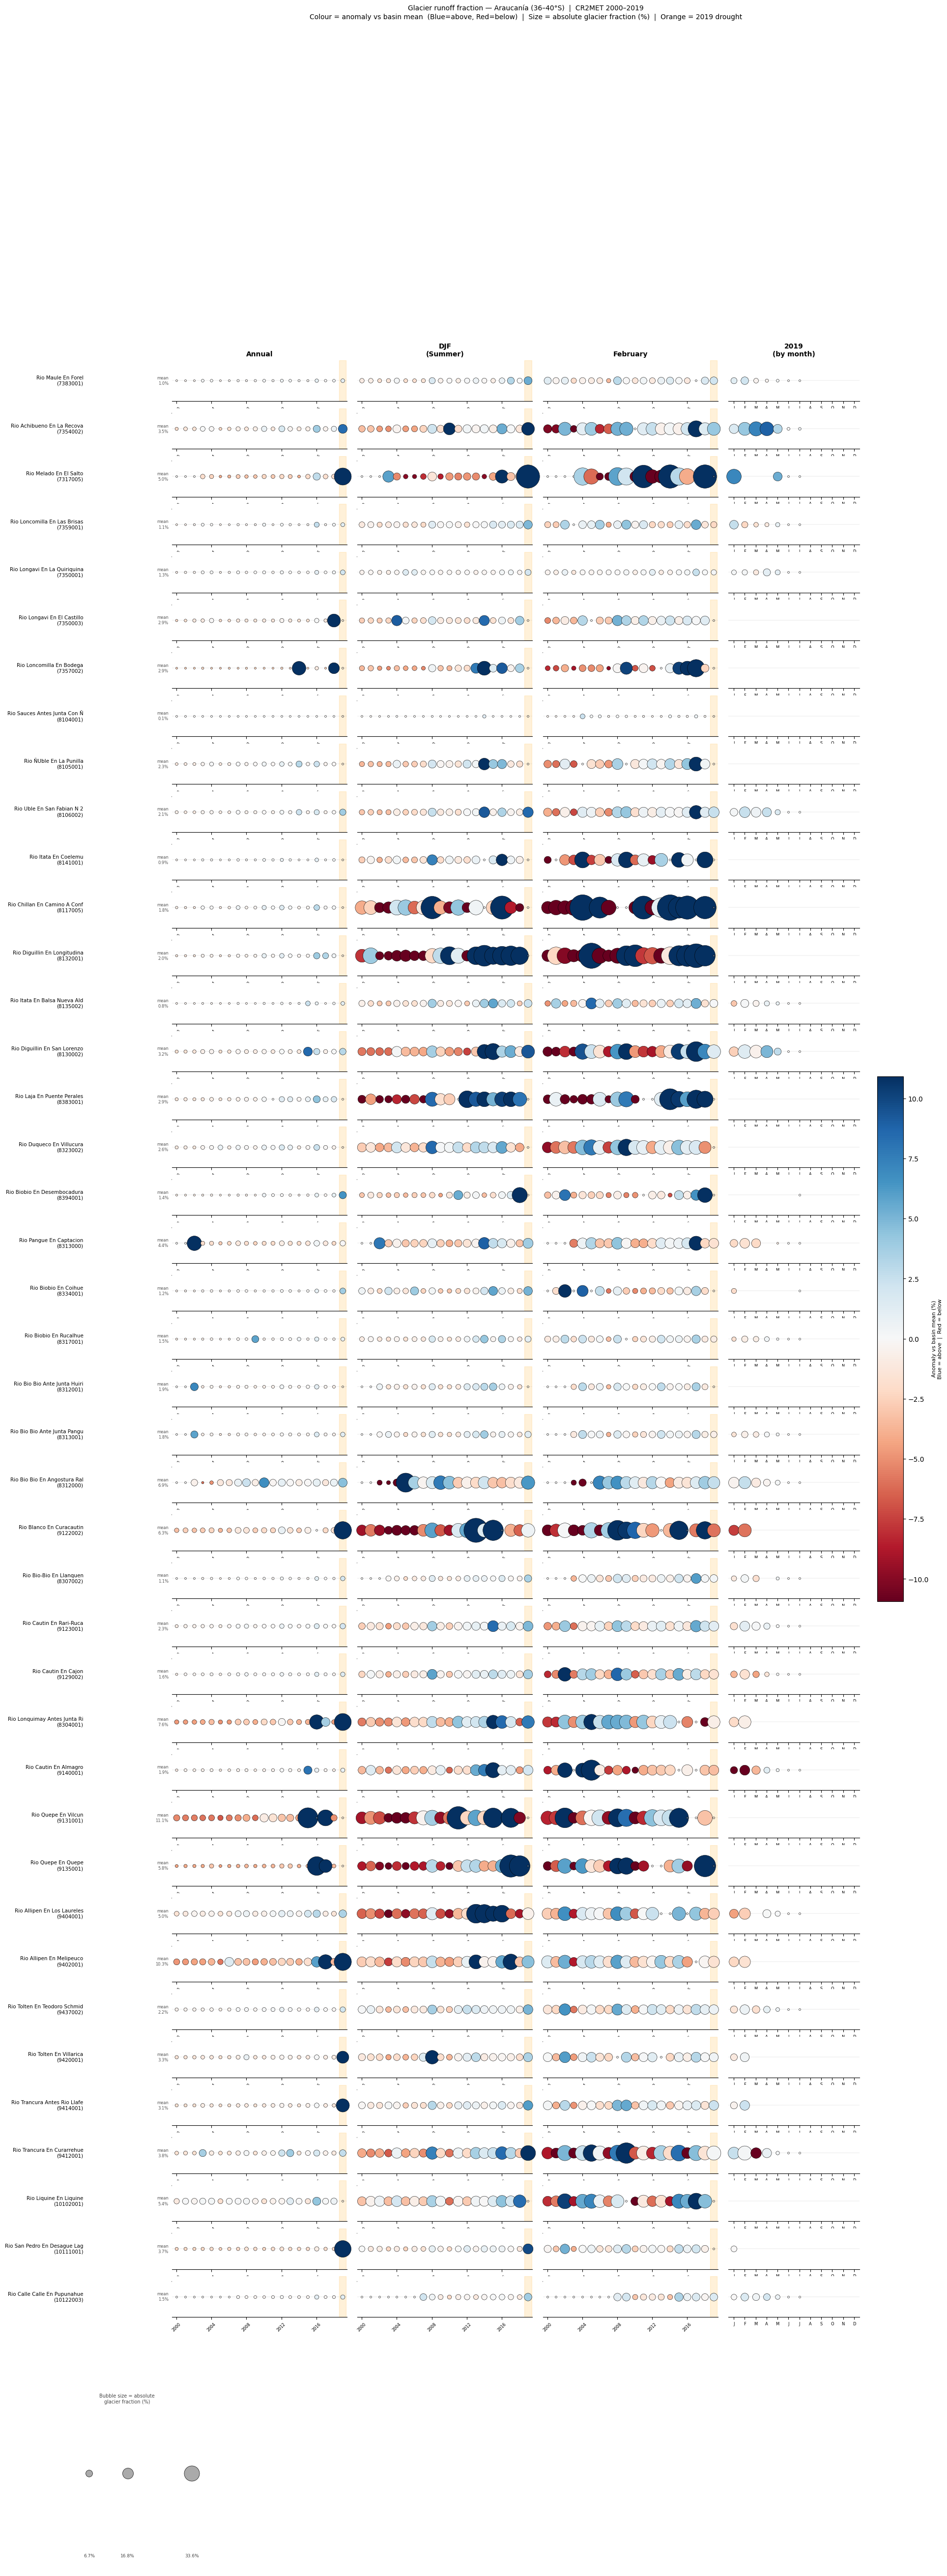

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/bubble_heatmap_anomaly_abssize_araucania_CR2MET.png


In [48]:
# Cell 36 ── Bubble heatmap: glacier fraction anomaly, size = absolute fraction ─────
#
# Rows    = basins (36-40S, north to south)
# Columns = Annual | DJF | February | 2019 (monthly breakdown)
# Colour  = glacier fraction ANOMALY vs that basin's long-term mean
#             Blue  = above mean (elevated glacier contribution)
#             Red   = below mean (suppressed glacier contribution)
# Size    = ABSOLUTE glacier fraction that year/period (%)
#             Big bubble = glacier contributing a lot
#             Small bubble = glacier contributing little
#
# Together: a big blue bubble = high absolute contribution AND above average
#           a small red bubble = low absolute contribution AND below average

LAT_MIN = -40.0
LAT_MAX = -36.0

study_basins = {
    gid: info for gid, info in GAUGE_INFO_FRAC.items()
    if LAT_MIN <= info['cen_lat'] <= LAT_MAX
}
study_basins = dict(sorted(study_basins.items(),
                            key=lambda x: x[1]['cen_lat'], reverse=True))

basin_ids   = list(study_basins.keys())
basin_names = [f"{info['gauge_name'][:28]}\n({gid})"
               for gid, info in study_basins.items()]
n_basins    = len(basin_ids)

PANELS = {
    'Annual':   list(range(1, 13)),
    'DJF':      [12, 1, 2],
    'February': [2],
    '2019':     list(range(1, 13)),
}

DS_REF = 'CR2MET'

# ── Build arrays: absolute fraction and anomaly ───────────────────────────
frac_abs  = {}   # absolute fraction (%) — drives bubble SIZE
frac_anom = {}   # anomaly from basin mean (%) — drives bubble COLOUR

for panel, months in PANELS.items():
    frac_mat = np.full((n_basins, len(YEARS)), np.nan)

    for b_idx, gauge_id in enumerate(basin_ids):
        res = RESULTS[DS_REF].get(gauge_id)
        if res is None:
            continue
        m = res['monthly']
        for y_idx, year in enumerate(YEARS):
            yr_m  = m[(m['year'] == year) & (m['month'].isin(months))]
            glac  = yr_m['glacier_runoff_m3'].sum()
            q_tot = yr_m['q_m3_mon'].sum()
            frac_val = (glac / q_tot * 100 if q_tot > 0 else np.nan)
            frac_mat[b_idx, y_idx] = frac_val if (not np.isnan(frac_val) 
                                       and frac_val <= 100) else np.nan

    frac_abs[panel]  = frac_mat
    # Anomaly = deviation from each basin's own mean across years
    row_mean         = np.nanmean(frac_mat, axis=1, keepdims=True)
    frac_anom[panel] = frac_mat - row_mean

# For 2019 panel, build month-level arrays
def get_2019_monthly(gauge_id):
    """Returns dict: month -> (abs_frac, anom_vs_monthly_mean)"""
    res = RESULTS[DS_REF].get(gauge_id)
    if res is None:
        return {}
    m     = res['monthly']
    mo_means = {}
    for mo in range(1, 13):
        mo_all = m[m['month'] == mo]
        mo_all = mo_all[mo_all['q_m3_mon'].notna() & (mo_all['q_m3_mon'] > 0)]
        if len(mo_all) == 0:
            mo_means[mo] = np.nan
        else:
            mo_means[mo] = (mo_all['glacier_runoff_m3'] /
                            mo_all['q_m3_mon']).mean() * 100

    m2019  = m[m['year'] == 2019].copy()
    result = {}
    for _, row in m2019.iterrows():
        mo    = int(row['month'])
        q_val = row['q_m3_mon']
        glac  = row['glacier_runoff_m3']
        if pd.isna(q_val) or q_val <= 0:
            continue
        abs_frac = glac / q_val * 100
        if abs_frac > 100:
            continue   # skip implausible months
        anom = abs_frac - mo_means.get(mo, abs_frac)
        result[mo] = (abs_frac, anom)
    return result

# Colour scale: symmetric around 0, based on anomaly
all_anom = np.concatenate([frac_anom[p].flatten()
                            for p in ['Annual','DJF','February']])
vmax     = np.nanpercentile(np.abs(all_anom), 92)
cmap     = plt.cm.RdBu   # Red=below mean, Blue=above mean

# Size scale: based on absolute fraction
all_abs  = np.concatenate([frac_abs[p].flatten()
                            for p in ['Annual','DJF','February']])
frac_max = np.nanpercentile(all_abs, 95)
MAX_SIZE = 500
MIN_SIZE = 8

def frac_to_size(frac_val):
    if np.isnan(frac_val) or frac_val <= 0:
        return MIN_SIZE
    return max(MIN_SIZE, (frac_val / (frac_max + 1e-9)) * MAX_SIZE)

def anom_to_color(anom_val):
    if np.isnan(anom_val):
        return (0.85, 0.85, 0.85, 0.3)   # transparent grey for missing
    norm = (anom_val / (2 * vmax)) + 0.5
    norm = np.clip(norm, 0, 1)
    return cmap(norm)

# ── Plot ──────────────────────────────────────────────────────────────────
n_panels = len(PANELS)
fig, axes = plt.subplots(n_basins, n_panels,
                          figsize=(n_panels * 4.8, n_basins * 1.2 + 2.5),
                          gridspec_kw={'wspace': 0.06, 'hspace': 0.18})

panel_titles = {
    'Annual':   'Annual',
    'DJF':      'DJF\n(Summer)',
    'February': 'February',
    '2019':     '2019\n(by month)',
}

for b_idx in range(n_basins):
    for p_idx, panel in enumerate(PANELS):
        ax = axes[b_idx, p_idx]

        if panel == '2019':
            mo_data = get_2019_monthly(basin_ids[b_idx])
            for mo, (abs_frac, anom) in mo_data.items():
                ax.scatter(mo, 0,
                           s=frac_to_size(abs_frac),
                           color=anom_to_color(anom),
                           edgecolors='k', lw=0.4,
                           zorder=3, clip_on=False)
            ax.set_xlim(0.5, 12.5)
            ax.set_xticks(range(1, 13))
            ax.set_xticklabels(['J','F','M','A','M','J',
                                 'J','A','S','O','N','D'],
                               fontsize=6)
        else:
            fracs_abs  = frac_abs[panel][b_idx, :]
            fracs_anom = frac_anom[panel][b_idx, :]

            for y_idx, year in enumerate(YEARS):
                ax.scatter(year, 0,
                           s=frac_to_size(fracs_abs[y_idx]),
                           color=anom_to_color(fracs_anom[y_idx]),
                           edgecolors='k', lw=0.4,
                           zorder=3, clip_on=False)

            ax.set_xlim(1999.5, 2019.5)
            ax.set_xticks(range(2000, 2020, 4))
            ax.tick_params(axis='x', labelsize=6, rotation=45)
            ax.axvspan(2018.6, 2019.4,
                       color='orange', alpha=0.15, zorder=0)

            # Basin mean annotation on leftmost panel
            if p_idx == 0:
                mean_frac = np.nanmean(fracs_abs)
                if not np.isnan(mean_frac):
                    ax.text(-0.02, 0.5,
                            f'mean\n{mean_frac:.1f}%',
                            transform=ax.transAxes,
                            ha='right', va='center',
                            fontsize=6, color='#555555',
                            linespacing=1.3)

        ax.set_yticks([])
        ax.set_ylim(-0.6, 0.6)
        ax.axhline(0, color='grey', lw=0.3, alpha=0.4)
        ax.spines[['top','right','left']].set_visible(False)

        if p_idx == 0:
            ax.set_ylabel(basin_names[b_idx], fontsize=7.5,
                          rotation=0, ha='right', va='center',
                          labelpad=130)
        if b_idx == 0:
            ax.set_title(panel_titles[panel],
                         fontsize=10, fontweight='bold')

# ── Colourbar ─────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, -1], shrink=0.55, pad=0.1)
cbar.set_label('Anomaly vs basin mean (%)\nBlue = above  |  Red = below',
               fontsize=8)

# ── Size legend ───────────────────────────────────────────────────────────
leg_ax = fig.add_axes([0.01, 0.01, 0.16, 0.07])
leg_ax.set_axis_off()
for pct, label in [(0.2, f'{frac_max*0.2:.1f}%'),
                    (0.5, f'{frac_max*0.5:.1f}%'),
                    (1.0, f'{frac_max:.1f}%')]:
    leg_ax.scatter(pct * 0.85, 0.55,
                   s=frac_to_size(pct * frac_max),
                   color='#aaaaaa', edgecolors='k', lw=0.5)
    leg_ax.text(pct * 0.85, 0.08, label,
                ha='center', fontsize=6.5, color='#444444')
leg_ax.text(0.42, 1.0, 'Bubble size = absolute\nglacier fraction (%)',
            ha='center', va='top', fontsize=7, color='#444444',
            linespacing=1.3)
leg_ax.set_xlim(0, 1)
leg_ax.set_ylim(0, 1)

fig.suptitle(
    f'Glacier runoff fraction — Araucanía (36–40°S)  |  {DS_REF} 2000–2019\n'
    f'Colour = anomaly vs basin mean  (Blue=above, Red=below)  |  '
    f'Size = absolute glacier fraction (%)  |  Orange = 2019 drought',
    fontsize=10, y=1.02)

fname = f'{OUT_DIR}/bubble_heatmap_anomaly_abssize_araucania_{DS_REF}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

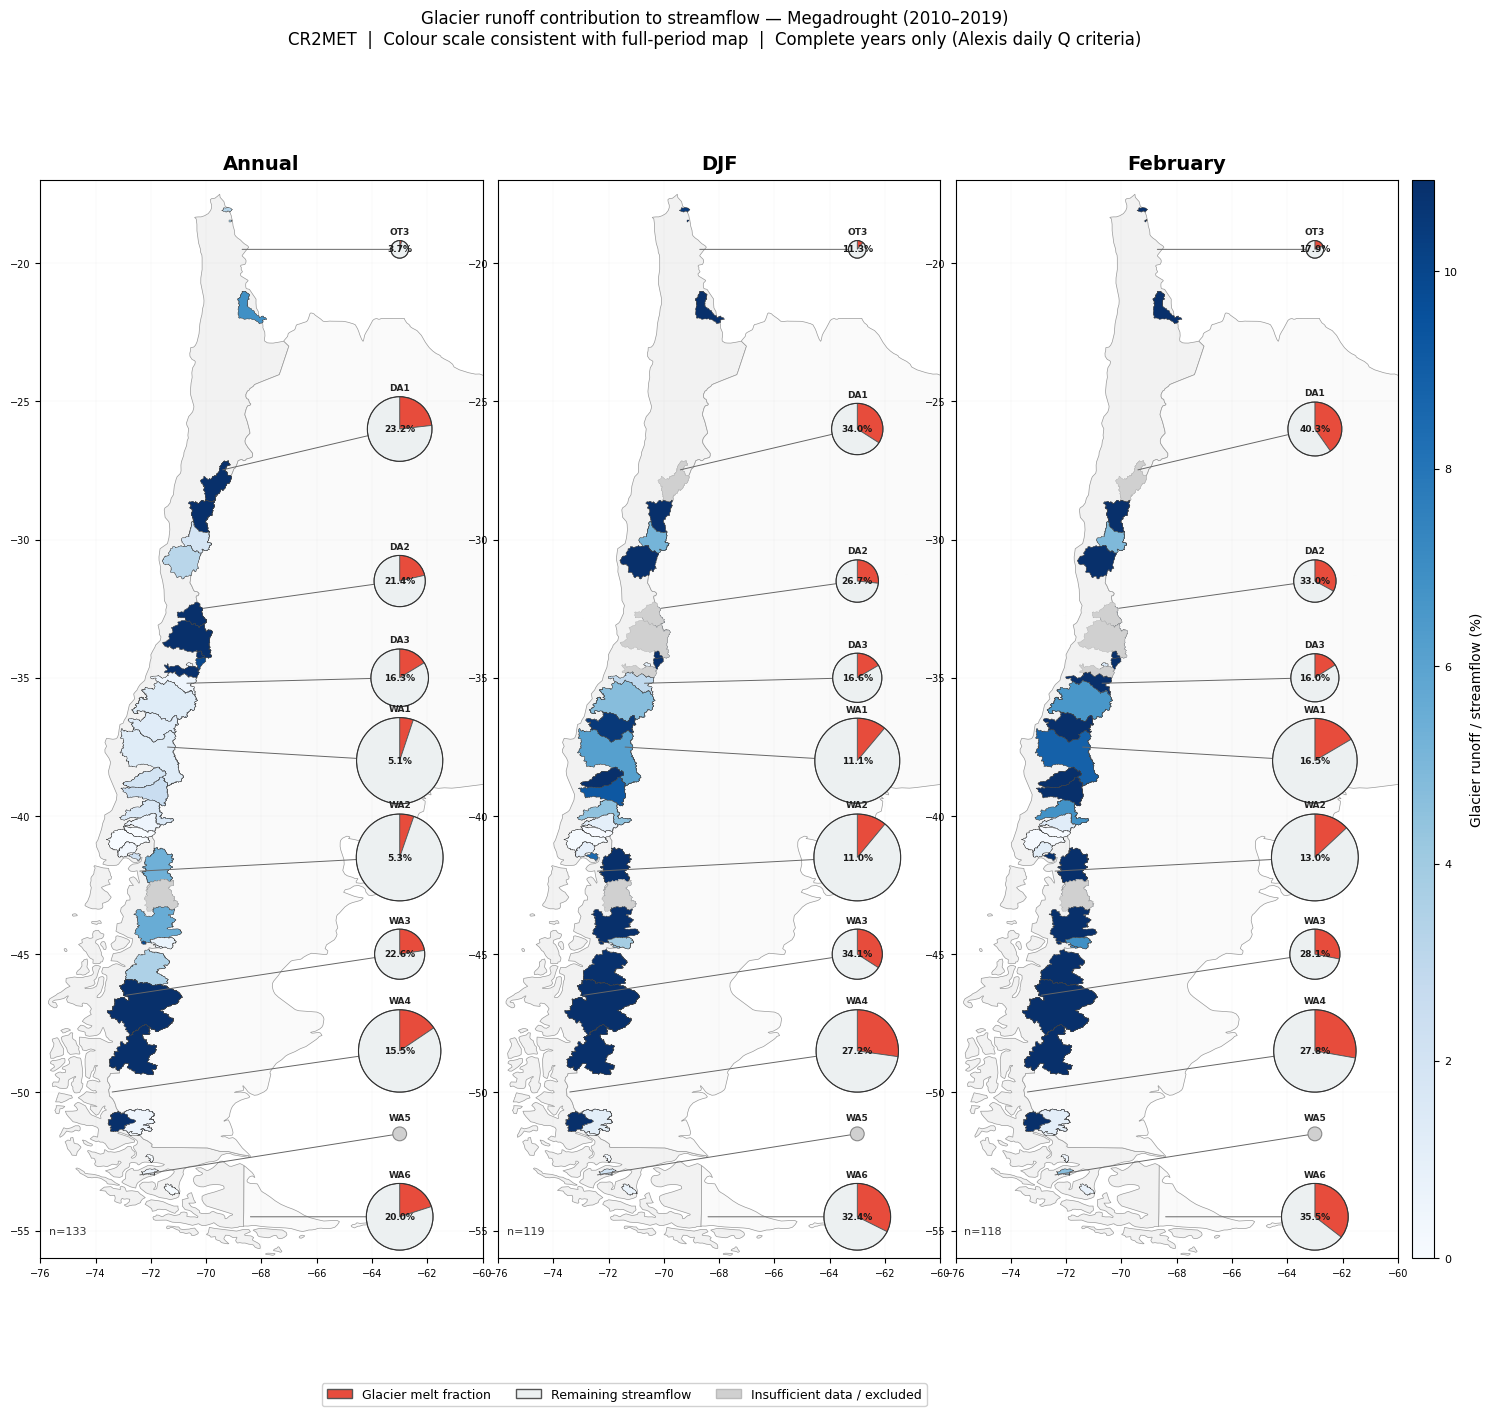

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/map_glacier_fraction_megadrought_CR2MET.png


In [50]:
# ── Cell 37: Figure — Megadrought panels standalone ───────────────────────
#
# Reuses from Cell 24: vmax, cmap_map, norm, GREY, GREY_EDGE, BLUE_EDGE,
# has_borders, chile, arg, bounds_valid, frac_maps, SEASON_DEFS,
# season_labels, regional_frac, area_to_radius, REGION_ANCHORS, PULLOUT_POS

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05],
                        wspace=0.04, hspace=0.04)

for c_idx, season_label in enumerate(season_labels):
    ax  = fig.add_subplot(gs[0, c_idx])
    col = f'Megadrought (2010-2019)|{season_label}'

    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2',
                   edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa',
                 edgecolor='#999999', linewidth=0.5, zorder=0)

    frac_vals   = bounds_valid[col].values
    face_colors = [to_hex(cmap_map(norm(v))) if not np.isnan(v) else GREY
                   for v in frac_vals]
    edge_colors = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE
                   for v in frac_vals]
    bounds_valid.plot(ax=ax, color=face_colors, edgecolor=edge_colors,
                      linewidth=0.25, zorder=2)

    months = SEASON_DEFS[season_label]
    for cl in CLUSTERS:
        mean_frac, tot_basin_area, _ = regional_frac(
            cl, MEGADROUGHT_YEARS, months)
        anchor  = REGION_ANCHORS[cl]
        pullout = PULLOUT_POS[cl]
        radius  = area_to_radius(tot_basin_area)

        if np.isnan(mean_frac) or mean_frac == 0:
            ax.add_patch(plt.Circle(pullout, radius,
                facecolor=GREY, edgecolor='#888888',
                linewidth=0.8, zorder=6, transform=ax.transData))
        else:
            frac_clipped = min(mean_frac / 100, 1.0)
            theta1 = 90
            for size, fc in [(frac_clipped, '#e74c3c'),
                              (1 - frac_clipped, '#ecf0f1')]:
                theta2 = theta1 - size * 360
                ax.add_patch(Wedge(pullout, radius,
                    min(theta1, theta2), max(theta1, theta2),
                    facecolor=fc, edgecolor='#555555',
                    linewidth=0.6, zorder=6, transform=ax.transData))
                theta1 = theta2
            ax.add_patch(plt.Circle(pullout, radius,
                facecolor='none', edgecolor='#333333',
                linewidth=0.8, zorder=7, transform=ax.transData))
            ax.text(pullout[0], pullout[1], f'{mean_frac:.1f}%',
                    ha='center', va='center', fontsize=6.5,
                    fontweight='bold', color='#1a1a1a', zorder=8)

        ax.text(pullout[0], pullout[1] + radius + 0.15, cl,
                ha='center', va='bottom', fontsize=6.5,
                fontweight='bold', color='#222222', zorder=8)
        ax.annotate('', xy=anchor,
                    xytext=(pullout[0] - radius * 0.1, pullout[1]),
                    arrowprops=dict(arrowstyle='-', color='#666666',
                                    lw=0.7, connectionstyle='arc3,rad=0.0'),
                    zorder=5)

    ax.set_xlim(-76, -60)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15, lw=0.3)
    ax.set_title(season_label, fontsize=14, fontweight='bold', pad=8)
    ax.text(0.02, 0.02, f'n={int(np.sum(~np.isnan(frac_vals)))}',
            transform=ax.transAxes, fontsize=8, color='#333333', va='bottom')

cbar_ax = fig.add_subplot(gs[0, 3])
sm = ScalarMappable(cmap=cmap_map, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Glacier runoff / streamflow (%)', fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', edgecolor='#555555',
              label='Glacier melt fraction'),
        Patch(facecolor='#ecf0f1', edgecolor='#555555',
              label='Remaining streamflow'),
        Patch(facecolor=GREY, edgecolor=GREY_EDGE,
              label='Insufficient data / excluded'),
    ],
    loc='lower center', ncol=3, fontsize=9,
    bbox_to_anchor=(0.45, 0.0), framealpha=0.9
)

fig.suptitle(
    f'Glacier runoff contribution to streamflow — Megadrought (2010–2019)\n'
    f'{DS_MAP}  |  Colour scale consistent with full-period map  |  '
    f'Complete years only (Alexis daily Q criteria)',
    fontsize=12, y=1.002
)

fname = f'{OUT_DIR}/map_glacier_fraction_megadrought_{DS_MAP}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

In [51]:
# Quick answer to Noah's question
small_glacierized = [
    (gid, info['glacier_area_km2'], info['basin_area_km2'], info['cen_lat'])
    for gid, info in GAUGE_INFO_FRAC.items()
    if info['glacier_area_km2'] <= 100
]
small_glacierized.sort(key=lambda x: x[3])  # sort by latitude
print(f'Gauged basins with ≤100 km² glacier area: {len(small_glacierized)}')
for gid, ga, ba, lat in small_glacierized:
    print(f'  {gid}  glacier={ga:.1f} km²  basin={ba:.0f} km²  lat={lat:.2f}°S')

Gauged basins with ≤100 km² glacier area: 116
  12582001  glacier=0.6 km²  basin=864 km²  lat=-53.58°S
  12448001  glacier=2.6 km²  basin=604 km²  lat=-52.95°S
  12452001  glacier=0.2 km²  basin=308 km²  lat=-52.32°S
  12291001  glacier=0.1 km²  basin=220 km²  lat=-51.47°S
  12289002  glacier=7.0 km²  basin=5285 km²  lat=-51.14°S
  12280002  glacier=32.0 km²  basin=582 km²  lat=-50.86°S
  12284003  glacier=0.6 km²  basin=1730 km²  lat=-50.74°S
  12284007  glacier=1.9 km²  basin=3937 km²  lat=-50.73°S
  12284006  glacier=1.3 km²  basin=901 km²  lat=-50.71°S
  11536001  glacier=32.1 km²  basin=5085 km²  lat=-47.44°S
  11317001  glacier=2.2 km²  basin=3324 km²  lat=-45.83°S
  11302001  glacier=1.7 km²  basin=1997 km²  lat=-45.01°S
  11141001  glacier=0.0 km²  basin=1106 km²  lat=-44.73°S
  11143002  glacier=0.3 km²  basin=134 km²  lat=-44.73°S
  11147002  glacier=17.7 km²  basin=128 km²  lat=-44.57°S
  11143001  glacier=2.8 km²  basin=2258 km²  lat=-44.50°S
  10702002  glacier=90.7 km²  b

In [54]:
# Read the first few rows of any attribute CSVs you find above
# and print the column names
import pandas as pd
for f in attr_files[:5]:
    df = pd.read_csv(f, nrows=2)
    print(f'\n{f}:')
    print(df.columns.tolist())


/Users/milliespencer/Desktop/CR2_OGGM_Paper/Full_CAMELS_all_basins/CAMELS_CL_v202201/precip_chirps_mm_mon.csv:
['date', 'year', 'month', 'day', '1001001', '1001002', '1001003', '1020002', '1020003', '1021001', '1021002', '1041002', '1044001', '1050002', '1050004', '1201001', '1201003', '1201005', '1210001', '1211001', '1300009', '1310002', '1410004', '1502002', '1502008', '1610002', '1610004', '1730001', '1730002', '1730003', '1730007', '1730012', '2101001', '2103001', '2103002', '2103003', '2103014', '2104002', '2104003', '2104013', '2105001', '2105002', '2105005', '2105007', '2110001', '2110002', '2110004', '2110031', '2112005', '2112006', '2112007', '2113001', '2120001', '2510001', '3022001', '3041001', '3041002', '3041003', '3041004', '3041005', '3050001', '3404001', '3414001', '3421001', '3430001', '3430002', '3430003', '3431001', '3434001', '3434003', '3450001', '3453001', '3802001', '3804002', '3806001', '3814001', '3814003', '3815001', '3815002', '3820001', '3820002', '3820003